# Setup

In [355]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import os
from nds_toolbox.preprocessing.features import compute_wavelet

import seaborn as sns




In [368]:

FIG_WIDTH = 7.5
MY_FONT_SIZE = 9


plt.rcParams.update({
    # --- Fonts ---
    "font.family": "Arial",
    "font.size": MY_FONT_SIZE,

    # --- Legend ---
    "legend.fontsize": MY_FONT_SIZE,
    "legend.frameon": False,

    # --- Titles ---
    "figure.titlesize": MY_FONT_SIZE,
    "axes.titleweight": "normal",
    "axes.titlesize": MY_FONT_SIZE,

    # --- Axes ---
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.spines.left": True,
    "axes.spines.bottom": True,
    "axes.edgecolor": "black",
    "axes.linewidth": 0.8,
    "axes.unicode_minus": True,
    "axes.labelsize": MY_FONT_SIZE,

    # --- Lines & markers ---
    "lines.linewidth": 1.0,
    "lines.markersize": 0.7,

    # --- Ticks ---
    "xtick.labelsize": MY_FONT_SIZE,
    "ytick.labelsize": MY_FONT_SIZE,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "xtick.bottom": True,
    "ytick.left": True,
    "xtick.minor.size": 2,
    "ytick.minor.size": 2,
    "axes.linewidth": 0.7,
    "xtick.minor.visible": False,
    "ytick.minor.visible": False,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,

    # Grid
    "axes.grid": False,
    "grid.linestyle": ":",
    "grid.linewidth": 0.5,
    "grid.alpha": 0.5,


    # --- Layout ---
    "figure.autolayout": True,

    # --- DPI ---
    "savefig.dpi": 900,
    "figure.dpi": 300,
})


# 2-state scenario

In [369]:
sim_cond_data = "2states"

signal_dir = "../data/simulations"
sim_data = np.load(f'{signal_dir}/{sim_cond_data}_data.npz', allow_pickle=True)

#load the simulated data
signal_sample = sim_data['signal_sample']
states_sample = sim_data['states_sample']

print("shape of signal_sample", signal_sample.shape)


sim_cond = "2states_est_k"

performance_dir = "../data/performance"
file_path = f"{performance_dir}/results_{sim_cond}.pkl"

import pickle
with open(file_path, "rb") as f:
    res = pickle.load(f)

df_list = [pd.DataFrame(r) for r in res]
df = pd.concat(df_list, axis = 0, ignore_index = True)
df.head()


shape of signal_sample (5, 5, 3)


,method,signal,true_states,burst_f,fs,snr,est_params,loss_best,model_id_best,seed_best,...,fit_t,pred_t,total_time,num_states,num_emb,est_states,order,summary_stats,mcc,loss
0,DP-GMM,"[-1.0609110797619747, -0.9366573169036332, -1....","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",10,100,2,"{'alpha': 0.35537815, 'weights': [0.62469006, ...",1.0385197,3,1294949329,...,118.933357,0.450104,119.383461,10,3,"[0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, ...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]",None,0.349707,1.0385197
1,DP-GMM,"[-1.0609110797619747, -0.9366573169036332, -1....","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",10,100,2,"{'alpha': 0.4993945, 'weights': [0.5741494, 0....",0.92085606,6,3662778295,...,140.280332,0.568981,140.849313,10,7,"[0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, ...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]",None,0.619750,0.92085606
2,DP-GMM,"[-1.0609110797619747, -0.9366573169036332, -1....","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",10,100,2,"{'alpha': 0.27184483, 'weights': [0.6430739, 0...",0.87040967,1,106509115,...,164.884580,0.583061,165.467640,10,11,"[1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]",None,0.746787,0.87040967
3,DP-GMM,"[-1.0609110797619747, -0.9366573169036332, -1....","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",10,100,2,"{'alpha': 0.42912585, 'weights': [0.6732623, 0...",0.84548855,5,3812921341,...,193.880988,0.551081,194.432069,10,15,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, ...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]",None,0.816637,0.84548855
4,DP-GMM,"[-1.0609110797619747, -0.9366573169036332, -1....","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",10,100,2,"{'alpha': 0.44448787, 'weights': [0.6890724, 0...",0.83199745,3,3246269779,...,223.677549,0.532162,224.209711,10,19,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]",None,0.854889,0.83199745


In [374]:
from tqdm.auto import tqdm
import numpy as np

import os

import jax
from jax import random
import jax.numpy as jnp
from jax.scipy.special import logsumexp
import numpyro
import numpyro.distributions as dist

import jax.scipy.stats as jss
from numpyro.infer.initialization import init_to_median


# see https://github.com/luiarthur/TuringBnpBenchmarks/blob/master/src/dp-gmm/notebooks//dp_sb_gmm_pyro.ipynb

@jax.jit
def stick_breaking(v):
    batch_ndims = len(v.shape) - 1
    cumprod_one_minus_v = jnp.exp(jnp.log1p(-v).cumsum(-1))
    one_v = jnp.pad(v, [[0, 0]] * batch_ndims + [[0, 1]], constant_values=1)
    c_one = jnp.pad(cumprod_one_minus_v, [[0, 0]] * batch_ndims + [[1, 0]],
                    constant_values=1)
    return one_v * c_one


def dpgmm_model(data, *, num_states, batch_size=None, alpha_prior=1.0, learn_alpha=True, learn_mean=True):
    num_data, num_dim = data.shape

    if learn_alpha:
        # hyper prior
        alpha = numpyro.sample("alpha", dist.HalfCauchy(1))

    else:
        alpha = numpyro.deterministic("alpha", jnp.array(alpha_prior))

    # stick-breaking
    with numpyro.plate("v_plates", num_states - 1):
        v = numpyro.sample("v", dist.Beta(1.0, alpha))

    eps = 1e-12
    weights = stick_breaking(v)
    weights = jnp.clip(weights, eps, 1.0) #avoiding underflow
    weights = weights / jnp.sum(weights)

    numpyro.deterministic("weights", weights)

    # --------  component‑specific parameters  ----------------------------
    if learn_mean:
        # sample a separate mean for every component
        with numpyro.plate("components", num_states):
            mean = numpyro.sample(
                "mean",
                dist.MultivariateNormal(jnp.zeros(num_dim),
                                        jnp.eye(num_dim))
            )
            sigma = numpyro.sample("sigma",
                                   dist.HalfCauchy(jnp.ones(num_dim)).to_event(
                                       1))  # maybe gamma is better? (gamma(1, 10))

            chol_corr = numpyro.sample("chol_corr",
                                       dist.LKJCholesky(num_dim, concentration=1.0))

            L_cov = chol_corr * sigma[..., None]

    else:
        # fixed zero mean for each component
        mean = numpyro.deterministic("mean", jnp.zeros((num_states, num_dim)))
        with numpyro.plate("components", num_states):
            sigma = numpyro.sample("sigma",
                                   dist.HalfCauchy(jnp.ones(num_dim)).to_event(1))

            chol_corr = numpyro.sample("chol_corr",
                                       dist.LKJCholesky(num_dim, concentration=1.0))
            L_cov = numpyro.deterministic("L_cov", chol_corr * sigma[..., None])

    if batch_size is None:
        batch_size = num_data  # use all the data point all the times

    # mixture assignment + likelihood
    with numpyro.plate("data", num_data, subsample_size=batch_size) as ind:
        batch_data = data[ind]
        mixture_dist = dist.MixtureSameFamily(dist.Categorical(logits=jnp.log(weights)),
                                              dist.MultivariateNormal(mean, scale_tril=L_cov))
        numpyro.sample("obs", mixture_dist, obs=batch_data)


from numpyro.infer import SVI, TraceEnum_ELBO, Trace_ELBO, init_to_value
from numpyro.infer.autoguide import AutoDelta, AutoDiagonalNormal, AutoNormal
from jax import jit


from joblib import Parallel, delayed

def _fit_DPGMM(x,
               num_states,
               *,
               rng_key=None,
               seed=0,
               learn_mean=False,
               learn_alpha=True,
               num_epochs=3000,
               num_particles=5,
               batch_size=2 ** 9,
               alpha_prior=1.0,
               learning_rate=1e-2,
               use_epoch_tqdm=False
               ):
    x = jnp.array(x)
    guide = AutoNormal(dpgmm_model, init_loc_fn=init_to_median)

    # For numerical stability, normalize the scale by the total number of data points.
    scale_factor = 1.0 / float(x.size)
    scaled_model = numpyro.handlers.scale(dpgmm_model, scale=scale_factor)
    scaled_guide = numpyro.handlers.scale(guide, scale=scale_factor)

    optimizer = numpyro.optim.Adam(step_size=learning_rate)

    elbo = Trace_ELBO(num_particles=num_particles, vectorize_particles=True)

    svi = SVI(scaled_model, scaled_guide, optimizer, loss=elbo)

    if rng_key is None:
        rng_key = random.PRNGKey(int(seed))

    svi_result = svi.run(rng_key, num_epochs, x, num_states=num_states, batch_size=batch_size, alpha_prior=alpha_prior,
                         learn_mean=learn_mean, learn_alpha=learn_alpha, progress_bar=use_epoch_tqdm)

    est_params = guide.median(svi_result.params)


    #compute ELBO estimate with 100 monte carlo samples
    elbo_eval = Trace_ELBO(num_particles = 100, vectorize_particles = True)


    final_loss = elbo_eval.loss(
        rng_key,
        svi_result.params,
        scaled_model,
        scaled_guide,
        x,
        num_states=num_states,
        batch_size=batch_size,
        alpha_prior=alpha_prior,
        learn_mean=learn_mean,
        learn_alpha=learn_alpha,)

    return est_params, np.array(svi_result.losses), final_loss

from tqdm_joblib import tqdm_joblib
def fit_DPGMM(
        *,
        data,
        num_states,
        learn_mean=False,
        learn_alpha=True,
        num_models=8,
        num_epochs=3000,
        num_particles= 10,
        batch_size=2**10,
        use_epoch_tqdm=False,
        use_model_tqdm=True,
        alpha_prior=1.0,
        learning_rate=5e-2,
        verbose=False,
        n_jobs=1,  # how many processes (-1 for all cores)
        main_seed=0,  # master seed for all runs
):
    x = jnp.array(data)

    # --- generate one integer seed per model run ---
    # Use numpy's SeedSequence for independent child seeds (robust & portable)
    ss = np.random.SeedSequence(int(main_seed))
    child_seeds = [s.generate_state(1, dtype=np.uint32)[0] for s in ss.spawn(num_models)]

    iterator = range(num_models)
    if use_model_tqdm and n_jobs == 1:
        iterator = tqdm(iterator, desc=f"Fitting {num_models} DPGMM models", unit="model", leave=False)

    loss_best = np.inf
    est_params_best = None
    best_model_id = None
    best_seed = None
    loss_all = []

    if n_jobs == 1:
        for i in iterator:
            params_i, losses_i, final_loss_i = _fit_DPGMM(
                x,
                num_states,
                rng_key=None,
                seed=int(child_seeds[i]),
                learn_mean=learn_mean,
                learn_alpha=learn_alpha,
                num_epochs=num_epochs,
                num_particles=num_particles,
                batch_size=batch_size,
                alpha_prior=alpha_prior,
                learning_rate=learning_rate,
                use_epoch_tqdm=use_epoch_tqdm,
            )
            loss_all.append(losses_i)
            run_best = final_loss_i

            if run_best < loss_best:
                loss_best = run_best
                est_params_best = params_i
                best_model_id = i
                best_seed = child_seeds[i]

    else:
        # ---- parallel with joblib ----
        indices = list(range(num_models))

        if use_model_tqdm:
            with tqdm_joblib(total=len(indices), desc=f"Fitting {num_models} DPGMM models"):
                results = Parallel(n_jobs=n_jobs)(
                    delayed(_fit_DPGMM)(
                        x,
                        num_states,
                        learn_mean=learn_mean,
                        learn_alpha=learn_alpha,
                        num_epochs=num_epochs,
                        num_particles=num_particles,
                        batch_size=batch_size,
                        alpha_prior=alpha_prior,
                        learning_rate=learning_rate,
                        use_epoch_tqdm=use_epoch_tqdm,
                        seed=int(child_seeds[i]),
                    )
                    for i in indices
                )

        else:
            if verbose:
                print("------running dpgmm-----")
            results = Parallel(n_jobs=n_jobs, return_as="generator")(
                delayed(_fit_DPGMM)(
                    x,
                    num_states,
                    learn_mean=learn_mean,
                    learn_alpha=learn_alpha,
                    num_epochs=num_epochs,
                    num_particles=num_particles,
                    batch_size=batch_size,
                    alpha_prior=alpha_prior,
                    learning_rate=learning_rate,
                    use_epoch_tqdm=use_epoch_tqdm,
                    seed=int(child_seeds[i]),
                )
                for i in indices
            )

        # collect in order
        results = list(results)
        for i, (params_i, losses_i, final_loss_i) in zip(indices, results):
            loss_all.append(losses_i)
            run_best = final_loss_i

            if run_best < loss_best:
                loss_best = run_best
                est_params_best = params_i
                best_model_id = i
                best_seed = child_seeds[i]

    if verbose:
        print(f"Best ELBO: {loss_best:.6g}")
        if best_model_id is not None:
            print(f"Best model ID: {best_model_id}")

    params = extract_params(est_params_best, learn_mean=learn_mean, learn_alpha=learn_alpha)
    alpha, weights, means, covs = params["alpha"], params["weights"], params["means"], params["covs"]

    if alpha is None:
        alpha = float(alpha_prior)
    if means is None:
        means = np.zeros((num_states, x.shape[1]))

    return {
        "est_params": {
            "alpha": alpha,
            "weights": weights,
            "means": means,
            "covs": covs,
        },
        "loss_best": loss_best,
        "model_id_best": best_model_id,
        "seed_best": int(best_seed) if best_seed is not None else None,
        "loss_all": loss_all,
    }


def extract_params(est_params, learn_mean=True, learn_alpha=True):
    # alpha
    alpha = None
    if learn_alpha:
        alpha = est_params["alpha"]

    # stick-breaking weights
    v = est_params["v"]
    weights = stick_breaking(v)

    # covariances
    chol_corr = est_params["chol_corr"]
    sigma = est_params["sigma"]
    L_covs = [jnp.diag(sig) @ L for sig, L in zip(sigma, chol_corr)]
    covs = jnp.array([L @ L.T for L in L_covs])

    means = None
    if learn_mean:
        means = est_params["mean"]

    return {
        "alpha": alpha,
        "weights": weights,
        "means": means,
        "covs": covs,
    }


import jax.numpy as jnp

import jax.numpy as jnp

def truncate(means, covs, weights, mass_threshold=0.99,
             remove_edge_states=True, edge_states_cv=0.2,
             verbose=False, return_info=False):

    weights = jnp.asarray(weights)
    K = weights.shape[0]

    # Normalize defensively
    w = weights / jnp.sum(weights)

    # ----------------------------
    # (1) 99% mass truncation first
    # ----------------------------
    sort_idx = jnp.argsort(w)[::-1]
    w_sorted = w[sort_idx]
    cdf = jnp.cumsum(w_sorted)

    reached = cdf >= mass_threshold
    k0 = jnp.where(jnp.any(reached), jnp.argmax(reached) + 1, K)

    active_sorted_idx = sort_idx[:k0]
    active_idx = jnp.sort(active_sorted_idx)  # indices into original arrays

    # ----------------------------
    # (2) Remove edge states (within active set)
    # ----------------------------
    final_idx = active_idx
    removed_edge = jnp.array([], dtype=jnp.int32)

    if remove_edge_states:
        trunc_covs0 = covs[active_idx]
        diag = jnp.diagonal(trunc_covs0, axis1=-2, axis2=-1)  # (k0, D)
        mu = jnp.mean(diag, axis=-1)
        sd = jnp.std(diag, axis=-1)
        cv_diags = sd / (mu + 1e-12)

        keep_mask = cv_diags <= edge_states_cv
        removed_edge = jnp.where(~keep_mask)[0]

        if removed_edge.size > 0:
            # fail-safe: don't drop everything
            if not bool(jnp.any(keep_mask)):
                keep_mask = jnp.zeros_like(keep_mask, dtype=bool).at[jnp.argmin(cv_diags)].set(True)
                removed_edge = jnp.where(~keep_mask)[0]

            final_idx = active_idx[keep_mask]

    # ----------------------------
    # Final truncated params (after edge removal)
    # ----------------------------
    trunc_means = means[final_idx]
    trunc_covs  = covs[final_idx]

    # weights renormalized over survivors
    mass_kept_final = jnp.sum(w[final_idx])                 # <-- AFTER edge removal
    trunc_weights = w[final_idx] / (mass_kept_final + 1e-12)

    # ----------------------------
    # Info (AFTER edge removal)
    # ----------------------------
    if return_info or verbose:
        k_final = int(final_idx.shape[0])                   # <-- AFTER edge removal
        kept_mass = float(mass_kept_final)
        dropped_mass = float(1.0 - kept_mass)

        info = (
            "[truncate] "
            f"mass_threshold={float(mass_threshold):.3f} | kept {k_final}/{int(K)} "
            f"| mass kept={kept_mass:.4f} | mass dropped={dropped_mass:.4f}"
        )
        if remove_edge_states:
            info += f" | removed_edge={int(removed_edge.size)} (cv>{edge_states_cv})"

        if verbose:
            print(info)

    if return_info:
        return trunc_means, trunc_covs, trunc_weights, info
    return trunc_means, trunc_covs, trunc_weights







def mvn_log_likelihood(x, means, covs):
    # Computes the logpdf of a multivariate normal for each observation given a set of covariance matrices.
    def _mvn_logpdf(x, mean, cov):
        return jss.multivariate_normal.logpdf(x, mean, cov)

    # Vectorize over states for a fixed observation.
    _log_pdf_over_state = jax.vmap(_mvn_logpdf, in_axes=(None, 0, 0))

    # Vectorize over time (observations).
    log_likelihood = jax.vmap(_log_pdf_over_state, in_axes=(0, None, None))
    return log_likelihood(x, means, covs)



def get_state_probs(x, means, covs, weights):
    log_likelihoods = mvn_log_likelihood(x, means, covs)

    log_joint = jnp.log(jnp.array(weights)) + log_likelihoods
    log_normalizer = logsumexp(log_joint, axis=-1, keepdims=True)
    probs = jnp.exp(log_joint - log_normalizer)

    return probs


def get_states(x, means, covs, weights):
    log_likelihoods = mvn_log_likelihood(x, means, covs)
    log_joint = jnp.log(jnp.array(weights)) + log_likelihoods
    states = jnp.argmax(log_joint, axis=-1)
    return states




In [375]:
import numpy as np
from scipy.optimize import linear_sum_assignment

def match_states(one_hot_states1, one_hot_states2, verbose=False, eps=1e-12):
    """
    Robust state matching:
    - drops inactive (all-constant) columns before matching to avoid Hungarian ties
    - matches active columns via correlation
    - returns a full-length 'order' for original columns of one_hot_states2:
        matched active columns first (in best-match order), then the remaining columns.
    """
    assert one_hot_states1.shape[0] == one_hot_states2.shape[0], "T must match"
    K1 = one_hot_states1.shape[1]
    K2 = one_hot_states2.shape[1]

    # Active columns: not constant over time
    std1 = one_hot_states1.std(axis=0)
    std2 = one_hot_states2.std(axis=0)
    active1 = np.where(std1 > eps)[0]
    active2 = np.where(std2 > eps)[0]

    if verbose:
        print(f"Active in 1: {len(active1)}/{K1}, Active in 2: {len(active2)}/{K2}")

    # If nothing active, nothing to match
    if len(active1) == 0 or len(active2) == 0:
        order = np.arange(K2)
        return order, one_hot_states2

    # Build correlation matrix only over active columns
    C = np.zeros((len(active1), len(active2)), dtype=float)
    for ii, i in enumerate(active1):
        x = one_hot_states1[:, i]
        x_std = x.std()
        for jj, j in enumerate(active2):
            y = one_hot_states2[:, j]
            y_std = y.std()
            if x_std <= eps or y_std <= eps:
                C[ii, jj] = 0.0
            else:
                C[ii, jj] = np.corrcoef(x, y)[0, 1]

    # Hungarian: maximize total correlation
    row_ind, col_ind = linear_sum_assignment(-C)


    # Map: active2[col_ind[k]] is matched to active1[row_ind[k]]
    matched_active2 = active2[col_ind]

    # Build full order for columns of one_hot_states2
    remaining2 = np.setdiff1d(np.arange(K2), matched_active2, assume_unique=False)
    order = np.concatenate([matched_active2, remaining2])

    reordered_one_hot_states2 = one_hot_states2[:, order]

    if verbose:
        for r, c in zip(row_ind, col_ind):
            print(f"state1 {active1[r]}  <->  state2 {active2[c]}  corr={C[r,c]:.3f}")

    return order, reordered_one_hot_states2




In [376]:
df.iloc[0]["est_params"]

{'alpha': Array(0.35537815, dtype=float32),
 'weights': Array([0.62469006, 0.37530994], dtype=float32),
 'means': array([[0., 0., 0.],
        [0., 0., 0.]]),
 'covs': Array([[[0.89006054, 0.7366302 , 0.6744541 ],
         [0.7366302 , 0.8965344 , 0.73626906],
         [0.6744541 , 0.73626906, 0.89648634]],
 
        [[1.2003961 , 0.95326823, 0.69060034],
         [0.95326823, 1.1711853 , 0.9652871 ],
         [0.69060034, 0.9652871 , 1.1781386 ]]], dtype=float32),
 'untrunc_means': array([[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]]),
 'untrunc_covs': Array([[[ 8.9006054e-01,  7.3663020e-01,  6.7445409e-01],
         [ 7.3663020e-01,  8.9653438e-01,  7.3626906e-01],
         [ 6.7445409e-01,  7.3626906e-01,  8.9648634e-01]],
 
        [[ 1.2003961e+00,  9.5326823e-01,  6.9060034e-01],
         [ 9.5326823e-01,  1.1711853

In [377]:
from sklearn.metrics import matthews_corrcoef

for i in range(len(df)):
    
    true_states = df.iloc[i]["true_states"]
    old_mcc = df.iloc[i]["mcc"]
    est_params = df.iloc[i]["est_params"]
    alpha = est_params["alpha"]
    weights = est_params["untrunc_weights"]
    means = est_params["untrunc_means"]
    covs = est_params["untrunc_covs"]
    signal = df.iloc[i]["signal"]
    num_emb = df.iloc[i]["num_emb"]
    tde_data = compute_tde(signal, num_emb)

    trunc_means, trunc_covs, trunc_weights, trunc_info = truncate(means, covs, weights, verbose=True, return_info= True)


    num_active_states = int(len(trunc_weights))

    #the estimated states with truncated params
    est_states = get_states(tde_data, trunc_means, trunc_covs, trunc_weights)
    est_states_onehot = np.eye(num_active_states)[est_states]

    trimmed_states = trim_data(true_states, num_emb, verbose = False)


    true_states_onehot = np.eye(trimmed_states.max()+1, dtype=np.float32)[trimmed_states]



    order, reordered_est_states_onehot = match_states(
        true_states_onehot, est_states_onehot, verbose=False
    )
    est_states = np.argmax(reordered_est_states_onehot, axis=1)

    mcc = matthews_corrcoef(trimmed_states, est_states)
    
    est_params = {
    "alpha": alpha,
    "weights": trunc_weights,
    "means": trunc_means,
    "covs": trunc_covs,
    "untrunc_means": means,
    "untrunc_covs": covs,
    "untrunc_weights": weights,
    "num_states_active":num_active_states,
    "trunc_info": trunc_info,}

    

    df.at[i, "est_params"] = est_params
    df.at[i, "mcc"] = float(mcc)
    df.at[i, "est_states"] = np.asarray(est_states)
    print("mcc", old_mcc)
    print("new mcc", mcc)

1 data points were lost from both ends.
data shape: (17998, 3)
[truncate] mass_threshold=0.990 | kept 2/10 | mass kept=0.9998 | mass dropped=0.0002 | removed_edge=0 (cv>0.2)
mcc 0.34970687205440304
new mcc 0.34970687205440304
3 data points were lost from both ends.
data shape: (17994, 7)
[truncate] mass_threshold=0.990 | kept 2/10 | mass kept=0.9997 | mass dropped=0.0003 | removed_edge=0 (cv>0.2)
mcc 0.6197501557380565
new mcc 0.6197501557380565
5 data points were lost from both ends.
data shape: (17990, 11)
[truncate] mass_threshold=0.990 | kept 2/10 | mass kept=1.0000 | mass dropped=0.0000 | removed_edge=0 (cv>0.2)
mcc 0.7467874875185336
new mcc 0.7467874875185336
7 data points were lost from both ends.
data shape: (17986, 15)
[truncate] mass_threshold=0.990 | kept 2/10 | mass kept=0.9999 | mass dropped=0.0001 | removed_edge=0 (cv>0.2)
mcc 0.8166373689518502
new mcc 0.8166373689518502
9 data points were lost from both ends.
data shape: (17982, 19)
[truncate] mass_threshold=0.990 | ke

In [380]:
import json
import pandas as pd

def extract_num_states(x):
    if isinstance(x, str):
        try:
            x = json.loads(x)
        except Exception:
            return pd.NA
    if isinstance(x, dict):
        return x.get("num_states_active", pd.NA)
    return pd.NA

df["num_states_active"] = df["est_params"].map(extract_num_states)


In [381]:
df["num_states_active"]

0      2
1      2
2      2
3      2
4      2
      ..
970    2
971    2
972    2
973    2
974    2
Name: num_states_active, Length: 975, dtype: int64

In [382]:
mean_states_df = pd.DataFrame(df.groupby(["burst_f", "fs", "num_emb"]).num_states_active.mean()).reset_index()
mean_states_df.head()

,burst_f,fs,num_emb,num_states_active
0,10,100,3,2.4
1,10,100,7,2.0
2,10,100,11,2.0
3,10,100,15,2.0
4,10,100,19,2.0


In [383]:
mean_df = pd.DataFrame(df.groupby(["method", "burst_f", "fs", "num_emb"]).mcc.agg(mean_mcc = "mean")).reset_index()
mean_df["window_size"] = 1/ mean_df["fs"].values * mean_df["num_emb"].values
mean_df["mean_active_states"] = mean_states_df["num_states_active"]

print(mean_df.shape)
mean_df.head()

(195, 7)


,method,burst_f,fs,num_emb,mean_mcc,window_size,mean_active_states
0,DP-GMM,10,100,3,0.182839,0.03,2.4
1,DP-GMM,10,100,7,0.613596,0.07,2.0
2,DP-GMM,10,100,11,0.725630,0.11,2.0
3,DP-GMM,10,100,15,0.791532,0.15,2.0
4,DP-GMM,10,100,19,0.826159,0.19,2.0


In [384]:

palette = sns.color_palette("viridis", n_colors=mean_df['num_emb'].nunique())

print(palette)
print(mean_df["num_emb"].unique())

[(0.28291, 0.105393, 0.426902), (0.275191, 0.194905, 0.496005), (0.248629, 0.278775, 0.534556), (0.212395, 0.359683, 0.55171), (0.180629, 0.429975, 0.557282), (0.153364, 0.497, 0.557724), (0.127568, 0.566949, 0.550556), (0.122312, 0.633153, 0.530398), (0.175707, 0.6979, 0.491033), (0.288921, 0.758394, 0.428426), (0.449368, 0.813768, 0.335384), (0.626579, 0.854645, 0.223353), (0.814576, 0.883393, 0.110347)]
[ 3  7 11 15 19 23 27 31 35 39 43 47 51]


In [385]:

mean_df.burst_f.unique()

array([10, 20, 30, 40, 50])

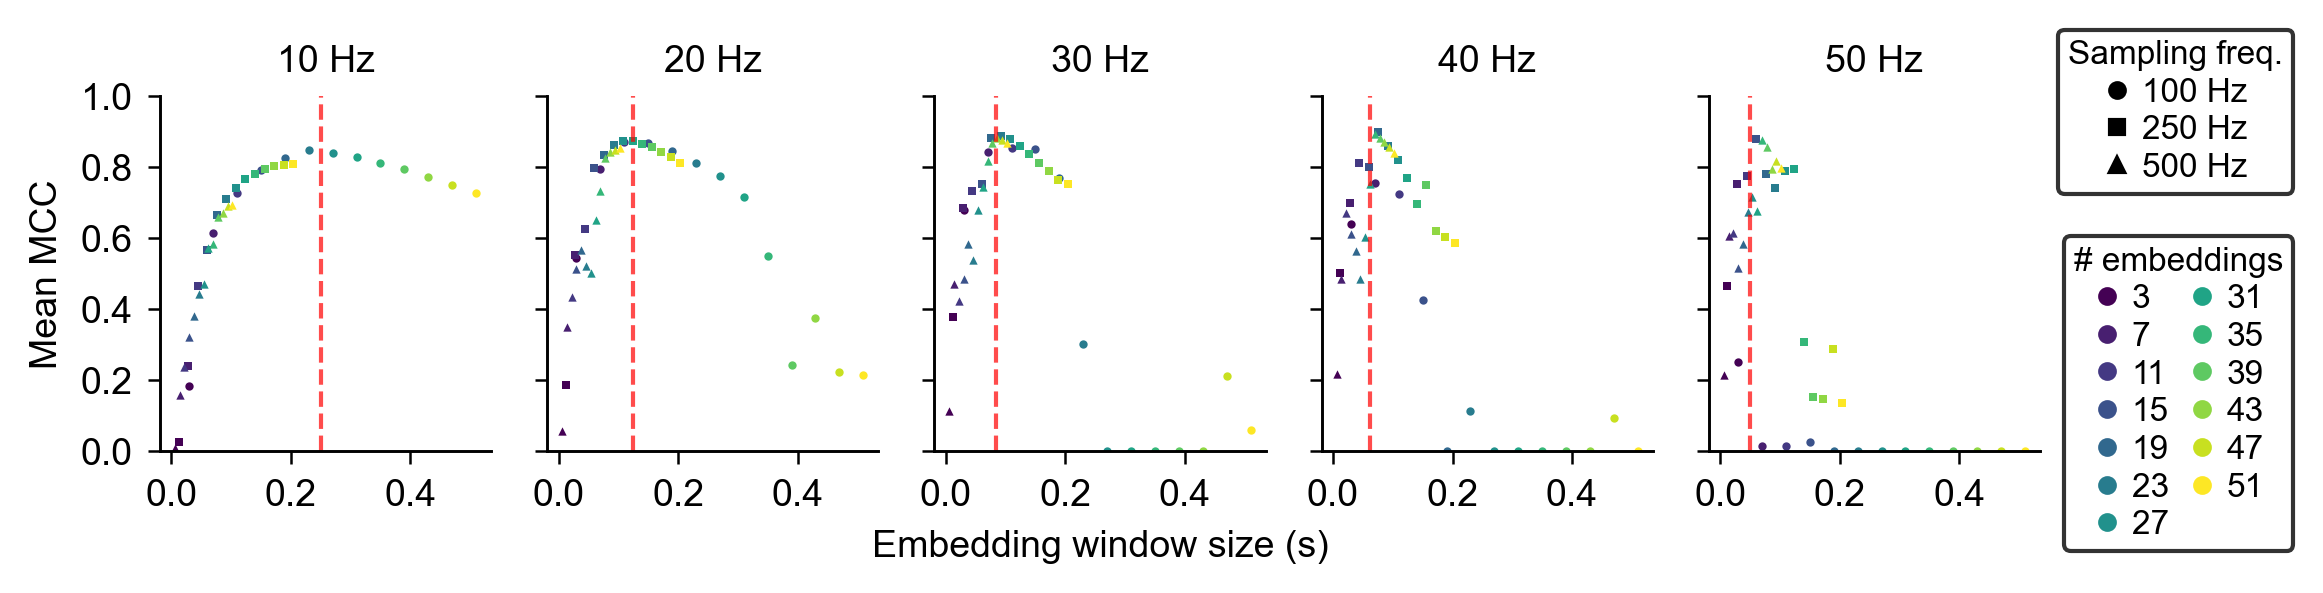

In [386]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from matplotlib.ticker import MultipleLocator

plt.rcParams["axes.edgecolor"] = "black"

# =========================
# CONFIG
# =========================
TRUTH_CYCLES = 2.5          # vertical red line at TRUTH_CYCLES / burst_f (seconds)
SCATTER_SIZE = 4            # points in panels
LEG_FSIZE = 8
TITLE_FSIZE = 8
LEG_MARKERSIZE = 3.5        # marker size inside legends
RIGHT_MARGIN = 0.82         # reserve space for legends (tune 0.78–0.86)
ANCHOR_X = 0.91             # legend x position (keep near 1.0 to avoid wide save)

# =========================
# STABLE ORDERING
# =========================
methods   = list(mean_df["method"].dropna().unique())
burst_fs  = np.sort(mean_df["burst_f"].dropna().unique())
num_embs  = np.sort(mean_df["num_emb"].dropna().unique())
fs_levels = np.sort(mean_df["fs"].dropna().unique())

# =========================
# COLOR PALETTE (num_emb)
# =========================
cmap = plt.get_cmap("viridis")
if len(num_embs) == 1:
    palette = {num_embs[0]: cmap(0.5)}
else:
    palette = {emb: cmap(i / (len(num_embs) - 1)) for i, emb in enumerate(num_embs)}

# =========================
# MARKER MAP (fs)
# =========================
marker_cycle = ["o", "s", "^", "D", "P", "X", "v", "<", ">", "*", "h"]
if len(fs_levels) > len(marker_cycle):
    raise ValueError(f"Too many fs levels ({len(fs_levels)}). Add more markers.")
marker_map = {fs: marker_cycle[i] for i, fs in enumerate(fs_levels)}

# =========================
# FIGURE
# =========================
fig, axes = plt.subplots(
    len(methods), len(burst_fs),
    figsize=(FIG_WIDTH+1, 2),   # you control FIG_WIDTH externally
    sharex=True, sharey=True
)
axes = np.atleast_2d(axes)

# =========================
# PLOTTING
# =========================
for i, method in enumerate(methods):
    for j, bf in enumerate(burst_fs):
        ax = axes[i, j]
        sub_df = mean_df[(mean_df["method"] == method) & (mean_df["burst_f"] == bf)]

        ax.yaxis.set_major_locator(MultipleLocator(0.2))
        ax.xaxis.set_major_locator(MultipleLocator(0.2))
        ax.set_ylim(0, 1)

        # reference: TRUTH_CYCLES cycles of the simulated burst frequency
        ax.axvline(
            x=TRUTH_CYCLES / bf,
            color="red",
            linestyle="--",
            linewidth=1.0,
            alpha=0.7
        )

        # color encodes num_emb, shape encodes fs
        for (emb, fs), g in sub_df.groupby(["num_emb", "fs"], dropna=False):
            ax.scatter(
                g["window_size"], g["mean_mcc"],
                color=palette[emb],
                marker=marker_map[fs],
                s=SCATTER_SIZE,
                linewidths=0
            )

        if i == 0:
            ax.set_title(f"{bf:g} Hz")
        if j == 0:
            ax.set_ylabel("Mean MCC")

# x-label: bottom row, middle column
axes[-1, len(burst_fs)//2].set_xlabel("Embedding window size (s)")

# =========================
# LAYOUT: reserve legend strip on the right
# =========================
fig.subplots_adjust(right=RIGHT_MARGIN)
plt.tight_layout(rect=[0, 0, RIGHT_MARGIN, 1])

# =========================
# LEGENDS (your version)
# =========================
emb_handles = [
    mlines.Line2D(
        [], [], color=palette[emb], marker="o", linestyle="None",
        markersize=LEG_MARKERSIZE, label=f"{int(emb)}"
    )
    for emb in num_embs
]

leg1 = fig.legend(
    handles=emb_handles,
    title="# embeddings",
    loc="center right",
    bbox_to_anchor=(ANCHOR_X, 0.35),
    ncol=2,
    frameon=True,

    fontsize=LEG_FSIZE,
    title_fontsize=TITLE_FSIZE,

    borderpad=0.3,
    labelspacing=0.20,
    handletextpad=0.35,
    columnspacing=0.60,
    handlelength=0.8
)
leg1.get_frame().set_edgecolor("black")

fs_handles = [
    mlines.Line2D(
        [], [], color="black", marker=marker_map[fs], linestyle="None",
        markersize=LEG_MARKERSIZE, label=f"{int(fs)} Hz"
    )
    for fs in fs_levels
]

leg2 = fig.legend(
    handles=fs_handles,
    title="Sampling freq.",
    loc="center right",
    bbox_to_anchor=(ANCHOR_X, 0.82),
    ncol=1,
    frameon=True,

    fontsize=LEG_FSIZE,
    title_fontsize=TITLE_FSIZE,

    borderpad=0.3,
    labelspacing=0.20,
    handletextpad=0.35,
    handlelength=0.8
)
leg2.get_frame().set_edgecolor("black")

# =========================
# SAVE + SHOW
# =========================
fig.savefig(
    f"../figures/raw_figure/{sim_cond}_results.png",
    bbox_inches="tight",
    pad_inches=0.05,
)

plt.show()


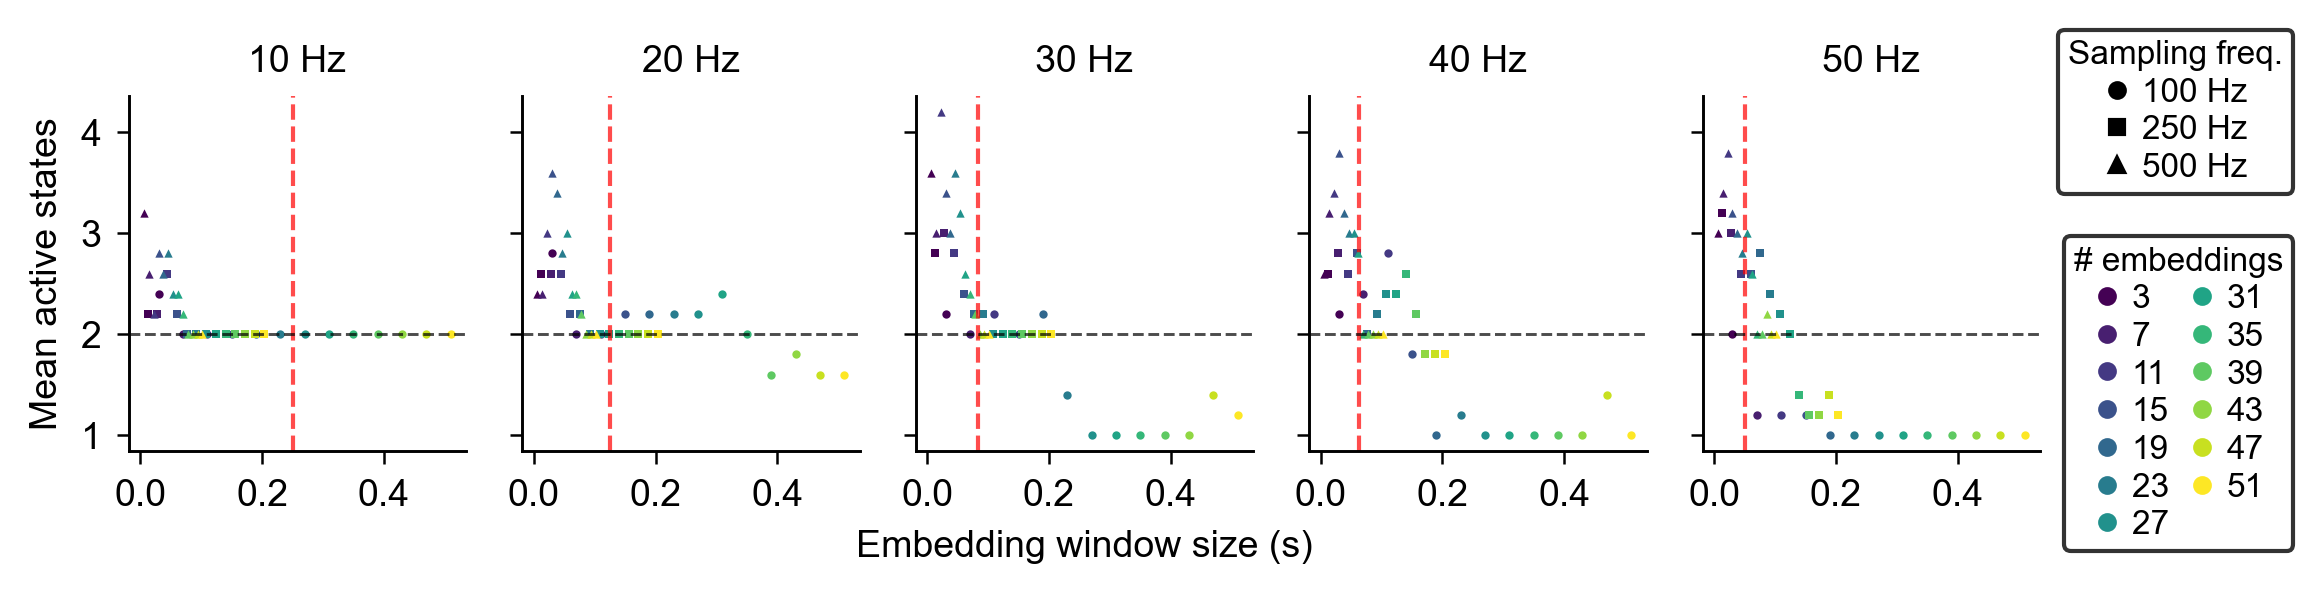

In [387]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from matplotlib.ticker import MultipleLocator

plt.rcParams["axes.edgecolor"] = "black"

# =========================
# CONFIG
# =========================
TRUTH_CYCLES = 2.5          # vertical red line at TRUTH_CYCLES / burst_f (seconds)
SCATTER_SIZE = 4            # points in panels
LEG_FSIZE = 8
TITLE_FSIZE = 8
LEG_MARKERSIZE = 3.5        # marker size inside legends
RIGHT_MARGIN = 0.82         # reserve space for legends (tune 0.78–0.86)
ANCHOR_X = 0.91             # legend x position (keep near 1.0 to avoid wide save)

# =========================
# STABLE ORDERING
# =========================
methods   = list(mean_df["method"].dropna().unique())
burst_fs  = np.sort(mean_df["burst_f"].dropna().unique())
num_embs  = np.sort(mean_df["num_emb"].dropna().unique())
fs_levels = np.sort(mean_df["fs"].dropna().unique())

# =========================
# COLOR PALETTE (num_emb)
# =========================
cmap = plt.get_cmap("viridis")
if len(num_embs) == 1:
    palette = {num_embs[0]: cmap(0.5)}
else:
    palette = {emb: cmap(i / (len(num_embs) - 1)) for i, emb in enumerate(num_embs)}

# =========================
# MARKER MAP (fs)
# =========================
marker_cycle = ["o", "s", "^", "D", "P", "X", "v", "<", ">", "*", "h"]
if len(fs_levels) > len(marker_cycle):
    raise ValueError(f"Too many fs levels ({len(fs_levels)}). Add more markers.")
marker_map = {fs: marker_cycle[i] for i, fs in enumerate(fs_levels)}

# =========================
# FIGURE
# =========================
fig, axes = plt.subplots(
    len(methods), len(burst_fs),
    figsize=(FIG_WIDTH+1, 2),   # you control FIG_WIDTH externally
    sharex=True, sharey=True
)
axes = np.atleast_2d(axes)

# =========================
# PLOTTING
# =========================
for i, method in enumerate(methods):
    for j, bf in enumerate(burst_fs):
        ax = axes[i, j]
        sub_df = mean_df[(mean_df["method"] == method) & (mean_df["burst_f"] == bf)]

        ax.yaxis.set_major_locator(MultipleLocator(1))
        ax.xaxis.set_major_locator(MultipleLocator(0.2))

        #ax.set_ylim(0, 1)

        # reference: TRUTH_CYCLES cycles of the simulated burst frequency
        ax.axvline(
            x=TRUTH_CYCLES / bf,
            color="red",
            linestyle="--",
            linewidth = 1,
            alpha=0.7
        )

        ax.axhline(
            y = 2,
            color="black",
            linestyle="--",
            linewidth=0.7,
            alpha=0.7
        )

        # color encodes num_emb, shape encodes fs
        for (emb, fs), g in sub_df.groupby(["num_emb", "fs"], dropna=False):
            ax.scatter(
                g["window_size"], g["mean_active_states"],
                color=palette[emb],
                marker=marker_map[fs],
                s=SCATTER_SIZE,
                linewidths=0
            )

        if i == 0:
            ax.set_title(f"{bf:g} Hz")
        if j == 0:
            ax.set_ylabel("Mean active states")

# x-label: bottom row, middle column
axes[-1, len(burst_fs)//2].set_xlabel("Embedding window size (s)")

# =========================
# LAYOUT: reserve legend strip on the right
# =========================
fig.subplots_adjust(right=RIGHT_MARGIN)
plt.tight_layout(rect=[0, 0, RIGHT_MARGIN, 1])

# =========================
# LEGENDS (your version)
# =========================
emb_handles = [
    mlines.Line2D(
        [], [], color=palette[emb], marker="o", linestyle="None",
        markersize=LEG_MARKERSIZE, label=f"{int(emb)}"
    )
    for emb in num_embs
]

leg1 = fig.legend(
    handles=emb_handles,
    title="# embeddings",
    loc="center right",
    bbox_to_anchor=(ANCHOR_X, 0.35),
    ncol=2,
    frameon=True,

    fontsize=LEG_FSIZE,
    title_fontsize=TITLE_FSIZE,

    borderpad=0.3,
    labelspacing=0.20,
    handletextpad=0.35,
    columnspacing=0.60,
    handlelength=0.8
)
leg1.get_frame().set_edgecolor("black")

fs_handles = [
    mlines.Line2D(
        [], [], color="black", marker=marker_map[fs], linestyle="None",
        markersize=LEG_MARKERSIZE, label=f"{int(fs)} Hz"
    )
    for fs in fs_levels
]

leg2 = fig.legend(
    handles=fs_handles,
    title="Sampling freq.",
    loc="center right",
    bbox_to_anchor=(ANCHOR_X, 0.82),
    ncol=1,
    frameon=True,

    fontsize=LEG_FSIZE,
    title_fontsize=TITLE_FSIZE,

    borderpad=0.3,
    labelspacing=0.20,
    handletextpad=0.35,
    handlelength=0.8
)
leg2.get_frame().set_edgecolor("black")

# =========================
# SAVE + SHOW
# =========================
fig.savefig(
    f"../figures/raw_figure/{sim_cond}_results_active_states.png",
    bbox_inches="tight",
    pad_inches=0.05,
)

plt.show()


# 3-state scenario

In [401]:
from nds_toolbox.preprocessing.features import choose_embedding_dim, trim_data


fs = 250         # Sampling frequency in Hz.
n_seconds = 60   # Total duration in seconds.
time_vec = np.linspace(0, n_seconds, int(fs * n_seconds))


# Condition 1: frequency distances (3 states)
freqs_dist_range = [[10, 40], [15, 40], [20, 40], [25, 40], [30, 40],[35, 40]]  #30, 25, 20, 15, 10, 5Hz diff

# Condition 2: Signal-to-noise ratio (in dB)
snr_range = np.arange(-10, 11, 2)  # varying SNRs from -10 to 10 dB




In [402]:
sim_cond_data = "3states"

# Condition 2: Signal-to-noise ratio (in dB)
snr_range = np.arange(-10, 11, 2)  # varying SNRs from -10 to 10 dB


signal_dir = "../data/simulations"
sim_data = np.load(f'{signal_dir}/{sim_cond_data}_data.npz')


#load the simulated data
signal_sample = sim_data['signal_sample']
states_sample = sim_data['states_sample']
bursts_sample = sim_data['bursts_sample']

print("shape of signal_sample", signal_sample.shape)

shape of signal_sample (5, 6, 11, 45000)


In [403]:
snr_range

array([-10,  -8,  -6,  -4,  -2,   0,   2,   4,   6,   8,  10])

In [404]:

sim_cond = "3states_est_k"


performance_dir = "../data/performance"
file_path = f"{performance_dir}/results_{sim_cond}.pkl"

import pickle
with open(file_path, "rb") as f:
    res = pickle.load(f)

df_list = [pd.DataFrame(r) for r in res]
gmm_df_3states = pd.concat(df_list, axis = 0, ignore_index = True)

gmm_df_3states["burst_f"] = gmm_df_3states["burst_f"].apply(tuple)

gmm_df_3states.head()

,method,signal,true_states,burst_f,fs,snr,est_params,loss_best,model_id_best,seed_best,...,fit_t,pred_t,total_time,num_states,num_emb,est_states,order,summary_stats,mcc,loss
0,DP-GMM,"[-1.0699453867332631, -0.5765764895141492, -0....","[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...","(10, 40)",250,-10,"{'alpha': 0.46134177, 'weights': [1.0], 'means...",0.7475662,4,1221367971,...,428.235102,0.595792,428.830893,11,25,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",None,0.0,0.7475662
1,DP-GMM (Imputed),"[-1.0699453867332631, -0.5765764895141492, -0....","[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...","(10, 40)",250,-10,"{'alpha': 0.46134177, 'weights': [1.0], 'means...",0.7475662,4,1221367971,...,428.235102,0.595792,428.830893,11,25,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",None,0.0,0.7475662
2,DP-GMM,"[1.1215779014010478, 0.2241747638346373, 0.649...","[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...","(10, 40)",250,-8,"{'alpha': 0.45768857, 'weights': [1.0], 'means...",0.65888107,0,3256907595,...,402.986185,0.006864,402.993049,11,25,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",None,0.0,0.65888107
3,DP-GMM (Imputed),"[1.1215779014010478, 0.2241747638346373, 0.649...","[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...","(10, 40)",250,-8,"{'alpha': 0.45768857, 'weights': [1.0], 'means...",0.65888107,0,3256907595,...,402.986185,0.006864,402.993049,11,25,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",None,0.0,0.65888107
4,DP-GMM,"[0.45555721858453097, 0.7632128996220084, 0.37...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","(10, 40)",250,-6,"{'alpha': 0.38982844, 'weights': [1.0], 'means...",0.737614,6,3333691205,...,404.865891,0.009093,404.874984,11,25,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",None,0.0,0.737614


In [444]:



performance_dir = "../data/performance"
file_path = f"{performance_dir}/{sim_cond_data}_results.pkl"

import pickle
with open(file_path, "rb") as f:
    res = pickle.load(f)

df_list = [pd.DataFrame(r) for r in res]
df_3states = pd.concat(df_list, axis = 0, ignore_index = True)

df_3states["burst_f"] = df_3states["burst_f"].apply(tuple)

df_3states.head()

,method,signal,true_states,burst_f,fs,snr,est_params,loss_best,model_id_best,seed_best,...,pred_t,total_time,num_states,num_emb,est_states,order,summary_stats,mcc,loss,best_model_id
0,DP-GMM,"[-1.0699453867332631, -0.5765764895141492, -0....","[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...","(10, 40)",250,-10,"{'alpha': 1481.1799, 'weights': [0.0002643804,...",0.74750763,4.0,1.221368e+09,...,0.600014,84.720967,3,25,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[1, 2, 0]",None,0.004152,0.74750763,NaN
1,DP-GMM (Imputed),"[-1.0699453867332631, -0.5765764895141492, -0....","[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...","(10, 40)",250,-10,"{'alpha': 1481.1799, 'weights': [0.0002643804,...",0.74750763,4.0,1.221368e+09,...,0.600014,84.720967,3,25,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[1, 2, 0]",None,0.000000,0.74750763,NaN
2,HMM,"[-1.0699453867332631, -0.5765764895141492, -0....","[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...","(10, 40)",250,-10,"{'initial_probs': [0.31679845, 0.32383534, 0.3...",0.722242,NaN,NaN,...,0.111238,38.693617,3,25,"[2, 2, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 0, 2]",None,0.024007,0.722242,5.0
3,HMM (Imputed),"[-1.0699453867332631, -0.5765764895141492, -0....","[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...","(10, 40)",250,-10,"{'initial_probs': [0.31679845, 0.32383534, 0.3...",0.722242,NaN,NaN,...,0.111238,38.693617,3,25,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 0, 2]",None,0.021481,0.722242,5.0
4,Thresholding,"[-1.0699453867332631, -0.5765764895141492, -0....","[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...","(10, 40)",250,-10,"{'envelped_signal': [[0.17682067, 0.18038164, ...",NaN,NaN,NaN,...,0.001223,2.789531,3,25,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2, ...","[0, 1, 2]",None,0.198367,"[[0.4, 0.4], [0.4, 0.4]]",NaN


In [282]:
gmm_df_3states["method"]

0                DP-GMM
1      DP-GMM (Imputed)
2                DP-GMM
3      DP-GMM (Imputed)
4                DP-GMM
             ...       
655    DP-GMM (Imputed)
656              DP-GMM
657    DP-GMM (Imputed)
658              DP-GMM
659    DP-GMM (Imputed)
Name: method, Length: 660, dtype: object

In [283]:
freq

array([35, 40])

In [284]:
fs

250

In [437]:
from sklearn.metrics import matthews_corrcoef
from nds_toolbox.analysis.utils import imputing_mode


for i in range(len(gmm_df_3states)):
    
    method = gmm_df_3states.iloc[i]["method"]
    freq = np.array(gmm_df_3states.iloc[i]["burst_f"])
    snr = gmm_df_3states.iloc[i]["snr"]
    print(f"snr = {snr}; freqs = {freq}")
    
    

    
    true_states = gmm_df_3states.iloc[i]["true_states"]
    old_mcc = gmm_df_3states.iloc[i]["mcc"]
    est_params = gmm_df_3states.iloc[i]["est_params"]
    alpha = est_params["alpha"]
    weights = est_params["untrunc_weights"]
    means = est_params["untrunc_means"]
    covs = est_params["untrunc_covs"]
    signal = gmm_df_3states.iloc[i]["signal"]
    num_emb = gmm_df_3states.iloc[i]["num_emb"]
    tde_data = compute_tde(signal, num_emb)

    trunc_means, trunc_covs, trunc_weights, trunc_info = truncate(means, covs, weights, verbose=True, return_info= True)


    num_active_states = int(len(trunc_weights))

    #the estimated states with truncated params
    est_states = get_states(tde_data, trunc_means, trunc_covs, trunc_weights)
    
    if method == "DP-GMM (Imputed)":
        
    #knn imputation
        min_samples = np.round((2/np.max(freq))*fs).astype(int)

        est_states = imputing_mode(est_states, min_samples = min_samples)

    est_states_onehot = np.eye(num_active_states)[est_states]

    trimmed_states = trim_data(true_states, num_emb, verbose = False)


    true_states_onehot = np.eye(trimmed_states.max()+1, dtype=np.float32)[trimmed_states]



    order, reordered_est_states_onehot = match_states(
        true_states_onehot, est_states_onehot, verbose=False
    )
    est_states = np.argmax(reordered_est_states_onehot, axis=1)
    


    mcc = matthews_corrcoef(trimmed_states, est_states)
    
    est_params = {
    "alpha": alpha,
    "weights": trunc_weights,
    "means": trunc_means,
    "covs": trunc_covs,
    "untrunc_means": means,
    "untrunc_covs": covs,
    "untrunc_weights": weights,
    "num_states_active":num_active_states,
    "trunc_info": trunc_info,}

    

    gmm_df_3states.at[i, "est_params"] = est_params
    gmm_df_3states.at[i, "mcc"] = float(mcc)
    gmm_df_3states.at[i, "est_states"] = np.asarray(est_states)
    gmm_df_3states.at[i, "num_active_states"] = num_active_states
    #print("mcc", old_mcc)
    #print("new mcc", mcc)
    #print()
    #print()

snr = -10; freqs = [10 40]
12 data points were lost from both ends.
data shape: (44976, 25)
[truncate] mass_threshold=0.990 | kept 1/11 | mass kept=0.9998 | mass dropped=0.0002 | removed_edge=0 (cv>0.2)
snr = -10; freqs = [10 40]
12 data points were lost from both ends.
data shape: (44976, 25)
[truncate] mass_threshold=0.990 | kept 1/11 | mass kept=0.9998 | mass dropped=0.0002 | removed_edge=0 (cv>0.2)
no missing values
snr = -8; freqs = [10 40]
12 data points were lost from both ends.
data shape: (44976, 25)
[truncate] mass_threshold=0.990 | kept 1/11 | mass kept=0.9987 | mass dropped=0.0013 | removed_edge=0 (cv>0.2)
snr = -8; freqs = [10 40]
12 data points were lost from both ends.
data shape: (44976, 25)
[truncate] mass_threshold=0.990 | kept 1/11 | mass kept=0.9987 | mass dropped=0.0013 | removed_edge=0 (cv>0.2)
no missing values
snr = -6; freqs = [10 40]
12 data points were lost from both ends.
data shape: (44976, 25)
[truncate] mass_threshold=0.990 | kept 1/11 | mass kept=0.9998 

In [445]:
methods = ["DP-GMM (Imputed)", "DP-GMM"]

# 1) drop old DP-GMM rows
df_keep = df_3states.loc[~df_3states["method"].isin(methods)].copy()

# 2) append new DP-GMM rows (your source of truth)
df_3states = pd.concat([df_keep, gmm_df_3states.copy()], ignore_index=True)


In [446]:
df_3states

,method,signal,true_states,burst_f,fs,snr,est_params,loss_best,model_id_best,seed_best,...,num_states,num_emb,est_states,order,summary_stats,mcc,loss,best_model_id,num_states_active,num_active_states
0,HMM,"[-1.0699453867332631, -0.5765764895141492, -0....","[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...","(10, 40)",250,-10,"{'initial_probs': [0.31679845, 0.32383534, 0.3...",0.722242,NaN,NaN,...,3,25,"[2, 2, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 0, 2]",None,0.024007,0.722242,5.0,NaN,NaN
1,HMM (Imputed),"[-1.0699453867332631, -0.5765764895141492, -0....","[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...","(10, 40)",250,-10,"{'initial_probs': [0.31679845, 0.32383534, 0.3...",0.722242,NaN,NaN,...,3,25,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 0, 2]",None,0.021481,0.722242,5.0,NaN,NaN
2,Thresholding,"[-1.0699453867332631, -0.5765764895141492, -0....","[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...","(10, 40)",250,-10,"{'envelped_signal': [[0.17682067, 0.18038164, ...",NaN,NaN,NaN,...,3,25,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2, ...","[0, 1, 2]",None,0.198367,"[[0.4, 0.4], [0.4, 0.4]]",NaN,NaN,NaN
3,Thresholding (Imputed),"[-1.0699453867332631, -0.5765764895141492, -0....","[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...","(10, 40)",250,-10,"{'envelped_signal': [[0.17682067, 0.18038164, ...",NaN,NaN,NaN,...,3,25,"[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...","[0, 1, 2]",None,0.202390,"[[0.4, 0.4], [0.4, 0.4]]",NaN,NaN,NaN
4,HMM,"[1.1215779014010478, 0.2241747638346373, 0.649...","[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...","(10, 40)",250,-8,"{'initial_probs': [0.34434733, 0.3593983, 0.29...",0.63744,NaN,NaN,...,3,25,"[1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, ...","[0, 1, 2]",None,0.067480,0.63744,6.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1975,DP-GMM (Imputed),"[-0.585752840657076, -0.5225019175848771, 0.72...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","(35, 40)",250,6,"{'alpha': 2.453237, 'weights': [0.3648699, 0.5...",0.8027298,6.0,4.240274e+09,...,11,17,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[1, 7, 5, 0, 2, 3, 4, 6, 8, 9, 10]",None,0.509819,0.8027298,NaN,9.0,4.0
1976,DP-GMM,"[-0.5602830309228354, -0.4702556864406927, -0....","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","(35, 40)",250,8,"{'alpha': 1.617581, 'weights': [0.058748916, 0...",0.76228964,1.0,2.613999e+09,...,11,17,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[2, 3, 0, 1, 4, 5, 6, 7, 8, 9, 10]",None,0.711242,0.76228964,NaN,9.0,4.0
1977,DP-GMM (Imputed),"[-0.5602830309228354, -0.4702556864406927, -0....","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","(35, 40)",250,8,"{'alpha': 1.617581, 'weights': [0.058748916, 0...",0.76228964,1.0,2.613999e+09,...,11,17,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[2, 3, 0, 1, 4, 5, 6, 7, 8, 9, 10]",None,0.798708,0.76228964,NaN,9.0,4.0
1978,DP-GMM,"[1.9687612318889252, 1.5823072164536132, 2.372...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","(35, 40)",250,10,"{'alpha': 0.91289306, 'weights': [0.027343739,...",0.6277919,2.0,2.239950e+09,...,11,17,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[3, 1, 4, 0, 2, 5, 6, 7, 8, 9, 10]",None,0.392419,0.6277919,NaN,8.0,4.0


In [447]:
res = df_3states.query("burst_f == @plot_f and snr == @snr_db")
dpgmm_res = res.query("method == 'DP-GMM (Imputed)'").iloc[sample_id]


In [448]:
num_states = 3
snr_db = 0
snr_id = np.where(snr_range == snr_db)[0][0]
plot_f = (20, 40)
freq_id = np.where((np.array(freqs_dist_range) == np.array(plot_f)).all(axis=1))[0][0]

sample_id = 0

res = df_3states.query("burst_f == @plot_f and snr == @snr_db")
dpgmm_res = res.query("method == 'DP-GMM (Imputed)'").iloc[sample_id]
hmm_res = res.query("method == 'HMM (Imputed)'").iloc[sample_id]
thresh_res = res.query("method == 'Thresholding (Imputed)'").iloc[sample_id]


num_emb = int(res.num_emb.values[0])


dpgmm_states =dpgmm_res.est_states
dpgmm_mcc = dpgmm_res.mcc
dpgmm_states_onehot = np.eye(num_states)[dpgmm_states]

hmm_states = hmm_res.est_states
hmm_mcc = hmm_res.mcc
hmm_states_onehot = np.eye(num_states)[hmm_states]

thresh_states = thresh_res.est_states
thresh_mcc = thresh_res.mcc
thresh_states_onehot = np.eye(num_states)[thresh_states]





trimmed_signal = trim_data(signal_sample[sample_id, freq_id, snr_id], num_emb)
trimmed_states = trim_data(states_sample[sample_id, freq_id, snr_id], num_emb).astype(int)
trimmed_bursts = trim_data(bursts_sample[sample_id, freq_id, snr_id], num_emb)


trimmed_time_vec = np.linspace(0, len(trimmed_states)/fs, len(trimmed_states))
states_onehot = np.eye(num_states)[trimmed_states]

Lost 10 data points were lost from both ends.
data shape: (44980,)
Lost 10 data points were lost from both ends.
data shape: (44980,)
Lost 10 data points were lost from both ends.
data shape: (44980,)


In [449]:
df_3states.query("burst_f == @plot_f")

,method,signal,true_states,burst_f,fs,snr,est_params,loss_best,model_id_best,seed_best,...,num_states,num_emb,est_states,order,summary_stats,mcc,loss,best_model_id,num_states_active,num_active_states
88,HMM,"[0.324849481937262, 0.5456342563612496, -0.218...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","(20, 40)",250,-10,"{'initial_probs': [0.43100742, 0.28147048, 0.2...",0.84669,NaN,NaN,...,3,21,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[1, 0, 2]",None,0.056091,0.84669,3.0,NaN,NaN
89,HMM (Imputed),"[0.324849481937262, 0.5456342563612496, -0.218...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","(20, 40)",250,-10,"{'initial_probs': [0.43100742, 0.28147048, 0.2...",0.84669,NaN,NaN,...,3,21,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[1, 0, 2]",None,0.060624,0.84669,3.0,NaN,NaN
90,Thresholding,"[0.324849481937262, 0.5456342563612496, -0.218...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","(20, 40)",250,-10,"{'envelped_signal': [[0.08172642, 0.08020275, ...",NaN,NaN,NaN,...,3,21,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 2]",None,0.179011,"[[0.4, 0.30000000000000004], [0.4, 0.4]]",NaN,NaN,NaN
91,Thresholding (Imputed),"[0.324849481937262, 0.5456342563612496, -0.218...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","(20, 40)",250,-10,"{'envelped_signal': [[0.08172642, 0.08020275, ...",NaN,NaN,NaN,...,3,21,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 2]",None,0.178622,"[[0.4, 0.30000000000000004], [0.4, 0.4]]",NaN,NaN,NaN
92,HMM,"[-1.5008340711002028, -0.4961152241150958, -0....","[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...","(20, 40)",250,-8,"{'initial_probs': [0.534522, 0.27629435, 0.189...",0.692557,NaN,NaN,...,3,21,"[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0, ...","[1, 2, 0]",None,0.117607,0.692557,3.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1909,DP-GMM (Imputed),"[1.3634175400290127, 0.8228606460439072, 1.475...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","(20, 40)",250,6,"{'alpha': 0.75730455, 'weights': [0.14835525, ...",0.784317,4.0,2.571633e+09,...,11,21,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[1, 4, 2, 0, 3, 5, 6, 7, 8, 9, 10]",None,0.930886,0.784317,NaN,8.0,4.0
1910,DP-GMM,"[0.29867663374114295, 0.46863098951003174, 1.1...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","(20, 40)",250,8,"{'alpha': 2.3501172, 'weights': [0.45300996, 0...",0.7036424,0.0,2.968545e+09,...,11,21,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[0, 4, 7, 1, 2, 3, 5, 6, 8, 9, 10]",None,0.489579,0.7036424,NaN,8.0,4.0
1911,DP-GMM (Imputed),"[0.29867663374114295, 0.46863098951003174, 1.1...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","(20, 40)",250,8,"{'alpha': 2.3501172, 'weights': [0.45300996, 0...",0.7036424,0.0,2.968545e+09,...,11,21,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[0, 4, 7, 1, 2, 3, 5, 6, 8, 9, 10]",None,0.251796,0.7036424,NaN,8.0,4.0
1912,DP-GMM,"[0.6722647544305983, 0.6033643623014291, 0.923...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","(20, 40)",250,10,"{'alpha': 0.88444537, 'weights': [0.85214555, ...",0.63880306,1.0,1.339808e+09,...,11,21,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 4, 2, 1, 3, 5, 6, 7, 8, 9, 10]",None,0.786722,0.63880306,NaN,7.0,4.0


In [450]:
df_3states.head()

,method,signal,true_states,burst_f,fs,snr,est_params,loss_best,model_id_best,seed_best,...,num_states,num_emb,est_states,order,summary_stats,mcc,loss,best_model_id,num_states_active,num_active_states
0,HMM,"[-1.0699453867332631, -0.5765764895141492, -0....","[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...","(10, 40)",250,-10,"{'initial_probs': [0.31679845, 0.32383534, 0.3...",0.722242,NaN,NaN,...,3,25,"[2, 2, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 0, 2]",None,0.024007,0.722242,5.0,NaN,NaN
1,HMM (Imputed),"[-1.0699453867332631, -0.5765764895141492, -0....","[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...","(10, 40)",250,-10,"{'initial_probs': [0.31679845, 0.32383534, 0.3...",0.722242,NaN,NaN,...,3,25,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 0, 2]",None,0.021481,0.722242,5.0,NaN,NaN
2,Thresholding,"[-1.0699453867332631, -0.5765764895141492, -0....","[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...","(10, 40)",250,-10,"{'envelped_signal': [[0.17682067, 0.18038164, ...",NaN,NaN,NaN,...,3,25,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2, ...","[0, 1, 2]",None,0.198367,"[[0.4, 0.4], [0.4, 0.4]]",NaN,NaN,NaN
3,Thresholding (Imputed),"[-1.0699453867332631, -0.5765764895141492, -0....","[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...","(10, 40)",250,-10,"{'envelped_signal': [[0.17682067, 0.18038164, ...",NaN,NaN,NaN,...,3,25,"[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...","[0, 1, 2]",None,0.202390,"[[0.4, 0.4], [0.4, 0.4]]",NaN,NaN,NaN
4,HMM,"[1.1215779014010478, 0.2241747638346373, 0.649...","[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...","(10, 40)",250,-8,"{'initial_probs': [0.34434733, 0.3593983, 0.29...",0.63744,NaN,NaN,...,3,25,"[1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, ...","[0, 1, 2]",None,0.067480,0.63744,6.0,NaN,NaN


In [468]:

df_avg = (
    df_3states.query("burst_f == @plot_f")
    .groupby(["method", "snr"], as_index = False)
    .agg(
        mcc_mean = ("mcc", "mean"),
        mcc_sem = ("mcc", lambda x: np.std(x, ddof = 1) / np.sqrt(len(x))),
        mcc_std = ("mcc", "std"),))




In [469]:

df_avg.head()


,method,snr,mcc_mean,mcc_sem,mcc_std
0,DP-GMM,-10,0.000000,0.001500,0.003354
1,DP-GMM,-8,0.039826,0.020460,0.045751
2,DP-GMM,-6,0.000000,0.030231,0.067598
3,DP-GMM,-4,0.508717,0.010074,0.022526
4,DP-GMM,-2,0.675043,0.009308,0.020813


In [470]:
df_3states.method.values


array(['HMM', 'HMM (Imputed)', 'Thresholding', ..., 'DP-GMM (Imputed)',
       'DP-GMM', 'DP-GMM (Imputed)'], shape=(1980,), dtype=object)

In [471]:
def relabel_freqs(burst_f):
    f0, f1 = burst_f 
    label = f"{str(f0)}&{str(f1)}"
    return label


df_3states["burst_f"] = df_3states["burst_f"].apply(relabel_freqs)


ValueError: too many values to unpack (expected 2)

In [472]:
df_3states["snr"].value_counts()

snr
-10    180
-8     180
-6     180
-4     180
-2     180
 0     180
 2     180
 4     180
 6     180
 8     180
 10    180
Name: count, dtype: int64

/var/folders/5z/yggynsqj6632pbql_bb3kqm40000gn/T/ipykernel_5624/17111727.py:114: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


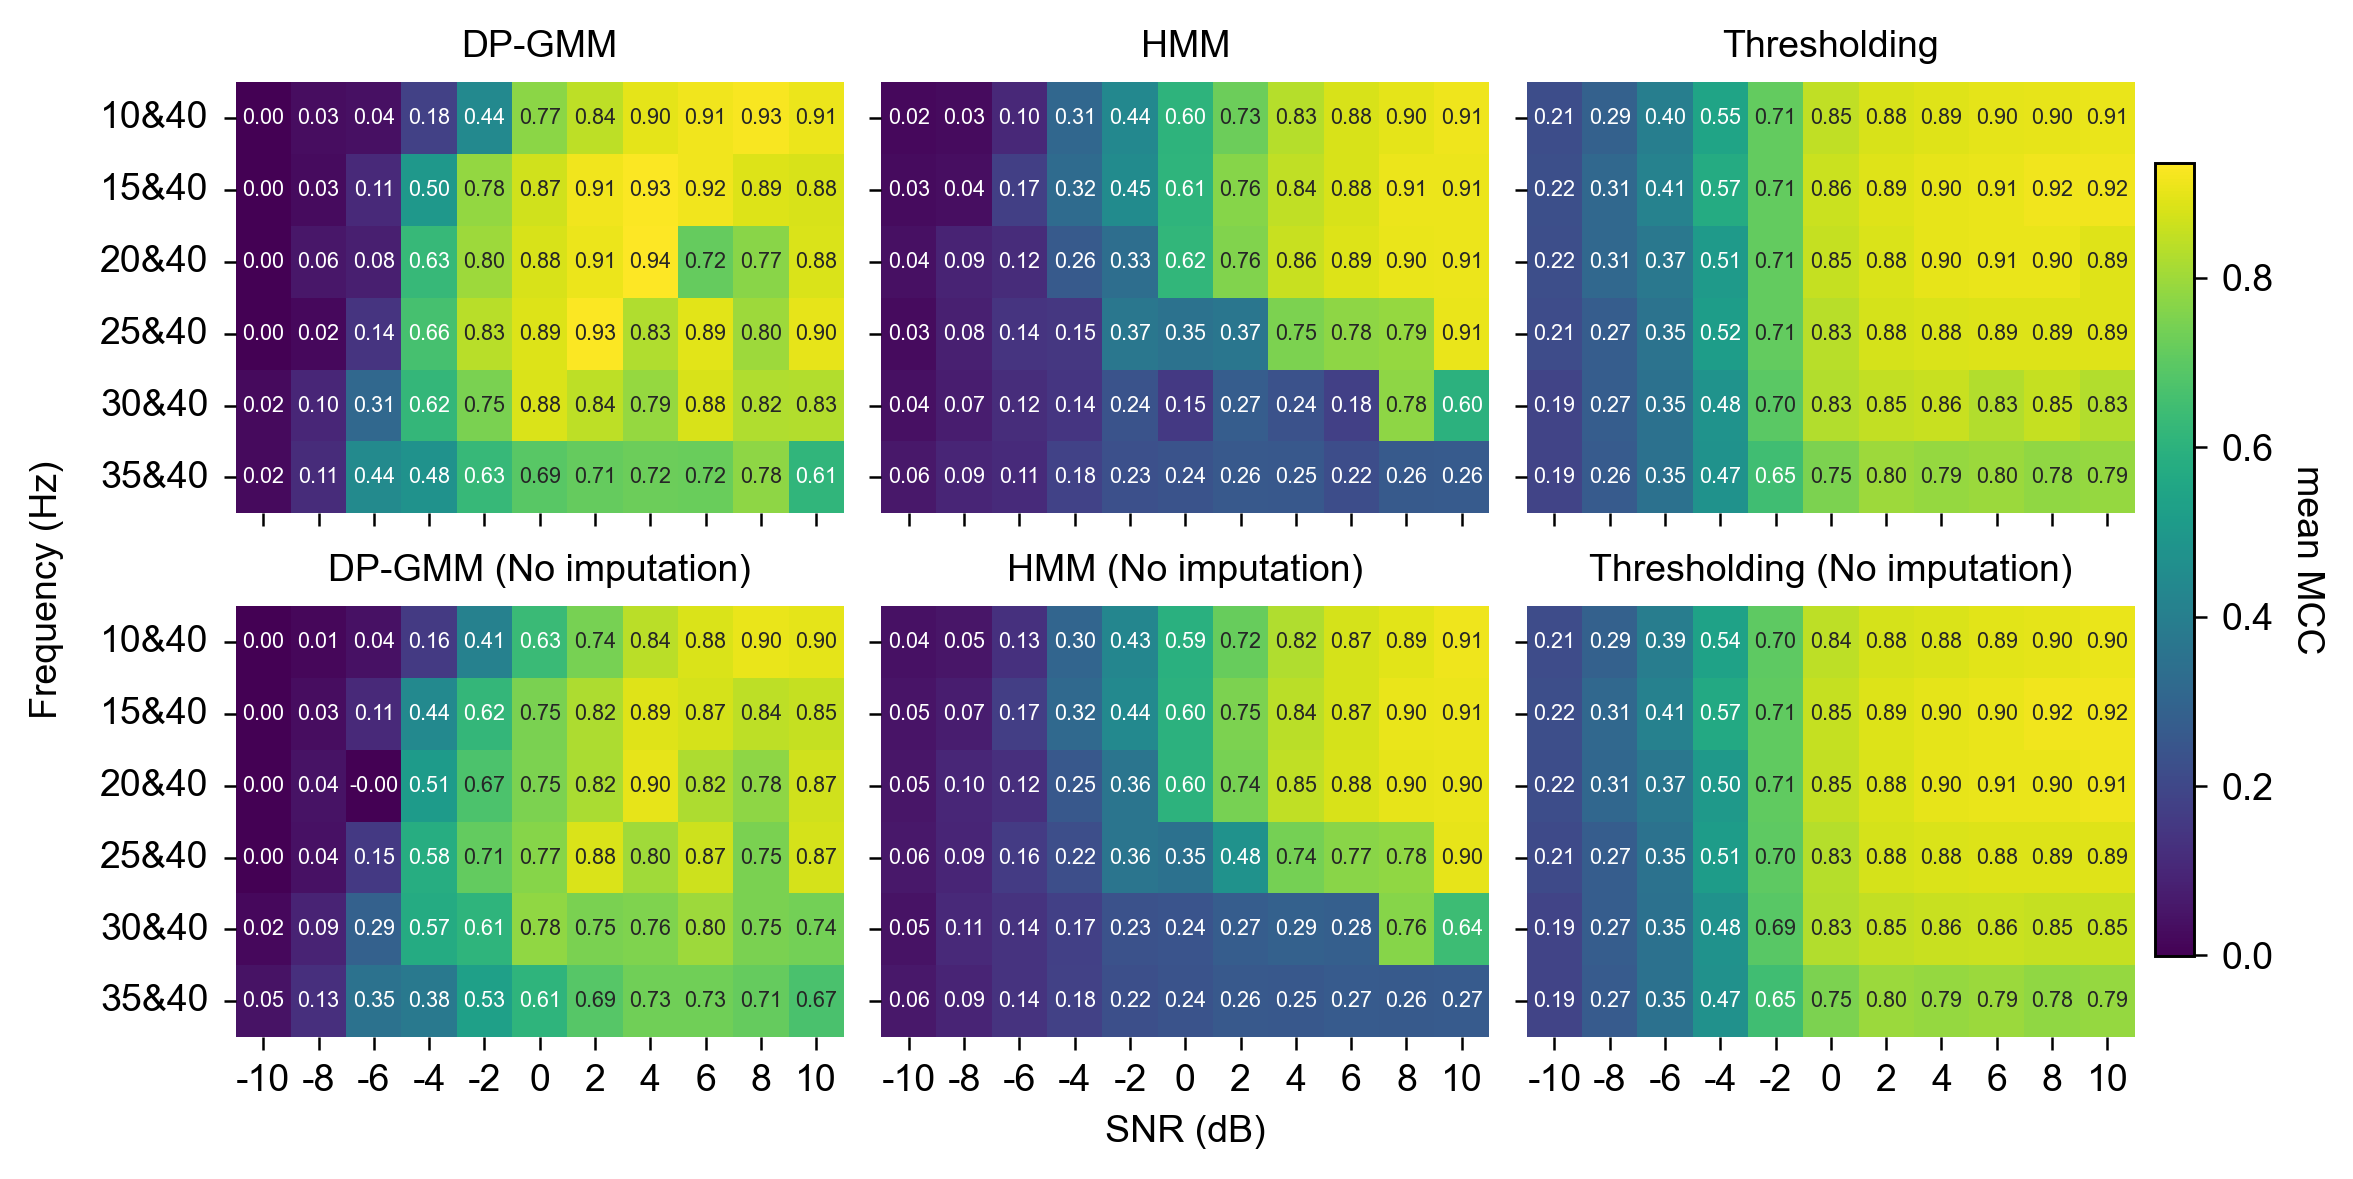

In [473]:
import numpy as np
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.ticker import MaxNLocator



method_names = set(df_3states.method.values)



dpgmm_heat = (df_3states.query("method == 'DP-GMM'")
        .pivot_table(index="burst_f", columns="snr", values="mcc", aggfunc="mean")
        .sort_index(axis=0) 
        .sort_index(axis=1))

hmm_heat = (df_3states.query("method == 'HMM'")
        .pivot_table(index="burst_f", columns="snr", values="mcc", aggfunc="mean")
        .sort_index(axis=0)   # freq ascending
        .sort_index(axis=1))  # snr ascending



thresh_heat = (df_3states.query("method == 'Thresholding'")
        .pivot_table(index="burst_f", columns="snr", values="mcc", aggfunc="mean")
        .sort_index(axis=0) 
        .sort_index(axis=1))




dpgmm_imputed_heat = (df_3states.query("method == 'DP-GMM (Imputed)'")
        .pivot_table(index="burst_f", columns="snr", values="mcc", aggfunc="mean")
        .sort_index(axis=0) 
        .sort_index(axis=1))


hmm_imputed_heat = (df_3states.query("method == 'HMM (Imputed)'")
        .pivot_table(index="burst_f", columns="snr", values="mcc", aggfunc="mean")
        .sort_index(axis=0)   # freq ascending
        .sort_index(axis=1))  # snr ascending


thresh_imputed_heat = (df_3states.query("method == 'Thresholding (Imputed)'")
        .pivot_table(index="burst_f", columns="snr", values="mcc", aggfunc="mean")
        .sort_index(axis=0) 
        .sort_index(axis=1))




mats = [
    dpgmm_heat, hmm_heat, thresh_heat,
    dpgmm_imputed_heat, hmm_imputed_heat, thresh_imputed_heat
]

vmin = np.nanmin([m.to_numpy() for m in mats])
vmax = np.nanmax([m.to_numpy() for m in mats])




common = dict(
    annot=True, fmt=".2f", annot_kws={"size": 5.2},
    cmap="viridis", vmin=vmin, vmax=vmax,
    cbar=False
)


fig, ax = plt.subplots(2, 3, figsize=(FIG_WIDTH, 4), sharex=True, sharey=True)

sns.heatmap(dpgmm_imputed_heat, **common, ax=ax[0,0])
ax[0,0].set_title("DP-GMM")

sns.heatmap(hmm_imputed_heat, **common, ax=ax[0,1])
ax[0,1].set_title("HMM")

sns.heatmap(thresh_imputed_heat, **common, ax=ax[0,2])
ax[0,2].set_title("Thresholding")

sns.heatmap(dpgmm_heat, **common, ax=ax[1,0])
ax[1,0].xaxis.set_major_locator(MaxNLocator(6))
ax[1,0].set_title("DP-GMM (No imputation)")

sns.heatmap(hmm_heat, **common, ax=ax[1,1])
ax[1,1].set_title("HMM (No imputation)")

sns.heatmap(thresh_heat, **common, ax=ax[1,2])
ax[1,2].set_title("Thresholding (No imputation)")






sm = ScalarMappable(norm=Normalize(vmin=vmin, vmax=vmax), cmap="viridis")
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax.ravel().tolist(), fraction=0.02, pad=-0.05)
cbar.set_label("mean MCC",  rotation=270, labelpad=12)




for a in ax.flat:
    a.set_xlabel("")
    a.set_ylabel("")
    

fig.supylabel("Frequency (Hz)", fontsize = MY_FONT_SIZE)

ax[1,1].set_xlabel("SNR (dB)", fontsize = MY_FONT_SIZE)


plt.tight_layout()

fig.savefig(
    f"../figures/raw_figure/{sim_cond}heatmaps.jpg",
    bbox_inches="tight"
)





In [474]:


gmm_df_3states["num_states_active"] = [gmm_df_3states.iloc[i]["est_params"]["num_states_active"] for i in range(len(gmm_df_3states))]



In [475]:
mask = gmm_df_3states["method"].eq("DP-GMM (Imputed)")

gmm_df_3states[mask]["num_states_active"] = [len(np.unique(gmm_df_3states[mask].iloc[i]["est_states"])) for i in range(len(gmm_df_3states[mask]))]

/var/folders/5z/yggynsqj6632pbql_bb3kqm40000gn/T/ipykernel_5624/3231056030.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gmm_df_3states[mask]["num_states_active"] = [len(np.unique(gmm_df_3states[mask].iloc[i]["est_states"])) for i in range(len(gmm_df_3states[mask]))]


In [476]:
mask = gmm_df_3states["snr"].eq(6)
mask2 = gmm_df_3states["num_emb"].eq(21)

gmm_df_3states[mask&mask2]

,method,signal,true_states,burst_f,fs,snr,est_params,loss_best,model_id_best,seed_best,...,total_time,num_states,num_emb,est_states,order,summary_stats,mcc,loss,num_states_active,num_active_states
60,DP-GMM,"[-0.6691059679504556, -1.0328219928776812, -0....","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","(20, 40)",250,6,"{'alpha': 0.89132386, 'weights': [0.027428808,...",0.6971158,5,1356382251,...,351.335402,11,21,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[1, 2, 5, 0, 3, 4, 6, 7, 8, 9, 10]",None,0.907513,0.6971158,4,4.0
61,DP-GMM (Imputed),"[-0.6691059679504556, -1.0328219928776812, -0....","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","(20, 40)",250,6,"{'alpha': 0.89132386, 'weights': [0.027428808,...",0.6971158,5,1356382251,...,351.335402,11,21,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[1, 2, 5, 0, 3, 4, 6, 7, 8, 9, 10]",None,0.939832,0.6971158,4,4.0
82,DP-GMM,"[1.9539421894300137, 1.9357757252233807, 2.214...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","(25, 40)",250,6,"{'alpha': 2.6908736, 'weights': [0.8499195, 0....",0.6717073,7,3885186318,...,324.541311,11,21,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 3, 6, 0, 2, 4, 5, 7, 8, 9, 10]",None,0.796339,0.6717073,4,4.0
83,DP-GMM (Imputed),"[1.9539421894300137, 1.9357757252233807, 2.214...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","(25, 40)",250,6,"{'alpha': 2.6908736, 'weights': [0.8499195, 0....",0.6717073,7,3885186318,...,324.541311,11,21,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 3, 6, 0, 2, 4, 5, 7, 8, 9, 10]",None,0.842548,0.6717073,4,4.0
192,DP-GMM,"[-0.48085976855387796, -0.9785573214415595, 0....","[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...","(20, 40)",250,6,"{'alpha': 0.9097053, 'weights': [0.8484693, 0....",0.72820485,7,1071851561,...,351.604607,11,21,"[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...","[0, 2, 3, 1, 4, 5, 6, 7, 8, 9, 10]",None,0.932949,0.72820485,3,3.0
193,DP-GMM (Imputed),"[-0.48085976855387796, -0.9785573214415595, 0....","[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...","(20, 40)",250,6,"{'alpha': 0.9097053, 'weights': [0.8484693, 0....",0.72820485,7,1071851561,...,351.604607,11,21,"[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...","[0, 2, 3, 1, 4, 5, 6, 7, 8, 9, 10]",None,0.956150,0.72820485,3,3.0
214,DP-GMM,"[-1.6640094528793576, -1.2929135208758926, -0....","[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...","(25, 40)",250,6,"{'alpha': 0.8468274, 'weights': [0.8593395, 0....",0.78683215,0,3950503000,...,332.850011,11,21,"[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...","[0, 1, 3, 2, 4, 5, 6, 7, 8, 9, 10]",None,0.926474,0.78683215,3,3.0
215,DP-GMM (Imputed),"[-1.6640094528793576, -1.2929135208758926, -0....","[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...","(25, 40)",250,6,"{'alpha': 0.8468274, 'weights': [0.8593395, 0....",0.78683215,0,3950503000,...,332.850011,11,21,"[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...","[0, 1, 3, 2, 4, 5, 6, 7, 8, 9, 10]",None,0.942996,0.78683215,3,3.0
324,DP-GMM,"[0.1278159875319836, 1.097646277564559, 0.8719...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","(20, 40)",250,6,"{'alpha': 2.471493, 'weights': [0.8010436, 0.1...",0.7791117,6,4103832496,...,356.475021,11,21,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 2, 4, 1, 3, 5, 6, 7, 8, 9, 10]",None,0.921460,0.7791117,3,3.0
325,DP-GMM (Imputed),"[0.1278159875319836, 1.097646277564559, 0.8719...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","(20, 40)",250,6,"{'alpha': 2.471493, 'weights': [0.8010436, 0.1...",0.7791117,6,4103832496,...,356.475021,11,21,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 2, 4, 1, 3, 5, 6, 7, 8, 9, 10]",None,0.940392,0.7791117,3,3.0


In [477]:
gmm_df_3states.iloc[457][

SyntaxError: incomplete input (3332031090.py, line 1)

In [478]:
active_states_df = gmm_df_3states.groupby(["method", "snr"], as_index = False).agg(
    mean_active_states=("num_states_active", "mean"),
)


mask = gmm_df_3states["method"].eq("DP-GMM")


active_states_df = gmm_df_3states[mask].groupby(["snr"], as_index = False).agg(
    mean_active_states=("num_states_active", "mean"),
)

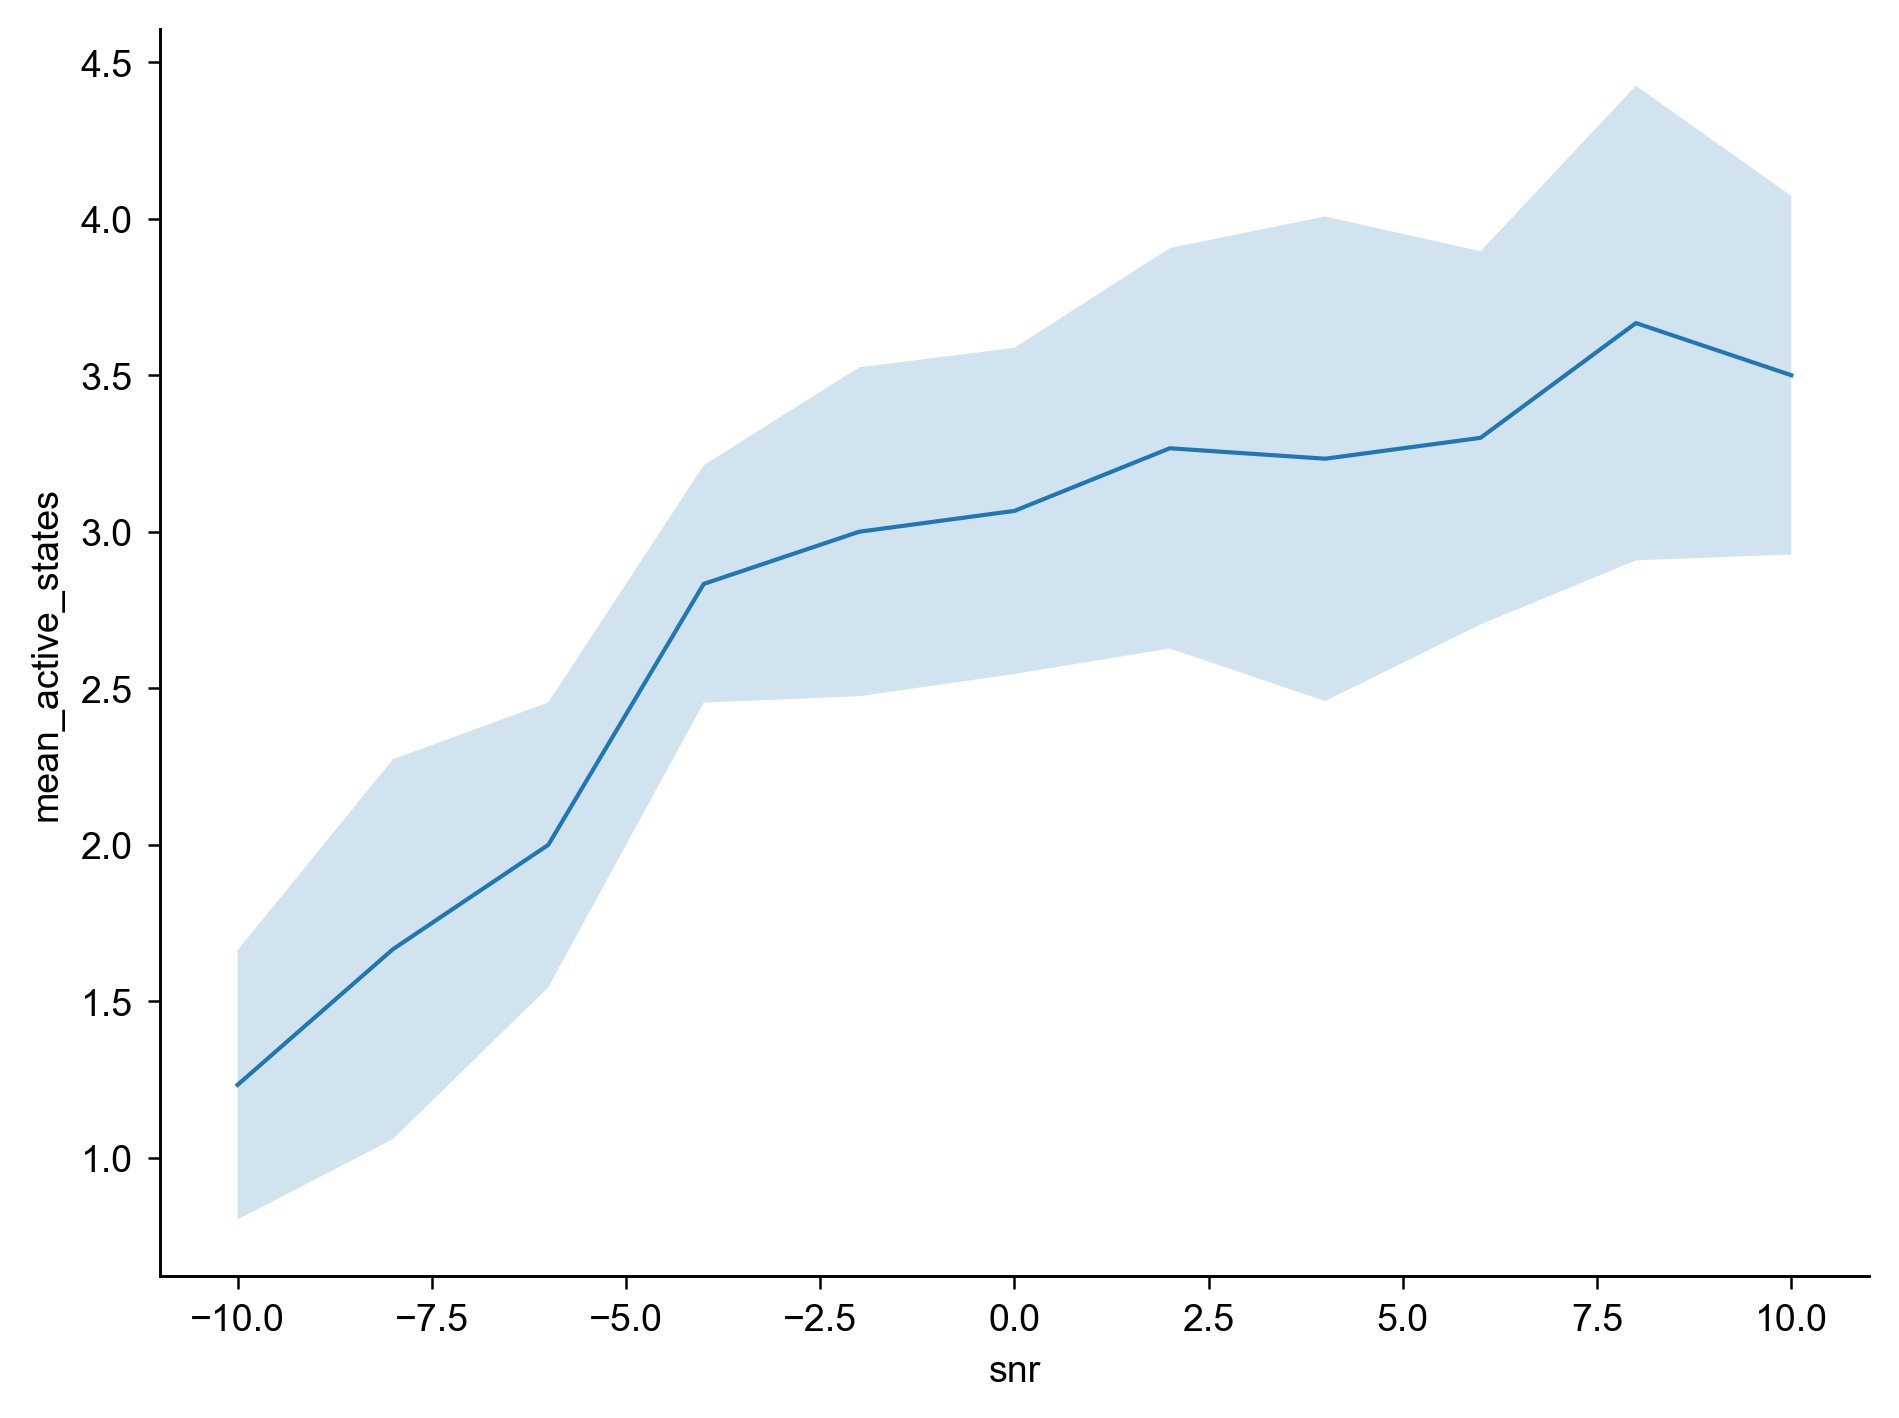

In [479]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

active_states_df = (
    gmm_df_3states.loc[mask]
    .groupby("snr", as_index=False)
    .agg(
        mean_active_states=("num_states_active", "mean"),
        std_active_states =("num_states_active", "std"),
    )
    .sort_values("snr")
)

ax = sns.lineplot(data=active_states_df, x="snr", y="mean_active_states")

x = active_states_df["snr"].to_numpy()
m = active_states_df["mean_active_states"].to_numpy()
s = active_states_df["std_active_states"].fillna(0).to_numpy()  # std=NaN if n=1

ax.fill_between(x, m - s, m + s, alpha=0.2)

plt.xlabel("snr")
plt.ylabel("mean_active_states")
plt.show()


/opt/anaconda3/envs/pymc_env/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 46.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/opt/anaconda3/envs/pymc_env/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 33.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/opt/anaconda3/envs/pymc_env/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 50.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/opt/anaconda3/envs/pymc_env/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 53.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/opt/anaconda3/envs/pymc_env/lib/python3.12/

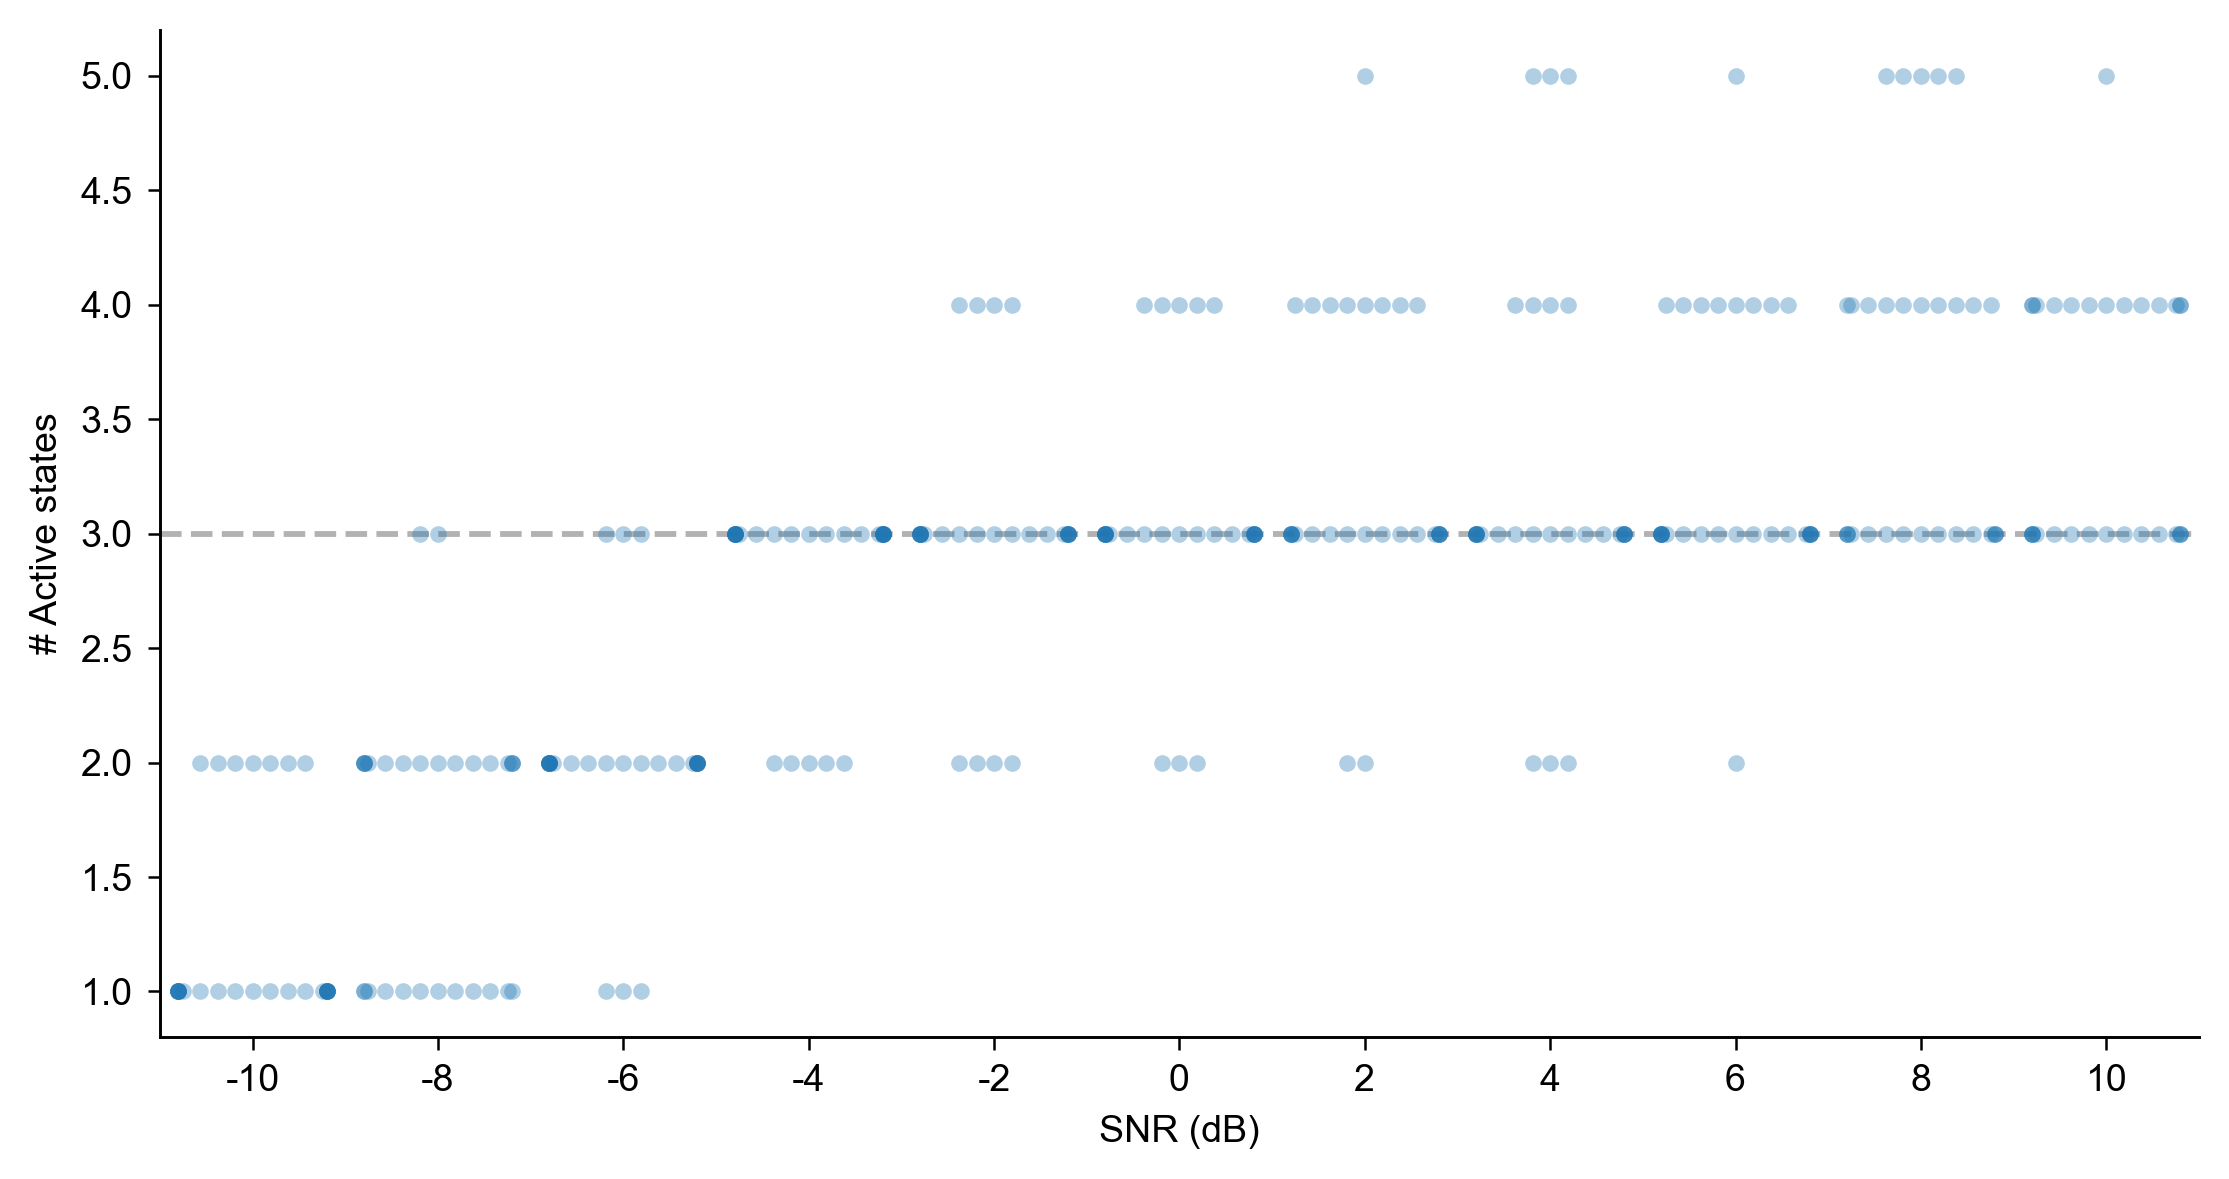

In [480]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(FIG_WIDTH,4))
ax = sns.swarmplot(
    data=gmm_df_3states.loc[mask],
    x="snr", y="num_states_active",
    size=4.0, alpha=0.35
)

ax.axhline(y=3, linestyle="--", linewidth=1.4, color = "black", alpha = 0.3)  # horizontal reference line

sns.despine(ax=ax)
ax.set_xlabel("SNR (dB)", fontsize = MY_FONT_SIZE)
ax.set_ylabel("# Active states", fontsize = MY_FONT_SIZE)
plt.tight_layout()
plt.show()


In [481]:
df_3states.head()

,method,signal,true_states,burst_f,fs,snr,est_params,loss_best,model_id_best,seed_best,...,num_states,num_emb,est_states,order,summary_stats,mcc,loss,best_model_id,num_states_active,num_active_states
0,HMM,"[-1.0699453867332631, -0.5765764895141492, -0....","[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...",10&40,250,-10,"{'initial_probs': [0.31679845, 0.32383534, 0.3...",0.722242,NaN,NaN,...,3,25,"[2, 2, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 0, 2]",None,0.024007,0.722242,5.0,NaN,NaN
1,HMM (Imputed),"[-1.0699453867332631, -0.5765764895141492, -0....","[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...",10&40,250,-10,"{'initial_probs': [0.31679845, 0.32383534, 0.3...",0.722242,NaN,NaN,...,3,25,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 0, 2]",None,0.021481,0.722242,5.0,NaN,NaN
2,Thresholding,"[-1.0699453867332631, -0.5765764895141492, -0....","[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...",10&40,250,-10,"{'envelped_signal': [[0.17682067, 0.18038164, ...",NaN,NaN,NaN,...,3,25,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2, ...","[0, 1, 2]",None,0.198367,"[[0.4, 0.4], [0.4, 0.4]]",NaN,NaN,NaN
3,Thresholding (Imputed),"[-1.0699453867332631, -0.5765764895141492, -0....","[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...",10&40,250,-10,"{'envelped_signal': [[0.17682067, 0.18038164, ...",NaN,NaN,NaN,...,3,25,"[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...","[0, 1, 2]",None,0.202390,"[[0.4, 0.4], [0.4, 0.4]]",NaN,NaN,NaN
4,HMM,"[1.1215779014010478, 0.2241747638346373, 0.649...","[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...",10&40,250,-8,"{'initial_probs': [0.34434733, 0.3593983, 0.29...",0.63744,NaN,NaN,...,3,25,"[1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, ...","[0, 1, 2]",None,0.067480,0.63744,6.0,NaN,NaN


In [482]:
plot_f = "20&40"

In [485]:

df_avg = (
    df_3states.query("burst_f == @plot_f")
    .groupby(["method", "snr"], as_index = False)
    .agg(
        mcc_mean = ("mcc", "median"),
        mcc_sem = ("mcc", lambda x: np.std(x, ddof = 1) / np.sqrt(len(x))),
        mcc_std = ("mcc", "std"),))




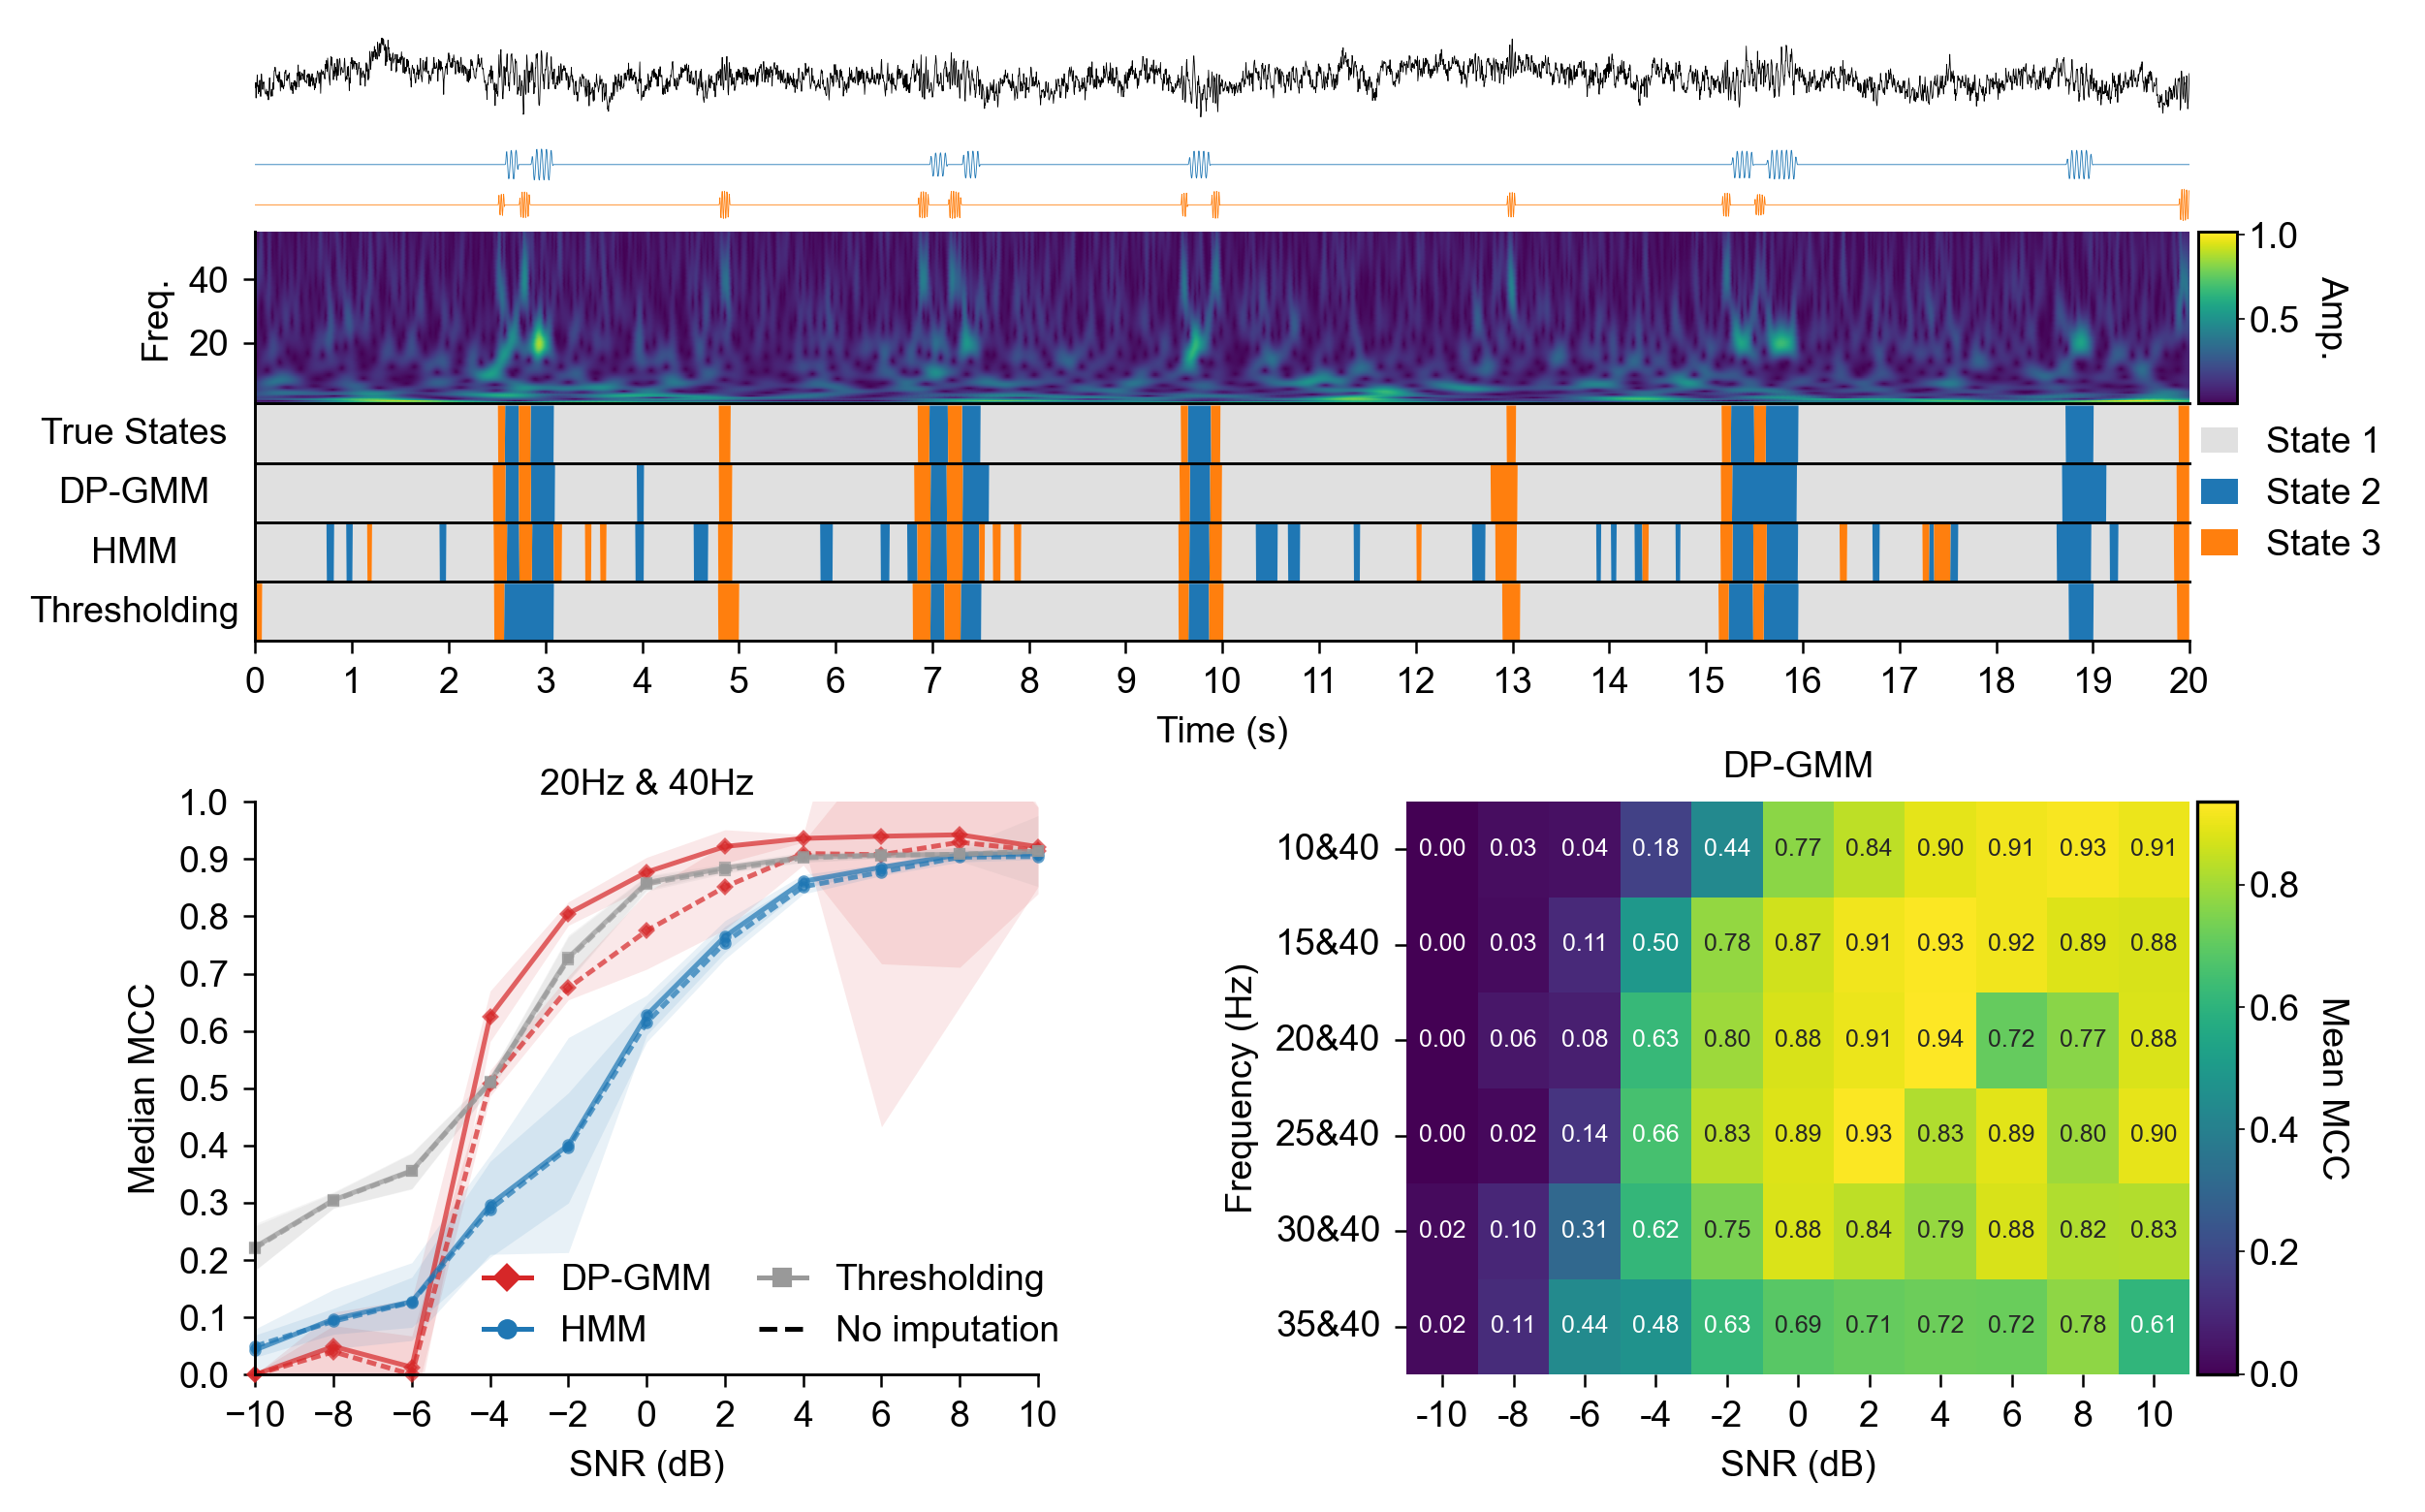

In [487]:

plt.close("all")

import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.lines import Line2D







plot_t = 20
#compute wavelet
t, f, amp = compute_wavelet(trimmed_signal[:plot_t*fs], fs, f_min = 1, f_max = 80, df = 0.5, wavelet = "cmor1.5-1.0")






cmap = plt.get_cmap("tab10")
colors = [cmap(i) for i in range(num_states)]
grey = ["#E0E0E0"]
colors = grey + colors
state_labels = [f"State {i+1}" for i in range(num_states)]



mosaic = [["b1", "b1"],
          ["b2", "b2"],
          ["b3", "b3"],
          ["b4", "b4"],
          ["b5", "b5"],
          ["b6", "b6"],
          ["a", "c"]
         ]

fig, axes = plt.subplot_mosaic(
    mosaic,
    figsize=(FIG_WIDTH, 5),  # a hair taller
    constrained_layout=True,
    gridspec_kw={"height_ratios":[0.7,0.6,0.2,0.2, 0.2,0.2,2]}
)
fig.set_constrained_layout_pads(w_pad=0., h_pad=0., hspace=0.01)




thresh_color = "#999999" # grey
hmm_color   = "#1f77b4"  # vivid blue
dpgmm_color   = "#d62728"

palette = {
    "Thresholding":                 thresh_color,
    "Thresholding (Imputed)":     thresh_color,
    "HMM":                   hmm_color,
    "HMM (Imputed)":       hmm_color,
    "DP-GMM":                 dpgmm_color,
    "DP-GMM (Imputed)":     dpgmm_color,
}

dashes = {
    "Thresholding":               (2, 1),      # dashed
    "Thresholding (Imputed)":   (None, None),# solid
    "HMM":                 (2, 1),
    "HMM (Imputed)":     (None, None),
    "DP-GMM":               (2, 1),
    "DP-GMM (Imputed)":   (None, None),
}

markers = {
    "Thresholding":               "s",   # square
    "Thresholding (Imputed)":   "s",
    "HMM":                 "o",   # circle
    "HMM (Imputed)":     "o",
    "DP-GMM":               "D",   # diamond
    "DP-GMM (Imputed)":   "D",
}


handles_left = [
    Line2D([0], [0], color=dpgmm_color, marker="D", lw=1.2, ms=4, linestyle="-", label="DP-GMM"),
    Line2D([0], [0], color=hmm_color, marker="o", lw=1.2, ms=4, linestyle="-", label="HMM"),
    Line2D([0], [0], color=thresh_color, marker="s", lw=1.2, ms=4, linestyle="-", label="Thresholding"),
]

handles_right = [
    Line2D([0], [0], color="k", lw=1.2, linestyle="--", label="No imputation")  # dashed example
]
handles = handles_left + handles_right
labels  = [h.get_label() for h in handles]

axes["a"].legend(
    handles, labels,
    ncols=2,
    loc="best",  # or adjust position
    frameon=False,
    bbox_to_anchor=(0.25, 0.25),
    columnspacing=1.3,
    handlelength=1.3
)



for method in df_avg["method"].unique():
    df_sub = df_avg[df_avg["method"] == method]
    label = method.replace("_", " ")
    axes["a"].plot(
        df_sub["snr"], df_sub["mcc_mean"],
        label=label,
        color=palette[method],
        marker=markers[method],
        linestyle='-' if dashes[method] == (None, None) else (0, dashes[method]),
        lw=1.2, ms=2, alpha=0.7, clip_on=False)
        # Shaded std band
    axes["a"].fill_between(
        df_sub["snr"],
        df_sub["mcc_mean"] - df_sub["mcc_std"],
        df_sub["mcc_mean"] + df_sub["mcc_std"],
        color=palette[method],
        alpha=0.1, clip_on=True,
        linewidth=0
    )
axes["a"].set_xticks(snr_range)
axes["a"].set_xlim(min(snr_range), max(snr_range))
axes["a"].set_ylim(0, 1)
axes["a"].yaxis.set_major_locator(MultipleLocator(0.1))
#axes["a"].yaxis.set_minor_locator(MultipleLocator(0.05))
#axes["a"].grid(True, which="both", linestyle=":", linewidth=0.5, alpha=0.5)
axes["a"].set_xlabel("SNR (dB)")
axes["a"].set_ylabel("Meaian MCC")
#axes["a"].set_title(f"{plot_f[0]} Hz & {plot_f[1]} Hz",pad = 0.3)
axes["a"].set_title(f"20Hz & 40Hz",pad = 0.3)




axes["b1"].plot(trimmed_time_vec[:plot_t*fs], trimmed_signal[:plot_t*fs], lw=0.2, color="k")
axes["b1"].grid(False)
axes["b1"].set_frame_on(False)
#axes["b1"].set_title(f"Raw signal (SNR = {snr_db} dB)", pad= 0.3)


axes["b1"].plot(trimmed_time_vec[:plot_t*fs], -2+ trimmed_bursts[:plot_t*fs] * (trimmed_states[:plot_t*fs] == 1), lw=0.2, color=colors[1])
axes["b1"].plot(trimmed_time_vec[:plot_t*fs], -3+ trimmed_bursts[:plot_t*fs] * (trimmed_states[:plot_t*fs] == 2), lw=0.2, color=colors[2])




axes["b1"].set_yticks([])
axes["b1"].set_xticks([])






for s in ("top","right","bottom","left"):
    axes["b1"].spines[s].set_visible(False)
axes["b1"].set_frame_on(False)
axes["b1"].tick_params(axis='both', which='both',
                       bottom=False, top=False, left=False, right=False,
                       labelbottom=False, labelleft=False)





im = axes["b2"].imshow(
    amp, extent=[t[0], t[-1], f[0], f[-1]],
    origin="lower", aspect="auto", cmap="viridis",
    vmin=amp.min(), vmax=amp.max()
)
axes["b2"].set_ylabel("Freq.")
#axes["b2"].set_title("Wavelet Transform", pad = 0.3)





#axes["b2"].tick_params(axis='y', which='both', left=True, labelleft=True, l)
axes["b2"].tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, labeltop=False)
axes["b2"].yaxis.set_major_locator(MultipleLocator(20))

axes["b2"].set_ylim(1, 55)


cax = inset_axes(
    axes["b2"],              # parent axis
    width="2%",              # width as percentage of a2
    height="100%",           # match the height
    loc="center right",      # position inside a2
    borderpad=-1.3             # negative value moves it outside slightly
)

# Add the colorbar to the inset axis
cb = fig.colorbar(im, cax=cax)
cb.set_label("Amp.", rotation = 270, labelpad = 12)
cb.ax.tick_params(which="both", length=2, width=0.4, pad=1)



axes["b3"].stackplot(trimmed_time_vec[:plot_t*fs], states_onehot[:plot_t*fs].T, linewidth = 0, colors = colors, labels = state_labels)
axes["b3"].set_ylabel(f"True States", rotation = 0, labelpad=30, va="center")
axes["b3"].tick_params(axis='y', which='both', left=False, labelleft=False)


axes["b4"].stackplot(trimmed_time_vec[:plot_t*fs], dpgmm_states_onehot[:plot_t*fs].T, linewidth = 0, colors = colors, labels = [f"MCC = {dpgmm_mcc:.2f}"] + [None]*(num_states-1))
axes["b4"].set_ylabel(f"DP-GMM", rotation = 0, labelpad=30, va="center")



axes["b5"].stackplot(trimmed_time_vec[:plot_t*fs], hmm_states_onehot[:plot_t*fs].T, linewidth = 0, colors = colors, labels =  f"MCC = {hmm_mcc:.2f}")
axes["b5"].set_ylabel(f"HMM", rotation = 0, labelpad=30, va="center")

axes["b6"].stackplot(trimmed_time_vec[:plot_t*fs], thresh_states_onehot[:plot_t*fs].T, linewidth = 0, colors = colors, labels = f"MCC = {thresh_mcc:.2f}")
axes["b6"].set_ylabel(f"Thresholding", rotation = 0, labelpad=30, va="center")



for key in ["b3", "b4", "b5"]:
    axes[key].tick_params(axis='x', which='both', bottom=False, labelbottom=False, length = 0)
    axes[key].tick_params(axis='y', which='both', left=False, labelleft=False)
    axes[key].set_yticks([])
    axes[key].set_xticks([])
    axes[key].spines["bottom"].set_visible(True)
    axes[key].set_ylim(0, 1)
    
for key in ["b1","b2", "b3", "b4", "b5", "b6"]:
    axes[key].sharex(axes["b1"])




axes["b6"].set_xlabel("Time (s)")
axes["b6"].xaxis.set_major_locator(MultipleLocator(1.0))
#axes["b6"].tick_params(axis='x', which='both', bottom=True, labelbottom=True, length = 0)
axes["b6"].tick_params(axis='y', which='both', left=False, labelleft=False)
axes["b6"].set_ylim(0, 1)
axes["b6"].set_xlim(0, plot_t)


axes["b6"].spines["bottom"].set_visible(True)   # keep x-axis frame


#axes["a"].tick_params(direction='in', length=3, width=0.4, bottom=True, left=True)

cax_heat = inset_axes(
    axes["c"],
    width="5%", height="100%",
    loc="center right",
    borderpad=-1.3
)

sns.heatmap(
    dpgmm_imputed_heat,
    annot=True, fmt=".2f", annot_kws={"size": 6},
    cmap="viridis", vmin=vmin, vmax=vmax,
    cbar=True, cbar_ax=cax_heat,
    ax=axes["c"]
)


cbar = axes["c"].collections[0].colorbar
cbar.set_label("Mean MCC", rotation=270, labelpad=12)
cbar.ax.tick_params(which="both", length=2, width=0.4, pad=1)
cbar.outline.set_visible(True)
cbar.outline.set_linewidth(0.8)

axes["c"].set_title("DP-GMM")
axes["c"].set_xlabel("SNR (dB)")
axes["c"].set_ylabel("Frequency (Hz)")






handles, labels = axes["b3"].get_legend_handles_labels()

fig.legend(handles, labels,
           loc="center left",
           bbox_to_anchor=(0.981, 0.68), # (x, y) in figure coordinates
           frameon=False,
           handlelength=1)



cb.solids.set_edgecolor("face")
cbar.solids.set_edgecolor("face")


fig.savefig(
    f"../figures/raw_figure/{sim_cond}_results.jpg",
    bbox_inches="tight"
)





## performance before imputation

In [391]:


dpgmm_res = gmm_df_3states.iloc[456]
hmm_res = res.query("method == 'HMM'").iloc[sample_id]
thresh_res = res.query("method == 'Thresholding'").iloc[sample_id]


dpgmm_states =dpgmm_res.est_states
dpgmm_mcc = dpgmm_res.mcc
dpgmm_states_onehot = np.eye(num_states+1)[dpgmm_states]

hmm_states = hmm_res.est_states
hmm_mcc = hmm_res.mcc
hmm_states_onehot = np.eye(num_states)[hmm_states]

thresh_states = thresh_res.est_states
thresh_mcc = thresh_res.mcc
thresh_states_onehot = np.eye(num_states)[thresh_states]



AttributeError: 'list' object has no attribute 'query'

In [ ]:


import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from mpl_toolkits.axes_grid1.inset_locator import inset_axes







plot_t = 20
#compute wavelet
t, f, amp = compute_wavelet(trimmed_signal[:plot_t*fs], fs, f_min = 1, f_max = 80, df = 0.5, wavelet = "cmor1.5-1.0")






cmap = plt.get_cmap("tab10")
colors = [cmap(i) for i in range(num_states)]
grey = ["#E0E0E0"]
colors = grey + colors
state_labels = [f"State {i+1}" for i in range(num_states)]



mosaic = [["b1", "b1"],
          ["b2", "b2"],
          ["b3", "b3"],
          ["b4", "b4"],
          ["b5", "b5"],
          ["b6", "b6"],

         ]

fig, axes = plt.subplot_mosaic(
    mosaic,
    figsize=(FIG_WIDTH, 4),  # a hair taller
    constrained_layout=True,
    gridspec_kw={"height_ratios":[0.7,0.6,0.3,0.3, 0.3, 0.3]}
)
fig.set_constrained_layout_pads(w_pad=0., h_pad=0., hspace=0.01)





axes["b1"].plot(trimmed_time_vec[:plot_t*fs], trimmed_signal[:plot_t*fs], lw=0.2, color="k")
axes["b1"].grid(False)
axes["b1"].set_frame_on(False)
#axes["b1"].set_title(f"Raw signal (SNR = {snr_db} dB)", pad= 0.3)


axes["b1"].plot(trimmed_time_vec[:plot_t*fs], -2+ trimmed_bursts[:plot_t*fs] * (trimmed_states[:plot_t*fs] == 1), lw=0.2, color=colors[1])
axes["b1"].plot(trimmed_time_vec[:plot_t*fs], -3+ trimmed_bursts[:plot_t*fs] * (trimmed_states[:plot_t*fs] == 2), lw=0.2, color=colors[2])




axes["b1"].set_yticks([])
axes["b1"].set_xticks([])






for s in ("top","right","bottom","left"):
    axes["b1"].spines[s].set_visible(False)
axes["b1"].set_frame_on(False)
axes["b1"].tick_params(axis='both', which='both',
                       bottom=False, top=False, left=False, right=False,
                       labelbottom=False, labelleft=False)





im = axes["b2"].imshow(
    amp, extent=[t[0], t[-1], f[0], f[-1]],
    origin="lower", aspect="auto", cmap="viridis",
    vmin=amp.min(), vmax=amp.max()
)
axes["b2"].set_ylabel("Freq.")
#axes["b2"].set_title("Wavelet Transform", pad = 0.3)





#axes["b2"].tick_params(axis='y', which='both', left=True, labelleft=True, l)
axes["b2"].tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, labeltop=False)
axes["b2"].yaxis.set_major_locator(MultipleLocator(20))

axes["b2"].set_ylim(1, 55)


cax = inset_axes(
    axes["b2"],              # parent axis
    width="2%",              # width as percentage of a2
    height="100%",           # match the height
    loc="center right",      # position inside a2
    borderpad=-1.3             # negative value moves it outside slightly
)

# Add the colorbar to the inset axis
cb = fig.colorbar(im, cax=cax)
cb.set_label("Amp.", rotation = 270, labelpad = 12)
cb.ax.tick_params(which="both", length=2, width=0.4, pad=1)



axes["b3"].stackplot(trimmed_time_vec[:plot_t*fs], states_onehot[:plot_t*fs].T, linewidth = 0, colors = colors, labels = state_labels)
axes["b3"].set_ylabel(f"True States", rotation = 0, labelpad=30, va="center")
axes["b3"].tick_params(axis='y', which='both', left=False, labelleft=False)


axes["b4"].stackplot(trimmed_time_vec[:plot_t*fs], dpgmm_states_onehot[:plot_t*fs].T, linewidth = 0, colors = colors, labels = [f"MCC = {dpgmm_mcc:.2f}"] + [None]*(num_states-1))
axes["b4"].set_ylabel(f"DP-GMM", rotation = 0, labelpad=30, va="center")



axes["b5"].stackplot(trimmed_time_vec[:plot_t*fs], hmm_states_onehot[:plot_t*fs].T, linewidth = 0, colors = colors, labels =  f"MCC = {hmm_mcc:.2f}")
axes["b5"].set_ylabel(f"HMM", rotation = 0, labelpad=30, va="center")

axes["b6"].stackplot(trimmed_time_vec[:plot_t*fs], thresh_states_onehot[:plot_t*fs].T, linewidth = 0, colors = colors, labels = f"MCC = {thresh_mcc:.2f}")
axes["b6"].set_ylabel(f"Thresholding", rotation = 0, labelpad=30, va="center")



for key in ["b3", "b4", "b5"]:
    axes[key].tick_params(axis='x', which='both', bottom=False, labelbottom=False, length = 0)
    axes[key].tick_params(axis='y', which='both', left=False, labelleft=False)
    axes[key].set_yticks([])
    axes[key].set_xticks([])
    axes[key].spines["bottom"].set_visible(True)
    axes[key].set_ylim(0, 1)
    
for key in ["b1","b2", "b3", "b4", "b5", "b6"]:
    axes[key].sharex(axes["b1"])




axes["b6"].set_xlabel("Time (s)")
axes["b6"].xaxis.set_major_locator(MultipleLocator(1.0))
#axes["b6"].tick_params(axis='x', which='both', bottom=True, labelbottom=True, length = 0)
axes["b6"].tick_params(axis='y', which='both', left=False, labelleft=False)
axes["b6"].set_ylim(0, 1)
axes["b6"].set_xlim(0, plot_t)


axes["b6"].spines["bottom"].set_visible(True)   # keep x-axis frame






handles, labels = axes["b3"].get_legend_handles_labels()

fig.legend(handles, labels,
           loc="center left",          # anchor to left of the bbox
           bbox_to_anchor=(0.981, 0.45), # (x, y) in figure coordinates
           frameon=False,
           handlelength=1)


fig.savefig(
    f"../figures/raw_figure/{sim_cond}_before_imputation.jpg",
    bbox_inches="tight"
)





In [ ]:
res

In [490]:
df_3states.head()

,method,signal,true_states,burst_f,fs,snr,est_params,loss_best,model_id_best,seed_best,...,num_states,num_emb,est_states,order,summary_stats,mcc,loss,best_model_id,num_states_active,num_active_states
0,HMM,"[-1.0699453867332631, -0.5765764895141492, -0....","[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...",10&40,250,-10,"{'initial_probs': [0.31679845, 0.32383534, 0.3...",0.722242,NaN,NaN,...,3,25,"[2, 2, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 0, 2]",None,0.024007,0.722242,5.0,NaN,NaN
1,HMM (Imputed),"[-1.0699453867332631, -0.5765764895141492, -0....","[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...",10&40,250,-10,"{'initial_probs': [0.31679845, 0.32383534, 0.3...",0.722242,NaN,NaN,...,3,25,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 0, 2]",None,0.021481,0.722242,5.0,NaN,NaN
2,Thresholding,"[-1.0699453867332631, -0.5765764895141492, -0....","[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...",10&40,250,-10,"{'envelped_signal': [[0.17682067, 0.18038164, ...",NaN,NaN,NaN,...,3,25,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2, ...","[0, 1, 2]",None,0.198367,"[[0.4, 0.4], [0.4, 0.4]]",NaN,NaN,NaN
3,Thresholding (Imputed),"[-1.0699453867332631, -0.5765764895141492, -0....","[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...",10&40,250,-10,"{'envelped_signal': [[0.17682067, 0.18038164, ...",NaN,NaN,NaN,...,3,25,"[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...","[0, 1, 2]",None,0.202390,"[[0.4, 0.4], [0.4, 0.4]]",NaN,NaN,NaN
4,HMM,"[1.1215779014010478, 0.2241747638346373, 0.649...","[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...",10&40,250,-8,"{'initial_probs': [0.34434733, 0.3593983, 0.29...",0.63744,NaN,NaN,...,3,25,"[1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, ...","[0, 1, 2]",None,0.067480,0.63744,6.0,NaN,NaN


In [494]:
num_states = 3
snr_db = 6
snr_id = np.where(snr_range == snr_db)[0][0]
plot_f = (20, 40)
freq_id = np.where((np.array(freqs_dist_range) == np.array(plot_f)).all(axis=1))[0][0]

sample_id = 3

res = gmm_df_3states.query("burst_f == @plot_f and snr == @snr_db")
dpgmm_res = res.query("method == 'DP-GMM'").iloc[sample_id]


num_emb = int(res.num_emb.values[0])

num_active_states = int(res.num_states_active.values[0])
dpgmm_states =dpgmm_res.est_states
dpgmm_mcc = dpgmm_res.mcc
dpgmm_states_onehot = np.eye(num_active_states)[dpgmm_states]





trimmed_signal = trim_data(signal_sample[sample_id, freq_id, snr_id], num_emb)
trimmed_states = trim_data(states_sample[sample_id, freq_id, snr_id], num_emb).astype(int)
trimmed_bursts = trim_data(bursts_sample[sample_id, freq_id, snr_id], num_emb)


trimmed_time_vec = np.linspace(0, len(trimmed_states)/fs, len(trimmed_states))
states_onehot = np.eye(num_states)[trimmed_states]



print("num_active_states", num_active_states)
print("mcc", dpgmm_mcc)


Lost 10 data points were lost from both ends.
data shape: (44980,)
Lost 10 data points were lost from both ends.
data shape: (44980,)
Lost 10 data points were lost from both ends.
data shape: (44980,)
num_active_states 4
mcc 0.4831601188117832


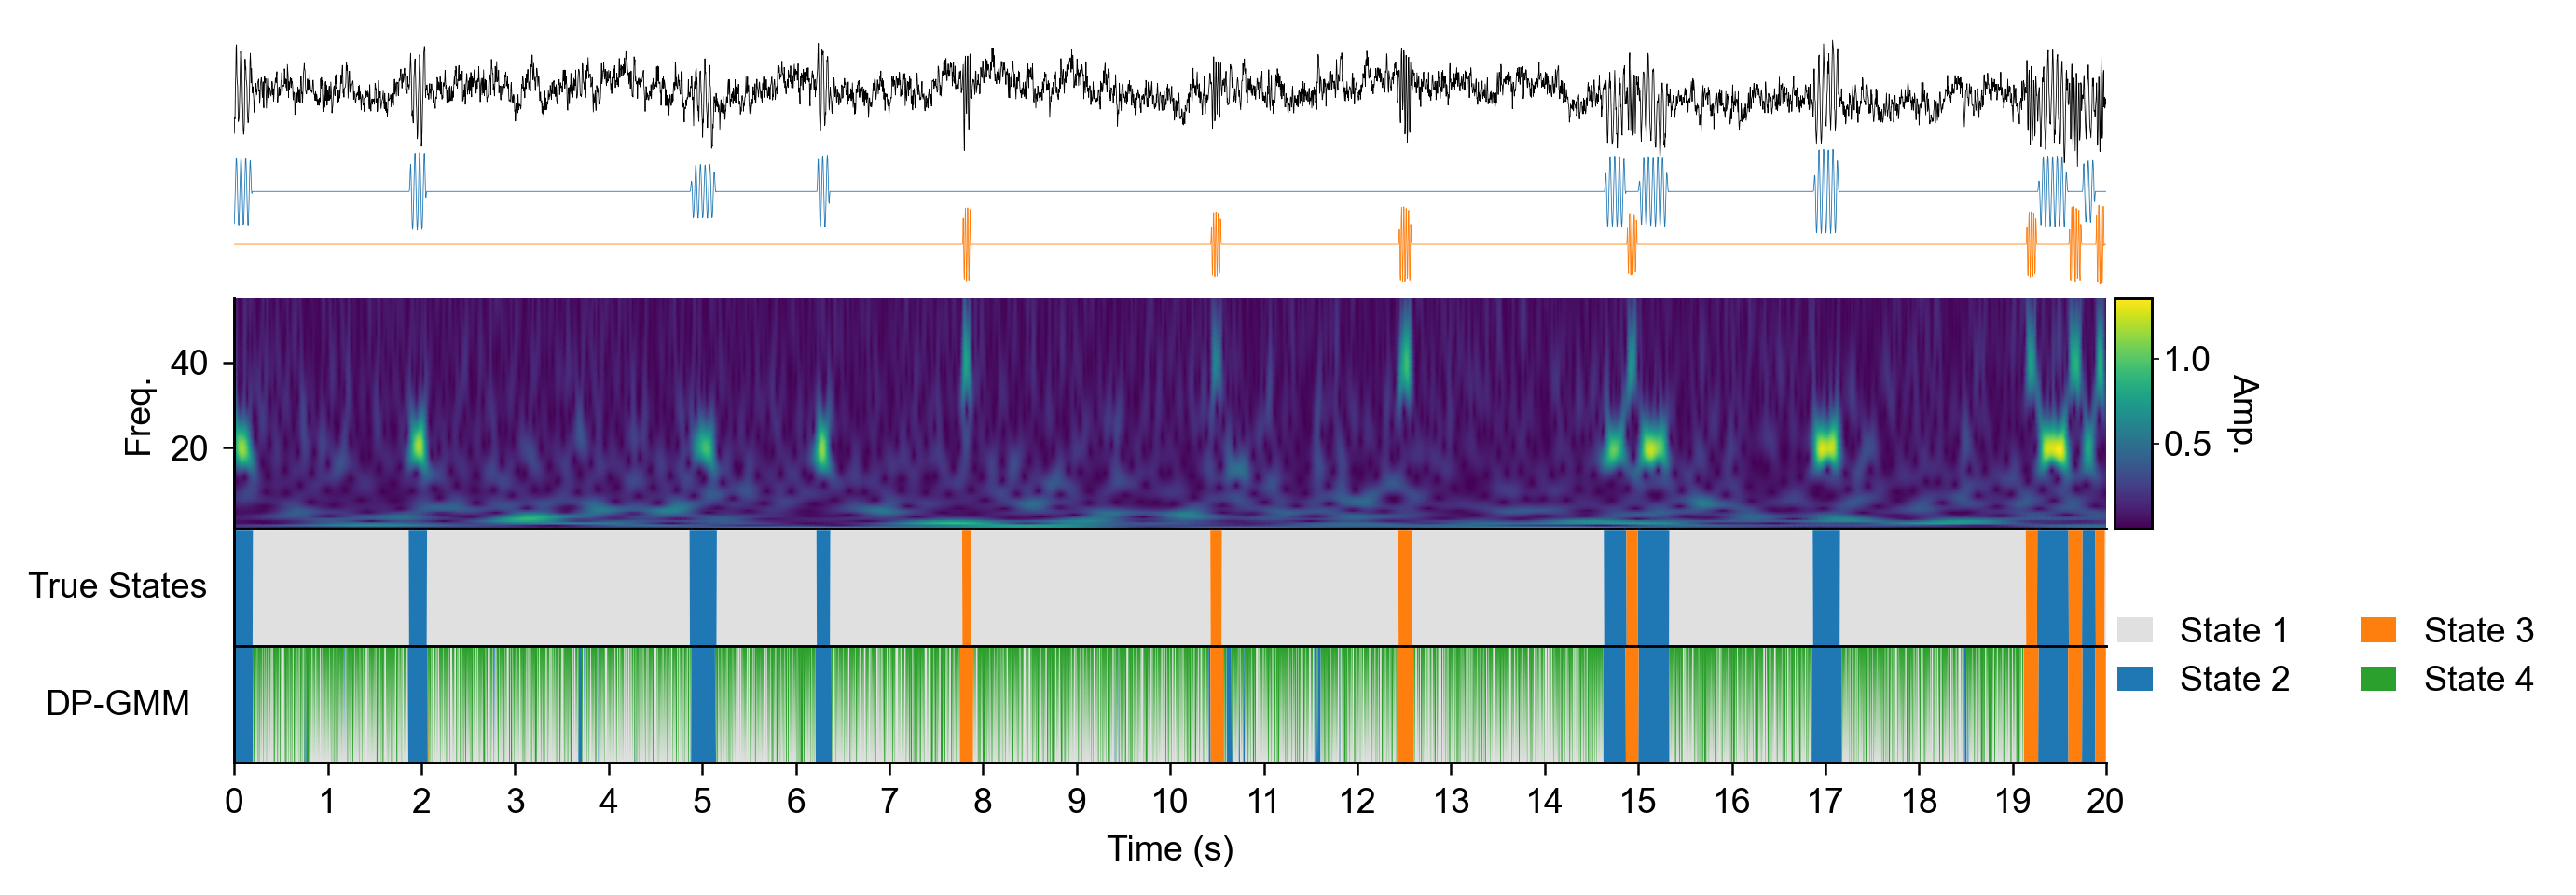

In [495]:


import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from mpl_toolkits.axes_grid1.inset_locator import inset_axes







plot_t = 20
#compute wavelet
t, f, amp = compute_wavelet(trimmed_signal[:plot_t*fs], fs, f_min = 1, f_max = 80, df = 0.5, wavelet = "cmor1.5-1.0")






cmap = plt.get_cmap("tab10")
colors = [cmap(i) for i in range(num_active_states)]
grey = ["#E0E0E0"]
colors = grey + colors
state_labels = [f"State {i+1}" for i in range(num_active_states)]



mosaic = [["b1", "b1"],
          ["b2", "b2"],
          ["b3", "b3"],
          ["b4", "b4"],
         ]

fig, axes = plt.subplot_mosaic(
    mosaic,
    figsize=(FIG_WIDTH, 3),  # a hair taller
    constrained_layout=True,
    gridspec_kw={"height_ratios":[0.7,0.6,0.3,0.3]}
)
fig.set_constrained_layout_pads(w_pad=0., h_pad=0., hspace=0.01)





axes["b1"].plot(trimmed_time_vec[:plot_t*fs], 0.3*(trimmed_signal[:plot_t*fs]), lw=0.2, color="k")
axes["b1"].grid(False)
axes["b1"].set_frame_on(False)
#axes["b1"].set_title(f"Raw signal (SNR = {snr_db} dB)", pad= 0.3)


axes["b1"].plot(trimmed_time_vec[:plot_t*fs], 0.3*(-2+ trimmed_bursts[:plot_t*fs] * (trimmed_states[:plot_t*fs] == 1)), lw=0.2, color=colors[1])
axes["b1"].plot(trimmed_time_vec[:plot_t*fs], 0.3*(-3+ trimmed_bursts[:plot_t*fs] * (trimmed_states[:plot_t*fs] == 2)), lw=0.2, color=colors[2])




axes["b1"].set_yticks([])
axes["b1"].set_xticks([])






for s in ("top","right","bottom","left"):
    axes["b1"].spines[s].set_visible(False)
axes["b1"].set_frame_on(False)
axes["b1"].tick_params(axis='both', which='both',
                       bottom=False, top=False, left=False, right=False,
                       labelbottom=False, labelleft=False)





im = axes["b2"].imshow(
    amp, extent=[t[0], t[-1], f[0], f[-1]],
    origin="lower", aspect="auto", cmap="viridis",
    vmin=amp.min(), vmax=amp.max()
)
axes["b2"].set_ylabel("Freq.")
#axes["b2"].set_title("Wavelet Transform", pad = 0.3)





#axes["b2"].tick_params(axis='y', which='both', left=True, labelleft=True, l)
axes["b2"].tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, labeltop=False)
axes["b2"].yaxis.set_major_locator(MultipleLocator(20))

axes["b2"].set_ylim(1, 55)


cax = inset_axes(
    axes["b2"],              # parent axis
    width="2%",              # width as percentage of a2
    height="100%",           # match the height
    loc="center right",      # position inside a2
    borderpad=-1.3             # negative value moves it outside slightly
)

# Add the colorbar to the inset axis
cb = fig.colorbar(im, cax=cax)
cb.set_label("Amp.", rotation = 270, labelpad = 12)
cb.ax.tick_params(which="both", length=2, width=0.4, pad=1)



axes["b3"].stackplot(trimmed_time_vec[:plot_t*fs], states_onehot[:plot_t*fs].T, linewidth = 0, colors = colors, labels = state_labels)
axes["b3"].set_ylabel(f"True States", rotation = 0, labelpad=30, va="center")
axes["b3"].tick_params(axis='y', which='both', left=False, labelleft=False)


axes["b4"].stackplot(trimmed_time_vec[:plot_t*fs], dpgmm_states_onehot[:plot_t*fs].T, linewidth = 0, colors = colors, labels = state_labels)
axes["b4"].set_ylabel(f"DP-GMM", rotation = 0, labelpad=30, va="center")




for key in ["b3"]:
    axes[key].tick_params(axis='x', which='both', bottom=False, labelbottom=False, length = 0)
    axes[key].tick_params(axis='y', which='both', left=False, labelleft=False)
    axes[key].set_yticks([])
    axes[key].set_xticks([])
    axes[key].spines["bottom"].set_visible(True)
    axes[key].set_ylim(0, 1)

for key in ["b1","b2", "b3", "b4"]:
    axes[key].sharex(axes["b1"])




axes["b4"].set_xlabel("Time (s)")
axes["b4"].xaxis.set_major_locator(MultipleLocator(1.0))
#axes["b6"].tick_params(axis='x', which='both', bottom=True, labelbottom=True, length = 0)
axes["b4"].tick_params(axis='y', which='both', left=False, labelleft=False)
axes["b4"].set_ylim(0, 1)
axes["b4"].set_xlim(0, plot_t)


axes["b4"].spines["bottom"].set_visible(True)   # keep x-axis frame






handles, labels = axes["b4"].get_legend_handles_labels()

fig.legend(handles, labels,
           loc="center left",          # anchor to left of the bbox
           ncol = 2,
           bbox_to_anchor=(0.981, 0.25), # (x, y) in figure coordinates
           frameon=False,
           handlelength=1)







# 4 states scenario

In [159]:
sim_cond = "4states_500Hz"
data_dir = "../data/simulations"
data_file = f"{data_dir}/{sim_cond}_data.npz"


sim_data = np.load(data_file)

signal = sim_data["signal_sample"]
states = sim_data["states_sample"]
bursts = sim_data["bursts_sample"]


import pickle
performance_dir = "../data/performance"
save_path = os.path.join(performance_dir, f"{sim_cond}_res.pkl")

# Load
with open(save_path, "rb") as f:
    res = pickle.load(f)



In [160]:
res = pd.DataFrame(res)

In [161]:
from nds_toolbox.preprocessing.features import compute_tde, trim_data, choose_embedding_dim

In [163]:

n_seconds = 60*3  # Total duration in seconds.
fs = 500

snr_db = 2

freq = np.array([20, 30, 40])  #ground truth = 4 states (including noise state)
num_emb = choose_embedding_dim(np.mean(freq), fs, min_cycles = 2.5, ensure_odd = True)
tde_signal = compute_tde(signal, num_emb)



trimmed_states = trim_data(states, num_embeddings = num_emb, verbose = False)
trimmed_signal = trim_data(signal, num_embeddings = num_emb, verbose = False)
trimmed_bursts = trim_data(bursts, num_embeddings = num_emb, verbose = False)
trimmed_time_vec = np.linspace(0, len(trimmed_states)/fs, len(trimmed_states))




num_states = int(np.ceil(np.log(len(trimmed_signal))))
print(num_states)

Chosen window size = 0.083 (sec): minimum cycles of 2.5 at 30.0 Hz
Chosen embedding dimension = 43: sampling rate = 500 Hz
21 data points were lost from both ends.
data shape: (89958, 43)
12


In [164]:
res

,method,signal,true_states,burst_f,fs,snr,est_params,loss_best,model_id_best,seed_best,...,pred_t,total_time,num_states,num_emb,est_states,order,summary_stats,mcc,loss,best_model_id
0,DP-GMM,"[0.3501775639540696, 0.41021854625444537, -0.2...","[3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, ...","[20, 30, 40]",500,2,"{'alpha': 0.7428254, 'weights': [0.6953572, 0....",0.5518693,0.0,2.261167e+09,...,2.123067,582.542505,12,43,"[3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, ...","[0, 1, 3, 2, 4, 5, 6, 7, 8, 9, 10, 11]",{'fractional_occupancies': [0.7451922008048201...,0.860828,0.5518693,NaN
1,DP-GMM (Imputed),"[0.3501775639540696, 0.41021854625444537, -0.2...","[3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, ...","[20, 30, 40]",500,2,"{'alpha': 0.7428254, 'weights': [0.6953572, 0....",0.5518693,0.0,2.261167e+09,...,2.123067,582.542505,12,43,"[3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, ...","[0, 1, 3, 2, 4, 5, 6, 7, 8, 9, 10, 11]",{'fractional_occupancies': [0.7688032192801085...,0.938126,0.5518693,NaN
2,HMM,"[0.3501775639540696, 0.41021854625444537, -0.2...","[3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, ...","[20, 30, 40]",500,2,"{'initial_probs': [0.2737585, 0.118609704, 0.1...",0.526602,NaN,NaN,...,0.732422,385.694778,12,43,"[3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, ...","[6, 10, 8, 2, 0, 1, 3, 4, 5, 7, 9, 11]","{'fractional_occupancies': [0.362357989283888,...",0.476174,0.526602,0.0
3,HMM (Imputed),"[0.3501775639540696, 0.41021854625444537, -0.2...","[3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, ...","[20, 30, 40]",500,2,"{'initial_probs': [0.2737585, 0.118609704, 0.1...",0.526602,NaN,NaN,...,0.732422,385.694778,12,43,"[3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, ...","[6, 10, 8, 2, 0, 1, 3, 4, 5, 7, 9, 11]",{'fractional_occupancies': [0.4304230863291758...,0.534381,0.526602,0.0


In [165]:
res.query("method == 'DP-GMM'").est_params.values[0].keys()

dict_keys(['alpha', 'weights', 'means', 'covs', 'untrunc_means', 'untrunc_covs', 'untrunc_weights', 'trunc_info', 'num_states_active'])

In [166]:

from nds_toolbox.models.dpgmm_numpyro import truncate, get_states
from sklearn.metrics import matthews_corrcoef

In [170]:
res.query("method == 'DP-GMM'").est_params.values[0].keys()

dict_keys(['alpha', 'weights', 'means', 'covs', 'untrunc_means', 'untrunc_covs', 'untrunc_weights', 'trunc_info', 'num_states_active'])

In [177]:
order_gmm

array([ 0,  1,  3,  2,  4,  5,  6,  7,  8,  9, 10, 11])

In [173]:

gmm_states = res.query("method == 'DP-GMM (Imputed)'").est_states.to_numpy()[0]
gmm_states_onehot = np.eye(num_states)[gmm_states]
gmm_mcc = res.query("method == 'DP-GMM (Imputed)'").mcc.values[0]


gmm_sumary_stats = res.query("method == 'DP-GMM (Imputed)'")["summary_stats"].values[0]
gmm_fo = gmm_sumary_stats["fractional_occupancies"]
gmm_f, gmm_psds = gmm_sumary_stats["spectra"]



order_gmm = res.query("method == 'DP-GMM (Imputed)'").order.to_numpy()[0]
alpha, weights, gmm_means, gmm_covs, untrunc_means, untrunc_covs, untrunc_weights, trunc_info, nun_active_states  = res.query("method == 'DP-GMM'").est_params.values[0].values()

untrunc_means = untrunc_means[order_gmm]
untrunc_covs = untrunc_covs[order_gmm]
untrunc_weights = untrunc_weights[order_gmm]

#trunc_means, trunc_covs, trunc_weights = truncate(1, gmm_means, gmm_covs, weights, verbose = True)
#gmm_states = get_states(tde_signal, trunc_means, trunc_covs, trunc_weights)
#gmm_mcc = matthews_corrcoef(trimmed_states, gmm_states)


hmm_states = res.query("method == 'HMM (Imputed)'").est_states.to_numpy()[0]
hmm_states_onehot = np.eye(num_states)[hmm_states]
hmm_mcc = res.query("method == 'HMM (Imputed)'").mcc.values[0]

hmm_sumary_stats = res.query("method == 'HMM (Imputed)'")["summary_stats"].values[0]
#hmm_fo = hmm_sumary_stats["fractional_occupancies"]
hmm_f, hmm_psds = hmm_sumary_stats["spectra"]



order_hmm = res.query("method == 'HMM (Imputed)'").order.to_numpy()[0]
init_probs, trans_mat, hmm_means, hmm_covs, stationary_dist = res.query("method == 'HMM (Imputed)'").est_params.values[0].values()




/var/folders/5z/yggynsqj6632pbql_bb3kqm40000gn/T/ipykernel_27383/3592749920.py:167: UserWarning: Using the axes or figure transform requires a bounding box in the respective coordinates. Using bbox_to_anchor=(0, 0, 1, 1) now.
  ax_b = inset_axes(axes["b"],
/var/folders/5z/yggynsqj6632pbql_bb3kqm40000gn/T/ipykernel_27383/3592749920.py:198: UserWarning: Using the axes or figure transform requires a bounding box in the respective coordinates. Using bbox_to_anchor=(0, 0, 1, 1) now.
  ab_c = inset_axes(axes["c"],


IndexError: list index out of range

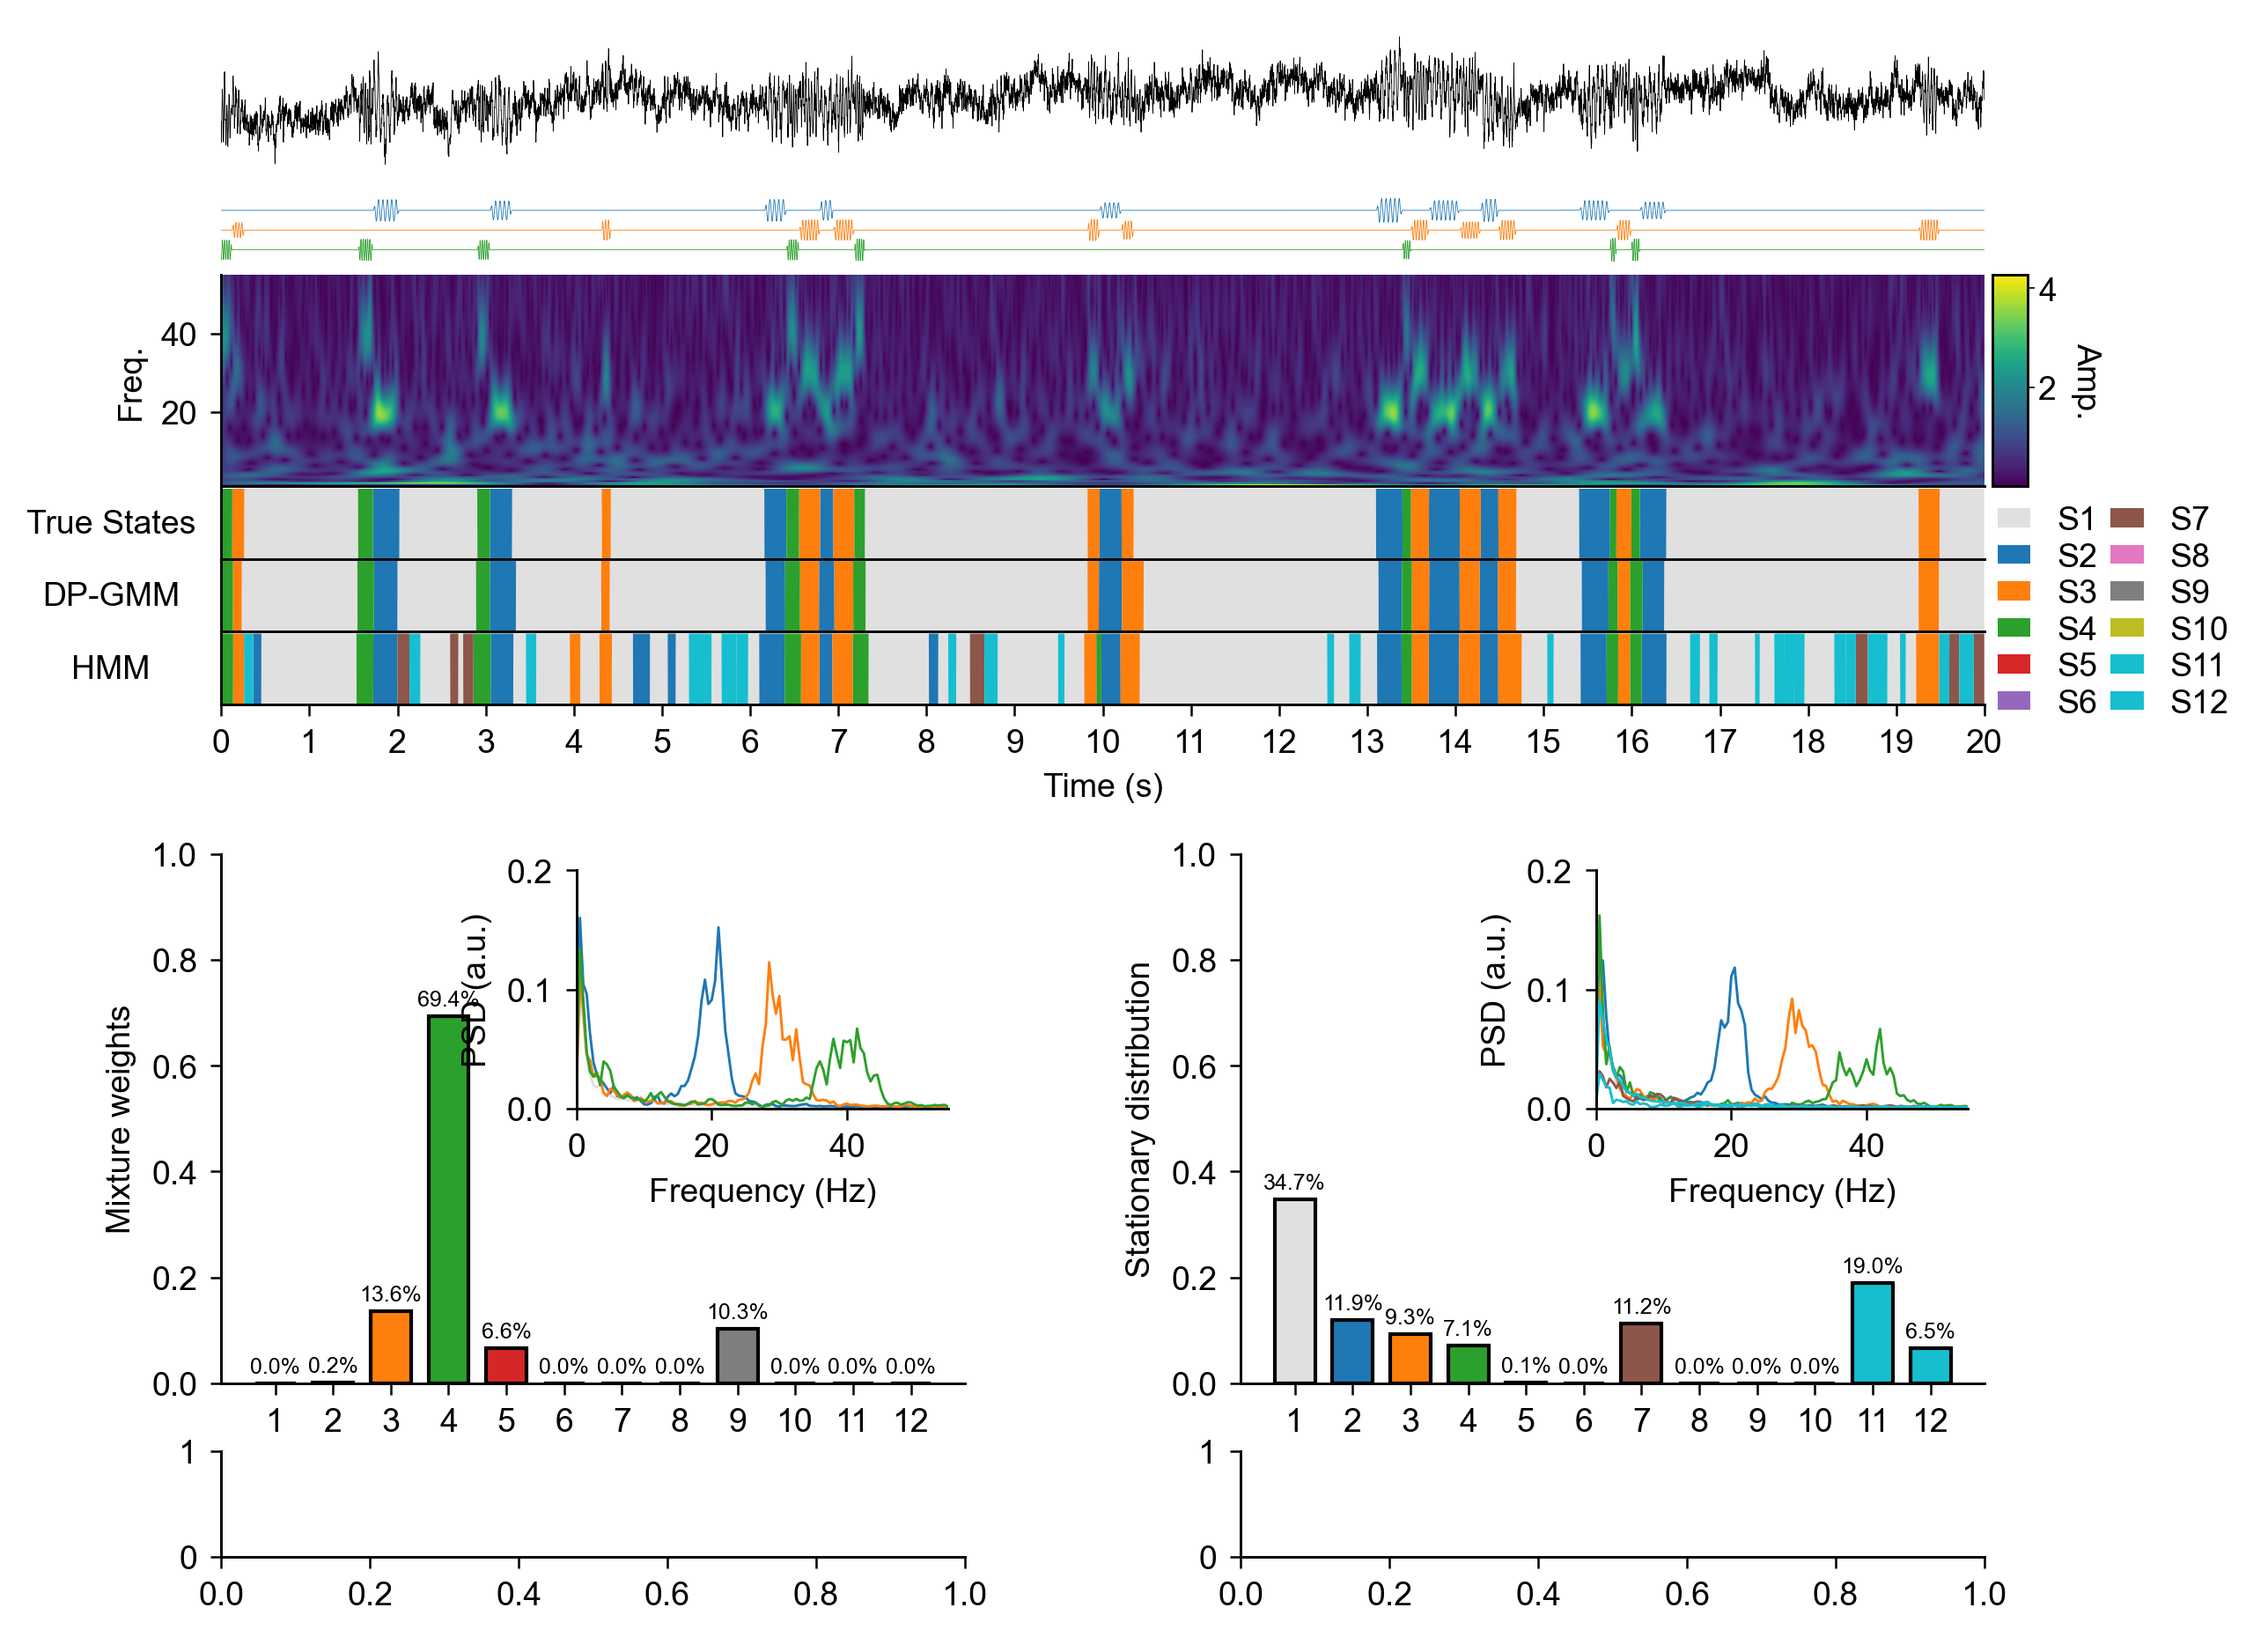

In [174]:

import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from mpl_toolkits.axes_grid1 import make_axes_locatable
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

cmap = plt.get_cmap("tab10")
colors = [cmap(i) for i in range(num_states)]
grey = ["#E0E0E0"]
colors = grey + colors
state_labels = [f"S{i+1}" for i in range(num_states)]

plot_t = 20


trimmed_states_onehot = np.eye(num_states)[trimmed_states]
t, f, amp = compute_wavelet(trimmed_signal[:plot_t*fs], fs, f_min = 1, f_max = 80, df = 0.5, wavelet = "cmor1.5-1.0")

mosaic = [["a1", "a1"],
          ["a2", "a2"],
          ["a3", "a3"],
          ["a4", "a4"],
          ["a5", "a5"],
          ["gap", "gap"],
          ["c", "b"],
          ["e", "d"],
         ]

fig, axes = plt.subplot_mosaic(
    mosaic,
    figsize=(FIG_WIDTH, 6.),  # a hair taller
    constrained_layout=True,
    gridspec_kw={"height_ratios":[0.7,0.6,0.2,0.2,0.2, 0.1 ,1.5, 0.3]}
)
fig.set_constrained_layout_pads(w_pad=0.0, h_pad=0., hspace=0.01)
axes["gap"].set_visible(False)


axes["a1"].plot(trimmed_time_vec[:plot_t*fs], trimmed_signal[:plot_t*fs], lw=0.2, color="k")
axes["a1"].set_frame_on(False)
#axes["a1"].set_title(f"Raw signal (SNR = {snr_db} dB)",pad= 0.3)

scale_burst = 1.7

axes["a1"].plot(trimmed_time_vec[:plot_t*fs], -5+ scale_burst * (trimmed_bursts[:plot_t*fs] * (trimmed_states[:plot_t*fs] == 1)), lw=0.2, color=colors[1])
axes["a1"].plot(trimmed_time_vec[:plot_t*fs], -6+ scale_burst * (trimmed_bursts[:plot_t*fs] * (trimmed_states[:plot_t*fs] == 2)), lw=0.2, color=colors[2])
axes["a1"].plot(trimmed_time_vec[:plot_t*fs], -7+ scale_burst * (trimmed_bursts[:plot_t*fs] * (trimmed_states[:plot_t*fs] == 3)), lw=0.2, color=colors[3])



axes["a1"].set_yticks([])
axes["a1"].set_xticks([])





#axes["b1"].set_ylabel(f"{plot_f}Hz", fontsize = TINY_SIZE, rotation = 0, labelpad = 20)

for s in ("top","right","bottom","left"):
    axes["a1"].spines[s].set_visible(False)
axes["a1"].set_frame_on(False)
axes["a1"].tick_params(axis='both', which='both',
                       bottom=False, top=False, left=False, right=False,
                       labelbottom=False, labelleft=False)





im = axes["a2"].imshow(
    amp, extent=[t[0], t[-1], f[0], f[-1]],
    origin="lower", aspect="auto", cmap="viridis",
    vmin=amp.min(), vmax=amp.max()
)
axes["a2"].set_ylabel("Freq.")
#axes["a2"].set_title("Wavelet Transform",pad = 0.3)


axes["a2"].tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, labeltop=False)
axes["a2"].yaxis.set_major_locator(MultipleLocator(20))

axes["a2"].set_ylim(1, 55)
axes["a2"].sharex(axes["a1"])


cax = inset_axes(
    axes["a2"],              # parent axis
    width="2%",              # width as percentage of a2
    height="100%",           # match the height
    loc="center right",      # position inside a2
    borderpad=-1.3             # negative value moves it outside slightly
)

# Add the colorbar to the inset axis
cb = fig.colorbar(im, cax=cax)
cb.set_label("Amp.", rotation = 270, labelpad = 12)
cb.ax.tick_params(which="both", length=2, width=0.4, pad=1)



axes["a3"].stackplot(trimmed_time_vec[:plot_t*fs], trimmed_states_onehot[:plot_t*fs].T, linewidth = 0, colors = colors, labels = state_labels)
axes["a3"].set_ylabel(f"True States", rotation = 0, labelpad=30, va="center")

axes["a4"].stackplot(trimmed_time_vec[:plot_t*fs], gmm_states_onehot[:plot_t*fs].T, linewidth = 0, colors = colors, labels = [f"MCC = {gmm_mcc:.2f}"] + [None]*(num_states-1))
axes["a4"].set_ylabel(f"DP-GMM", rotation = 0, labelpad=30, va="center")

axes["a5"].stackplot(trimmed_time_vec[:plot_t*fs], hmm_states_onehot[:plot_t*fs].T, linewidth = 0, colors = colors, labels =  f"MCC = {hmm_mcc:.2f}")
axes["a5"].set_ylabel(f"HMM", rotation = 0, labelpad=30, va="center")



for key in ["a1","a2", "a3", "a4", "a5"]:
    axes[key].sharex(axes["a1"])

for key in ["a3", "a4"]:
    axes[key].tick_params(axis='x', which='both', bottom=True, labelbottom=False, length = 0)
    axes[key].tick_params(axis='y', which='both', left=False, labelleft=False)
    axes[key].set_yticks([])
    axes[key].set_xticks([])
    axes[key].spines["bottom"].set_visible(True)
    axes[key].set_ylim(0, 1)
    axes[key].set_xlim(0, plot_t)



axes["a5"].set_xlabel("Time (s)")
axes["a5"].xaxis.set_major_locator(MultipleLocator(1.0))
#axes["a5"].xaxis.set_minor_locator(MultipleLocator(0.5))
#axes["a5"].tick_params(axis='x', which='both', bottom=True, labelbottom=True, length = 0)
axes["a5"].tick_params(axis='y', which='both', left=False, labelleft=False)
axes["a5"].set_ylim(0, 1)
axes["a5"].set_xlim(0, plot_t)


axes["a5"].spines["bottom"].set_visible(True)   # keep x-axis frame




handles, labels = axes["a3"].get_legend_handles_labels()

fig.legend(handles, labels,
           loc="center left",          # anchor to left of the bbox
           bbox_to_anchor=(0.98, 0.63), # (x, y) in figure coordinates
           frameon=False,
           handlelength=1,
           handleheight=0.5,
           labelspacing = 0.2,
           ncol = 2,
           columnspacing = 0.4,
           )





for k, w in enumerate(stationary_dist):
    axes["b"].bar(k, w, width = 0.7, color = colors[k], zorder = 1, align = "center", edgecolor = "k")
    axes["b"].text(k, w + 0.02,"%.1f%%" % (w * 100.0), horizontalalignment="center", color = "k", fontsize = MY_FONT_SIZE - 3 )
    axes["b"].set_ylabel("Stationary distribution")
    axes["b"].set_xticks(np.arange(num_states), labels = np.arange(1, num_states + 1))
    axes["b"].tick_params(axis='y', )
    #axes["b"].spines["top"].set_visible(True)
    #axes["b"].spines["right"].set_visible(True)
    axes["b"].set_ylim(0, 1)

ax_b = inset_axes(axes["b"],
                      width = "50%", height = "45%",
                      loc = "upper right",
                      bbox_transform = axes["b"].transAxes,
                      borderpad = 0.5,)


for i in range(num_states):
    ax_b.plot(hmm_f[i], hmm_psds[i], color = colors[i], lw = 0.7)
    ax_b.set_xlim(0, 55)
    ax_b.set_ylim(0, 0.2)
    ax_b.set_xlabel("Frequency (Hz)", )
    ax_b.set_ylabel("PSD (a.u.)",)






for k, w in enumerate(untrunc_weights):
    axes["c"].bar(k, w, width = 0.7, color = colors[k], zorder = 1, align = "center", edgecolor = "k")
    axes["c"].text(k, w + 0.02,"%.1f%%" % (w * 100.0), horizontalalignment="center", color = "k" , fontsize = MY_FONT_SIZE - 3 )
    axes["c"].set_ylabel("Mixture weights")
    axes["c"].set_xticks(np.arange(num_states), labels = np.arange(1, num_states + 1))
    axes["c"].tick_params(axis='y')

   #axes["c"].spines["top"].set_visible(True)
    #axes["c"].spines["right"].set_visible(True)
    axes["c"].set_ylim(0, 1)


ab_c = inset_axes(axes["c"],
                  width = "50%", height = "45%",
                      loc = "upper right",
                      bbox_transform = axes["c"].transAxes,
                      borderpad = 0.5,)

for i in range(num_states):

    ab_c.plot(gmm_f[i], gmm_psds[i], color = colors[i], lw = 0.7)
    ab_c.set_xlim(0, 55)
    ab_c.set_xlabel("Frequency (Hz)")
    ab_c.set_ylabel("PSD (a.u.)")
    ab_c.set_ylim(0, 0.20)
    #ab_c.tick_params(axis="both", which="both", bottom = False, top = False, left = False, right = False)
    #ab_c.grid(False)


axes["d"].set_xlabel("HMM States")
axes["e"].set_xlabel("DP-GMM States")

for key in ["d", "e"]:
    axes[key].set_xticks([])
    axes[key].set_yticks([])
    axes[key].spines[:].set_visible(False)


fig.canvas.draw()
fig.savefig(
    f"../figures/{sim_cond}_results.jpg",
    bbox_inches="tight"
)


plt.show()



/var/folders/5z/yggynsqj6632pbql_bb3kqm40000gn/T/ipykernel_29629/319322124.py:9: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.savefig(
/opt/anaconda3/envs/pymc_env/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  func(*args, **kwargs)
/opt/anaconda3/envs/pymc_env/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


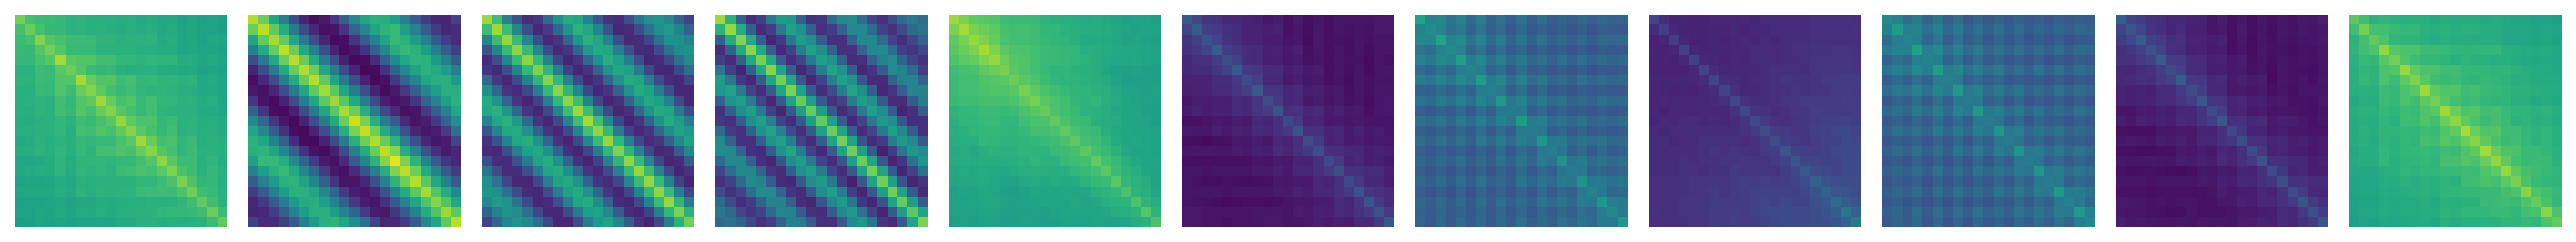

In [45]:
vmin  = np.min([untrunc_covs, hmm_covs])               # global minimum
vmax  = np.max([untrunc_covs, hmm_covs])               # global maximum
norm  = plt.Normalize(vmin, vmax)      # shared normalisation
fig, ax = plt.subplots(1, hmm_covs.shape[0], figsize = (untrunc_covs.shape[0]*2, 2), gridspec_kw = {"wspace":0.1})
for i ,cov in enumerate(hmm_covs):
    ax[i].imshow(cov, cmap = "viridis", norm = norm)
    ax[i].set_axis_off()

fig.savefig(
    f"../figures/{sim_cond}_hmm_covs.jpg",
    bbox_inches="tight",
    pad_inches=0.05,)


/var/folders/5z/yggynsqj6632pbql_bb3kqm40000gn/T/ipykernel_29629/4033313953.py:6: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.savefig(
/opt/anaconda3/envs/pymc_env/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  func(*args, **kwargs)
/opt/anaconda3/envs/pymc_env/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


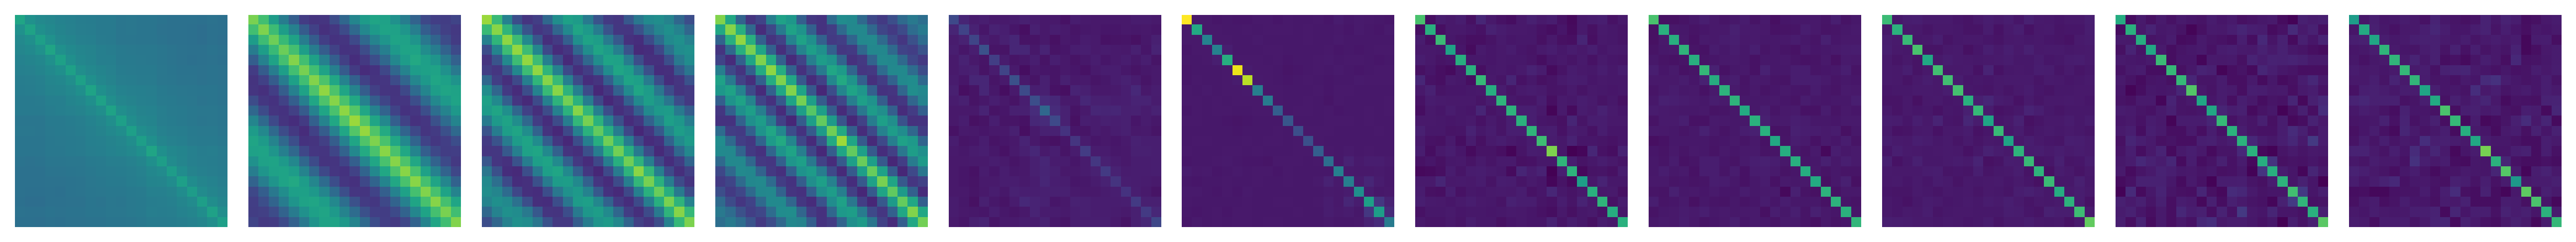

In [46]:

fig, ax = plt.subplots(1, untrunc_covs.shape[0], figsize = (untrunc_covs.shape[0]*2, 2), gridspec_kw = {"wspace":0.1})
for i ,cov in enumerate(untrunc_covs):
    ax[i].imshow(cov,  cmap = "viridis", norm = norm)
    ax[i].set_axis_off()

fig.savefig(
    f"../figures/{sim_cond}_gpgmm_covs.jpg",
    bbox_inches="tight",
    pad_inches=0.05,)


## states before imputation


In [47]:
_gmm_mcc = res.query("method == 'DP-GMM'").mcc.values[0]
_gmm_states = res.query("method == 'DP-GMM'").est_states.to_numpy()[0]
_gmm_states_onehot = np.eye(num_states)[_gmm_states]

_hmm_mcc = res.query("method == 'HMM'").mcc.values[0]
_hmm_states = res.query("method == 'HMM'").est_states.to_numpy()[0]
_hmm_states_onehot = np.eye(num_states)[_hmm_states]


print("dp-gmm", _gmm_mcc)
print("dp-gmm (imputed)", gmm_mcc)

print("hmm", _hmm_mcc)
print("hmm (imputed)", hmm_mcc)


"""
dp-gmm 0.8618107993142023
dp-gmm (imputed) 0.938337224764793
hmm 0.3483492480108877
hmm (imputed) 0.3112647340620908
"""

dp-gmm 0.8693541137545504
dp-gmm (imputed) 0.9350720693206954
hmm 0.3483492480108877
hmm (imputed) 0.3112647340620908


'\ndp-gmm 0.8618107993142023\ndp-gmm (imputed) 0.938337224764793\nhmm 0.3483492480108877\nhmm (imputed) 0.3112647340620908\n'

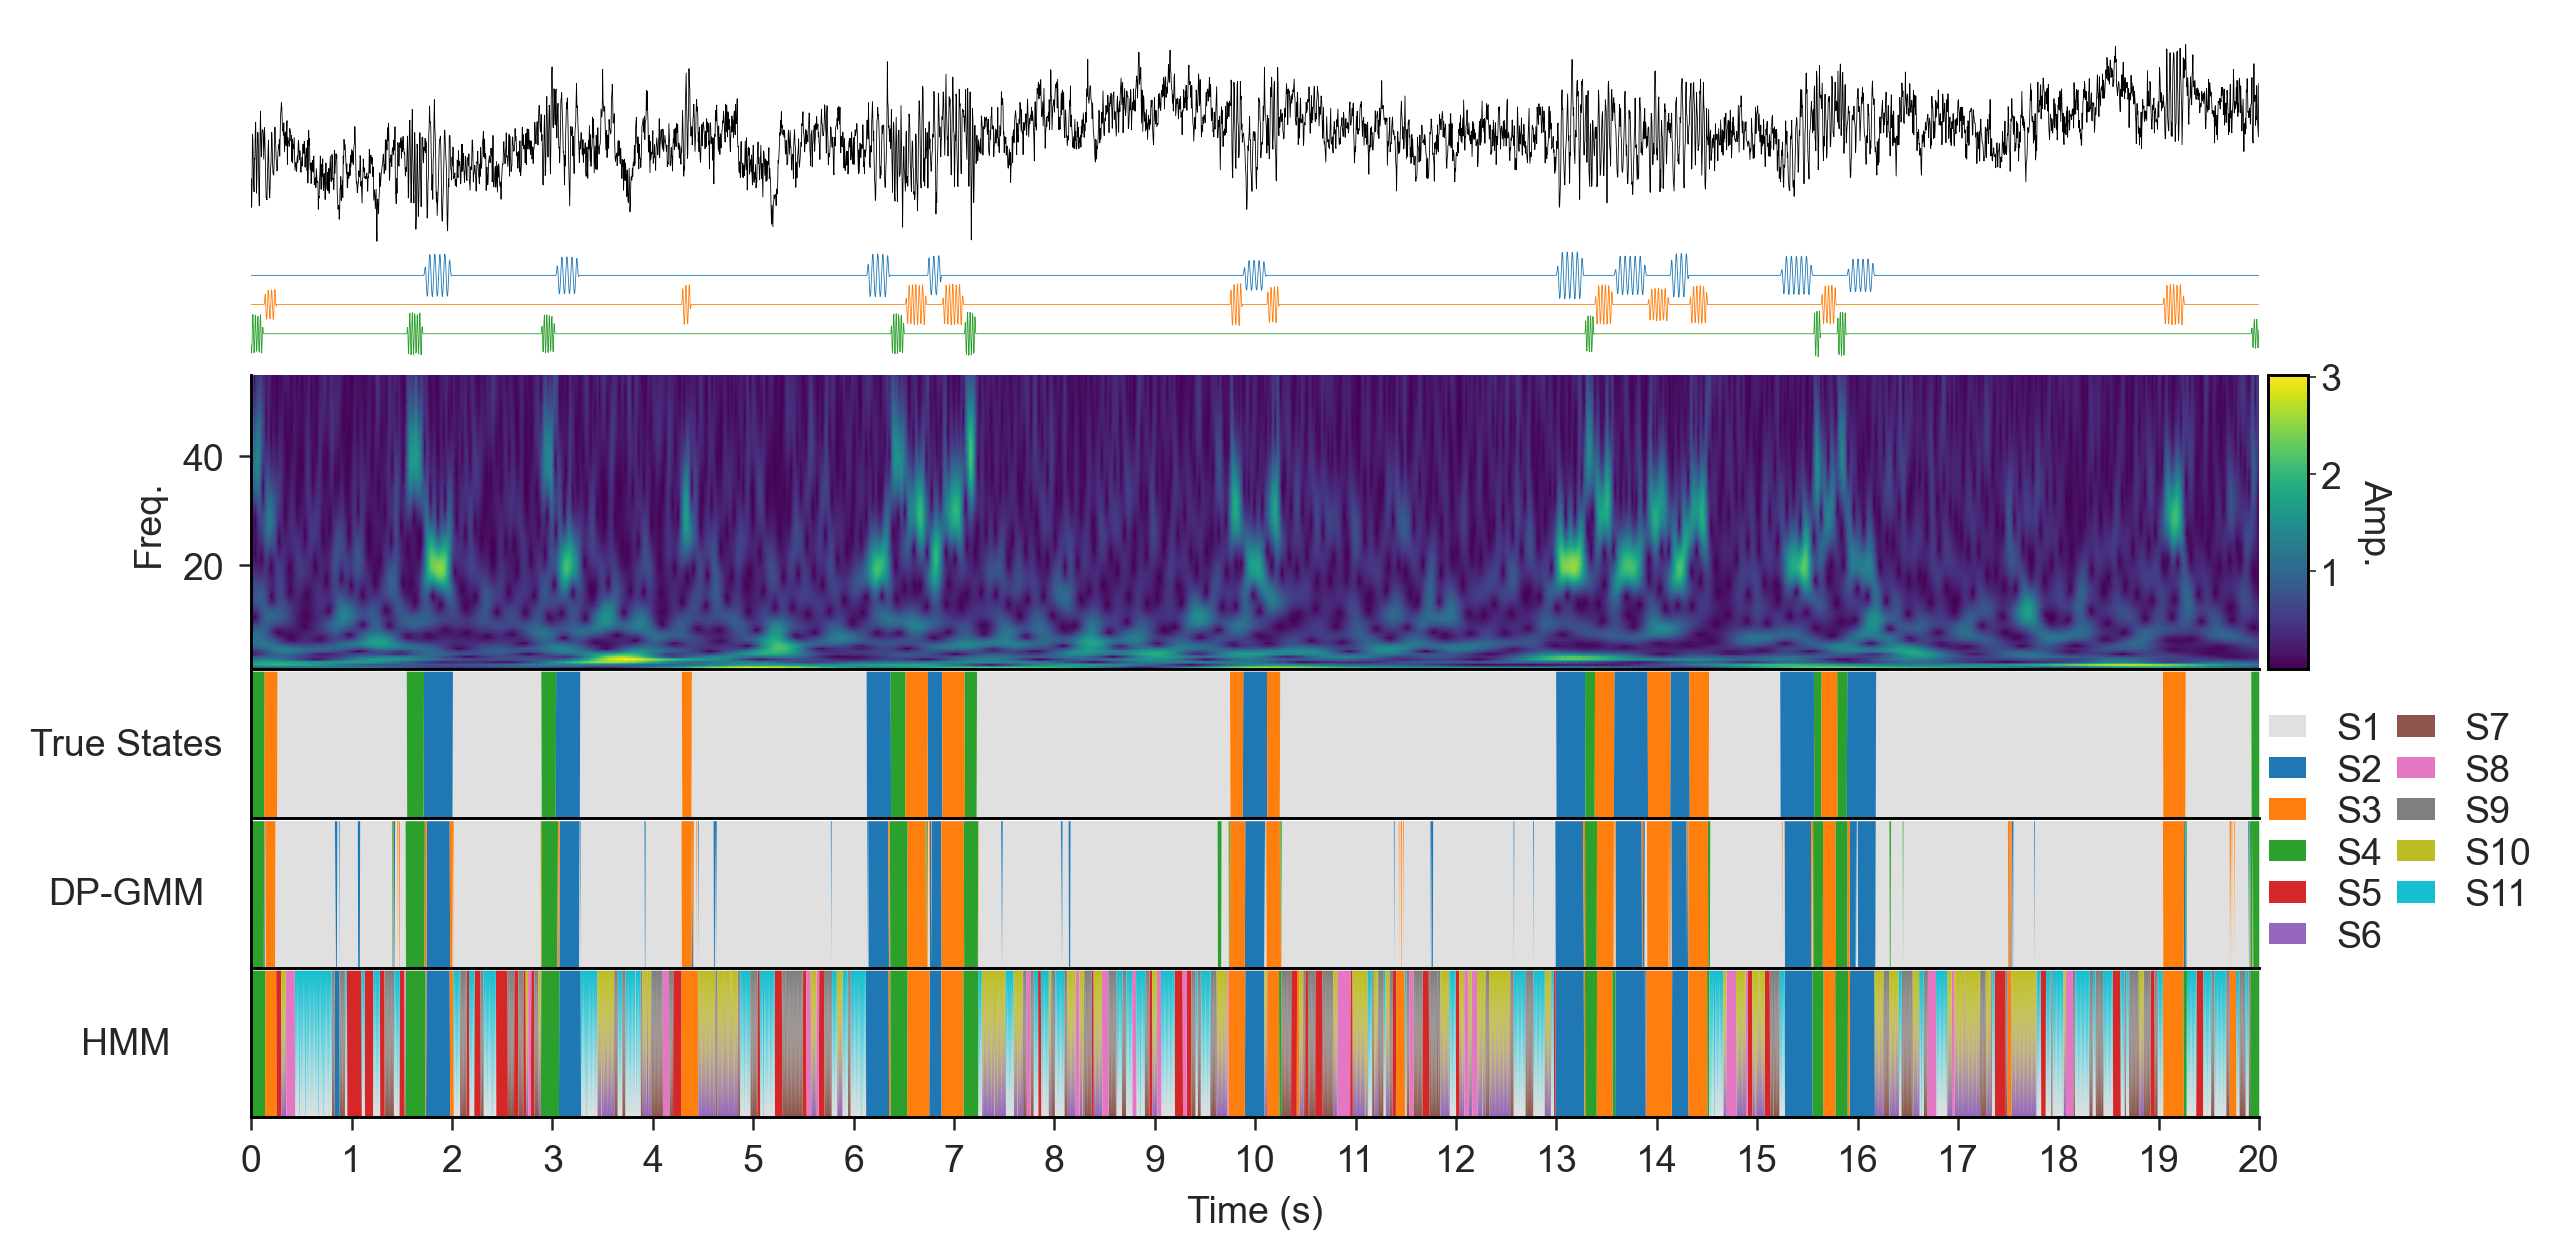

In [51]:

import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from mpl_toolkits.axes_grid1 import make_axes_locatable
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

cmap = plt.get_cmap("tab10")
colors = [cmap(i) for i in range(num_states)]
grey = ["#E0E0E0"]
colors = grey + colors
state_labels = [f"S{i+1}" for i in range(num_states)]

plot_t = 20


trimmed_states_onehot = np.eye(num_states)[trimmed_states]
t, f, amp = compute_wavelet(trimmed_signal[:plot_t*fs], fs, f_min = 1, f_max = 80, df = 0.5, wavelet = "cmor1.5-1.0")

mosaic = [["a1", "a1"],
          ["a2", "a2"],
          ["a3", "a3"],
          ["a4", "a4"],
          ["a5", "a5"],
         ]

fig, axes = plt.subplot_mosaic(
    mosaic,
    figsize=(FIG_WIDTH, 4.),  # a hair taller
    constrained_layout=True,
    gridspec_kw={"height_ratios":[0.7,0.6,0.3,0.3,0.3]}
)

fig.set_constrained_layout_pads(w_pad=0., h_pad=0., hspace=0.01)



axes["a1"].plot(trimmed_time_vec[:plot_t*fs], trimmed_signal[:plot_t*fs], lw=0.2, color="k")
axes["a1"].set_frame_on(False)
#axes["a1"].set_title(f"Raw signal (SNR = {snr_db} dB)",pad= 0.3)

scale_burst = 1.7

axes["a1"].plot(trimmed_time_vec[:plot_t*fs], -5+ scale_burst * (trimmed_bursts[:plot_t*fs] * (trimmed_states[:plot_t*fs] == 1)), lw=0.2, color=colors[1])
axes["a1"].plot(trimmed_time_vec[:plot_t*fs], -6+ scale_burst * (trimmed_bursts[:plot_t*fs] * (trimmed_states[:plot_t*fs] == 2)), lw=0.2, color=colors[2])
axes["a1"].plot(trimmed_time_vec[:plot_t*fs], -7+ scale_burst * (trimmed_bursts[:plot_t*fs] * (trimmed_states[:plot_t*fs] == 3)), lw=0.2, color=colors[3])



axes["a1"].set_yticks([])
axes["a1"].set_xticks([])





#axes["b1"].set_ylabel(f"{plot_f}Hz", fontsize = TINY_SIZE, rotation = 0, labelpad = 20)

for s in ("top","right","bottom","left"):
    axes["a1"].spines[s].set_visible(False)
axes["a1"].set_frame_on(False)
axes["a1"].tick_params(axis='both', which='both',
                       bottom=False, top=False, left=False, right=False,
                       labelbottom=False, labelleft=False)





im = axes["a2"].imshow(
    amp, extent=[t[0], t[-1], f[0], f[-1]],
    origin="lower", aspect="auto", cmap="viridis",
    vmin=amp.min(), vmax=amp.max()
)
axes["a2"].set_ylabel("Freq.")
#axes["a2"].set_title("Wavelet Transform",pad = 0.3)


axes["a2"].tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, labeltop=False)
axes["a2"].yaxis.set_major_locator(MultipleLocator(20))

axes["a2"].set_ylim(1, 55)
axes["a2"].sharex(axes["a1"])


cax = inset_axes(
    axes["a2"],              # parent axis
    width="2%",              # width as percentage of a2
    height="100%",           # match the height
    loc="center right",      # position inside a2
    borderpad=-1.3             # negative value moves it outside slightly
)

# Add the colorbar to the inset axis
cb = fig.colorbar(im, cax=cax)
cb.set_label("Amp.", rotation = 270, labelpad = 12)
cb.ax.tick_params(which="both", length=2, width=0.4, pad=1)



axes["a3"].stackplot(trimmed_time_vec[:plot_t*fs], trimmed_states_onehot[:plot_t*fs].T, linewidth = 0, colors = colors, labels = state_labels)
axes["a3"].set_ylabel(f"True States", rotation = 0, labelpad=30, va="center")

axes["a4"].stackplot(trimmed_time_vec[:plot_t*fs], _gmm_states_onehot[:plot_t*fs].T, linewidth = 0, colors = colors, labels = [f"MCC = {_gmm_mcc:.2f}"] + [None]*(num_states-1))
axes["a4"].set_ylabel(f"DP-GMM", rotation = 0, labelpad=30, va="center")

axes["a5"].stackplot(trimmed_time_vec[:plot_t*fs], _hmm_states_onehot[:plot_t*fs].T, linewidth = 0, colors = colors, labels =  f"MCC = {_hmm_mcc:.2f}")
axes["a5"].set_ylabel(f"HMM", rotation = 0, labelpad=30, va="center")



for key in ["a1","a2", "a3", "a4", "a5"]:
    axes[key].sharex(axes["a1"])

for key in ["a3", "a4"]:
    axes[key].tick_params(axis='x', which='both', bottom=True, labelbottom=False, length = 0)
    axes[key].tick_params(axis='y', which='both', left=False, labelleft=False)
    axes[key].set_yticks([])
    axes[key].set_xticks([])
    axes[key].spines["bottom"].set_visible(True)
    axes[key].set_ylim(0, 1)
    axes[key].set_xlim(0, plot_t)



axes["a5"].set_xlabel("Time (s)")
axes["a5"].xaxis.set_major_locator(MultipleLocator(1.0))
#axes["a5"].xaxis.set_minor_locator(MultipleLocator(0.5))
#axes["a5"].tick_params(axis='x', which='both', bottom=True, labelbottom=True, length = 0)
axes["a5"].tick_params(axis='y', which='both', left=False, labelleft=False)
axes["a5"].set_ylim(0, 1)
axes["a5"].set_xlim(0, plot_t)


axes["a5"].spines["bottom"].set_visible(True)   # keep x-axis frame




handles, labels = axes["a3"].get_legend_handles_labels()

fig.legend(handles, labels,
           loc="center left",          # anchor to left of the bbox
           bbox_to_anchor=(0.98, 0.33), # (x, y) in figure coordinates
           frameon=False,
           handlelength=1,
           handleheight=0.5,
           labelspacing = 0.2,
           ncol = 2,
           columnspacing = 0.4,
           )



fig.savefig(
    f"../figures/{sim_cond}_before_imputation.jpg",
    bbox_inches="tight",
    pad_inches=0.05,)


plt.show()



## HMM

In [55]:
import pickle
save_path = os.path.join(performance_dir, f"{sim_cond}_HMM_results.pkl")

# Load
with open(save_path, "rb") as f:
    res = pickle.load(f)

df_list = [pd.DataFrame(r) for r in res]
df = pd.concat(df_list, axis = 0, ignore_index = True)

df.head()


,method,signal,true_states,burst_f,fs,snr,est_params,best_model_id,loss_best,loss_all,fit_t,pred_t,total_time,num_states,num_emb,est_states,order,summary_stats,mcc,loss
0,HMM,"[0.598276138815683, 0.8167041652397233, 1.4131...",None,"[20, 30, 40]",250,0,"{'initial_probs': [0.74486524, 0.25513476], 't...",7,0.546423,"[[1.4314460714299742, 1.250953059730719, 1.151...",73.301494,0.523111,73.824605,2,21,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 0]",None,None,0.546423
1,HMM,"[0.598276138815683, 0.8167041652397233, 1.4131...",None,"[20, 30, 40]",250,0,"{'initial_probs': [0.62651044, 0.20530105, 0.1...",2,0.539855,"[[1.6324689039241207, 1.2568464254477476, 1.15...",48.039872,0.367093,48.406966,3,21,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[0, 2, 1]",None,None,0.539855
2,HMM,"[0.598276138815683, 0.8167041652397233, 1.4131...",None,"[20, 30, 40]",250,0,"{'initial_probs': [0.40047932, 0.14736506, 0.2...",0,0.530635,"[[1.4887848861504835, 1.4236964855674614, 1.27...",86.767325,0.171692,86.939017,4,21,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[2, 1, 3, 0]",None,None,0.530635
3,HMM,"[0.598276138815683, 0.8167041652397233, 1.4131...",None,"[20, 30, 40]",250,0,"{'initial_probs': [0.32911584, 0.18618357, 0.1...",4,0.527656,"[[1.4836739567833206, 1.2856269277421006, 1.31...",106.047387,0.188655,106.236042,5,21,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[4, 2, 0, 3, 1]",None,None,0.527656
4,HMM,"[0.598276138815683, 0.8167041652397233, 1.4131...",None,"[20, 30, 40]",250,0,"{'initial_probs': [0.20053026, 0.22559878, 0.2...",3,0.518811,"[[1.5965215600881493, 1.1739165587918023, 1.13...",139.007899,0.206383,139.214281,6,21,"[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...","[1, 0, 4, 3, 5, 2]",None,None,0.518811


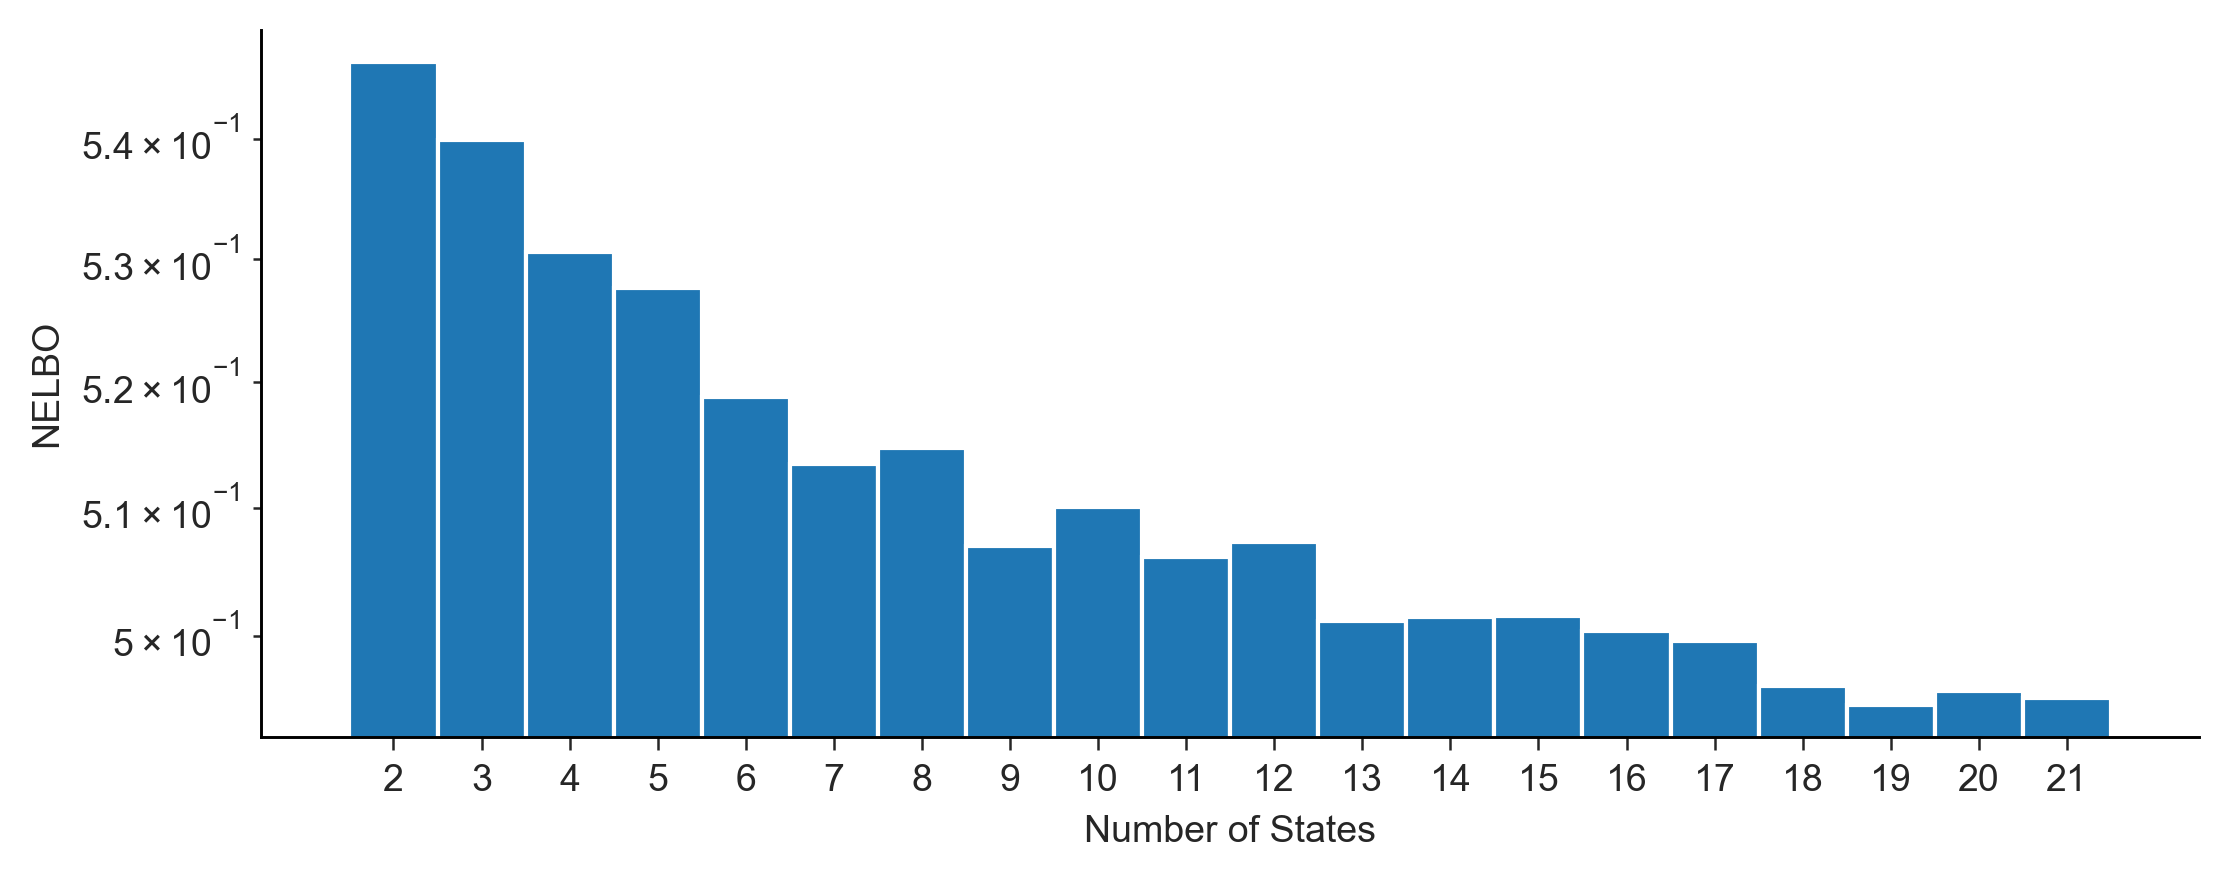

In [58]:
hmm_res = df.query("method == 'HMM'")
num_states_vec = hmm_res.num_states.to_numpy().astype(int)


hmm_color   = "#1f77b4"



elbos = hmm_res["loss_best"]
fig, ax = plt.subplots(figsize = (FIG_WIDTH, 3))
ax.bar(num_states_vec, elbos, color = hmm_color, width = 1, align = "center")
ax.set_yscale("log")
ax.set_xticks(num_states_vec)
ax.set_ylabel("NELBO")
ax.set_xlabel("Number of States")


fig.savefig(
    f"../figures/{sim_cond}_HMM_nelbo.jpg",
    bbox_inches="tight",
    pad_inches=0.05,)






